# Overview (Male Donor)

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import ranker

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Donor_Male_Heart_Meds.pkl")
# display shape
df.shape

(20007, 103)

## Male

#### User Function(s)

In [3]:
# display info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 20007 entries, 0 to 28750
Data columns (total 103 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   20007 non-null  category
 1    AntigenDA1_DON                        20007 non-null  category
 2    AntigenDA2_DON                        20007 non-null  category
 3    AntigenDB1_DON                        20007 non-null  category
 4    AntigenDB2_DON                        20007 non-null  category
 5    AntigenDR1_DON                        20007 non-null  category
 6    AntigenDR2_DON                        20007 non-null  category
 7    Citizenship_DON                       20007 non-null  category
 8    PastCocaineUse_DON                    20007 non-null  category
 9    Age_DON                               20007 non-null  float64 
 10   Ethnicity_DON                         20007 non-null  categor

In [4]:
# Empty DataFrame # list for record keeping
mapping_df = pd.DataFrame(columns=['feature', 'consolidate', 'type', 'gender'])
gender_value = 'Male'
type_value = 'CAN'
remove_cols = []

#### DeceasedRetyped

In [5]:
# info
feature = u.get_feature_info(df, 'DeceasedRetyped_DON', cat=False)
# dtype
df[feature].apply(lambda s: repr(s.dtype))

                     count unique  top   freq
DeceasedRetyped_DON  20007      3  Yes  11899

:::: NaN Count:
DeceasedRetyped_DON    0 



DeceasedRetyped_DON    CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)
dtype: object

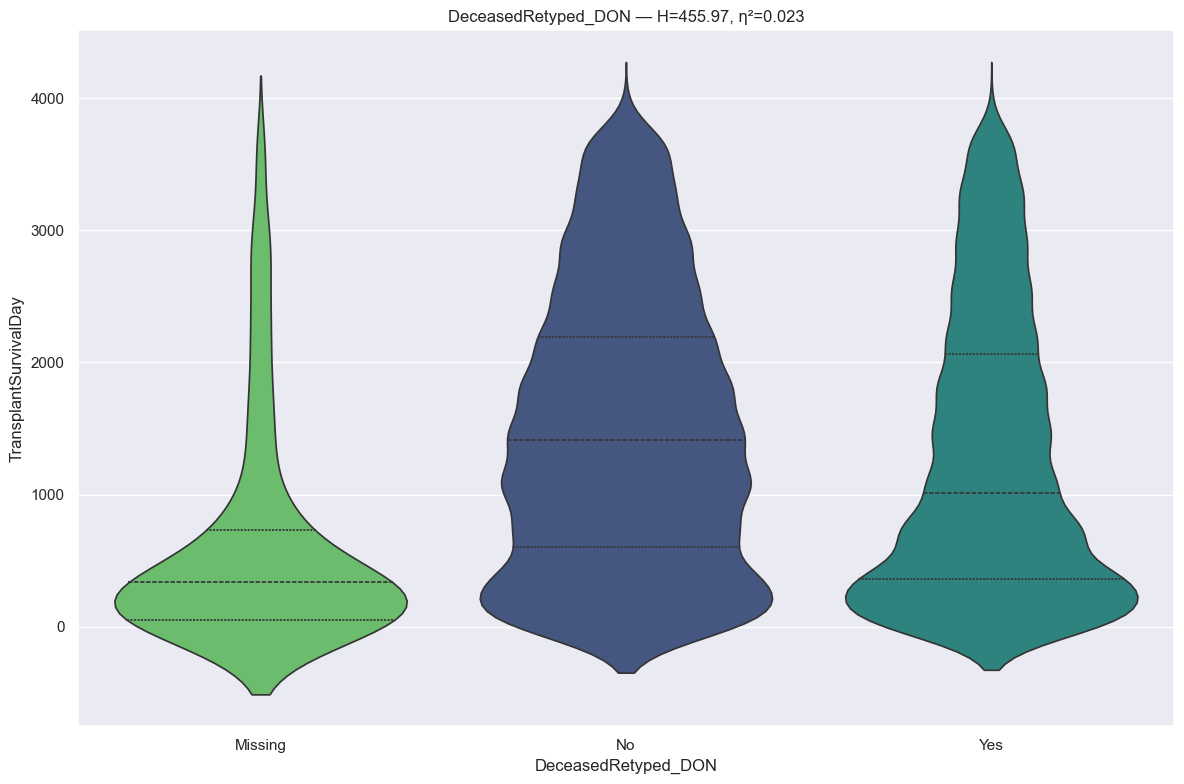

RANKING REPORT: DeceasedRetyped_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :    353 records
 * No                                                :   7755 records
 * Yes                                               :  11899 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 455.9710 | P-value: 9.708720e-100 | Effect η²: 0.0227
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=7.7017e-63 | thr=0.0167 | r= 0.526 | *Sig*
No           vs Yes          | p=4.8613e-54 | thr=0.0167 | r=-0.130 | *Sig*
Missing      vs Yes          | p=5.6914e-40 | thr=0.0167 | r= 0.413 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_

In [6]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

##### **Note:** Statistically significant after Bonferroni and practically meaningful (|r| > 0.10 threshold) and none should be collapsed.

#### Antigen DA1
* Donor-Specific Antibodies (DSAs) directed against antigens (such as HLA Class I or II) are critical factors in transplant rejection, acting as a primary cause of graft loss. The presence of these antibodies before transplant (preformed) or their development afterward (de novo) generally correlates with poor outcomes, particularly in kidney and heart transplants, as they can initiate antibody-mediated rejection (ABMR). 
* Role of DA Antigen in Transplant Research: In experimental studies, particularly in rat heart transplantation, the DA strain (MHC haplotype RT1a) has been used to investigate immunosuppression. 
    * Soluble Class I Antigen: Continuous infusion of purified soluble DA class I antigen can significantly prolong heart graft survival by specifically suppressing allograft rejection.
    * Antigen Complexes: The effectiveness of these antigens is amplified when combined with monoclonal antibodies to create antigen-antibody complexes
    * Graft Dysfunction: The presence of DSAs is associated with increased transplant glomerulopathy and accelerated eGFR decline.
    * Management: Patients with preformed DSAs often undergo desensitization or more intense immunosuppression.

In [7]:
# info
feature = u.get_feature_info(df, 'AntigenDA1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
AntigenDA1_DON  20007     39   2  7936

:::: NaN Count:
AntigenDA1_DON    0 



{'AntigenDA1_DON': CategoricalDtype(categories=['01:01', '01:02', '02:01', '02:02', '02:03', '02:05',
                   '02:06', '03:01', '03:02', '1', '10', '11', '11:01', '2',
                   '23', '24', '24:02', '24:03', '25', '26', '26:01', '28',
                   '29', '29:02', '3', '30', '30:01', '31', '32', '33', '33:03',
                   '34', '34:02', '36', '66', '66:01', '68', '68:02', '69',
                   '74', 'Missing'],
 , ordered=False, categories_dtype=object)}

| Feature                     | Bonferroni        | Holm‑Bonferroni   | FDR (Benjamini–Hochberg) |
|-----------------------------|-------------------|-------------------|---------------------------|
| **Strictness**              | Highest           | High              | Lowest                    |
| **Statistical Power**       | Lowest            | Moderate          | Highest                   |
| **Primary Risk**            | Type II Error     | Type II Error     | Type I Error              |
| **Best Use Case**           | 2–5 comparisons; scientific “proof” | General use; balanced control | Feature engineering; large category sets |


| Error Type     | Meaning                                      | Risk in Medical Modeling                        | Caused By                          |
|----------------|----------------------------------------------|--------------------------------------------------|------------------------------------|
| **Type I**     | False positive (detecting a difference that isn't real) | Over-splitting, spurious risk groups, misleading clinical interpretation | Too lenient alpha, weak correction |
| **Type II**    | False negative (missing a real difference)    | Collapsing meaningful categories, losing signal, underestimating risk     | Low power, strict correction, small effects |



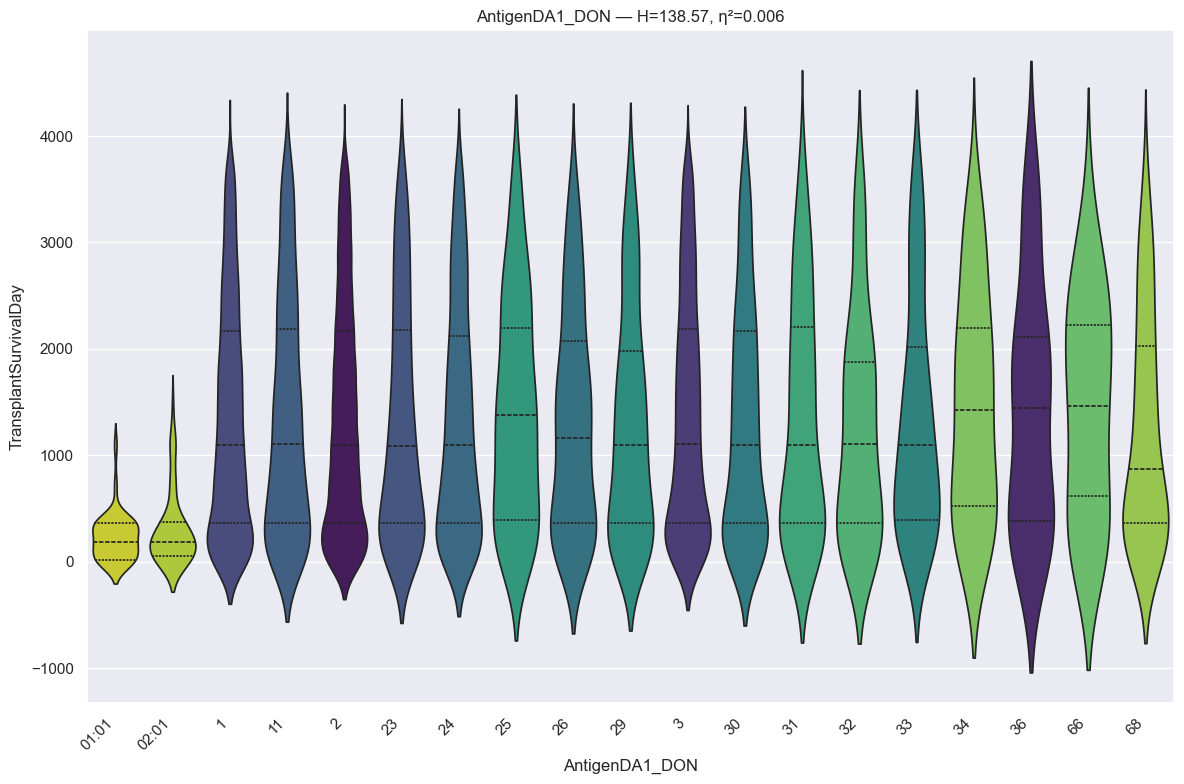

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:01                                             :     41 records
 * 02:01                                             :     64 records
 * 1                                                 :   4465 records
 * 11                                                :    874 records
 * 2                                                 :   7936 records
 * 23                                                :    743 records
 * 24                                                :   1194 records
 * 25                                                :    165 records
 * 26                                                :    246 records
 * 29                                                :    349 records
 * 3                                                 :   2472 records
 * 30                                                :    560 records
 * 31                                                :    191 records
 * 32                        

In [8]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [9]:
# mapping (any samples greater than 2)
mapping = {'01:02': 'Other',
 '02:03': 'Other',
 '02:05': 'Other-500s',
 '02:06': 'Other-200s',
 '03:01': 'Other-100s',
 '03:02': 'Other',
 '10': 'Other',
 '11:01': 'Other-300s',
 '24:02': 'Other-100s',
 '24:03': 'Other-800s',
 '26:01': 'Other',
 '28': 'Other',
 '29:02': 'Other-400s',
 '30:01': 'Other-300s',
 '33:03': 'Other-200s',
 '34:02': 'Other',
 '66:01': 'Other',
 '68:02': 'Other',
 '74': 'Other-1100s',
 'Missing': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDA1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             2         1332.905620                1099.0                 3947.0                    0.0          7936
             1         1335.125644                1099.0                 3945.0                    0.0          4465
             3         1364.078074                1106.0                 3836.0                    0.0          2472
            24         1317.361809                1095.0                 3745.0                    0.0          1194
            11         1360.885584                1105.0                 3845.0                    0.0           874
            23         1308.965007                1089.0                 3773.0                    0.0           743
            30         1305.155357                1095.0                 3677.0                    0.0           560
            29         1290.616046                1093.0        

In [10]:
# mapping (collapse)
mapping = {'02:01': 'Other-300s',
 '01:01': 'Other-200s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDA1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             2         1332.905620                1099.0                 3947.0                    0.0          7936
             1         1335.125644                1099.0                 3945.0                    0.0          4465
             3         1364.078074                1106.0                 3836.0                    0.0          2472
            24         1317.361809                1095.0                 3745.0                    0.0          1194
            11         1360.885584                1105.0                 3845.0                    0.0           874
            23         1308.965007                1089.0                 3773.0                    0.0           743
            30         1305.155357                1095.0                 3677.0                    0.0           560
            29         1290.616046                1093.0        

In [11]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :   4465 records
 * 11                                                :    874 records
 * 2                                                 :   7936 records
 * 23                                                :    743 records
 * 24                                                :   1194 records
 * 25                                                :    165 records
 * 26                                                :    246 records
 * 29                                                :    349 records
 * 3                                                 :   2472 records
 * 30                                                :    560 records
 * 31                                                :    191 records
 * 32                                                :    142 records
 * 33                                                :    182 records
 * 34                        

In [12]:
# mapping
mapping = {'Group_3': 'Group_1',
 'Other-100s': 'Group_2',
 'Other-200s': 'Group_3',
 'Other-300s': 'Group_4'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDA1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             2         1332.905620                1099.0                 3947.0                    0.0          7936
             1         1335.125644                1099.0                 3945.0                    0.0          4465
             3         1364.078074                1106.0                 3836.0                    0.0          2472
            24         1317.361809                1095.0                 3745.0                    0.0          1194
            11         1360.885584                1105.0                 3845.0                    0.0           874
            23         1308.965007                1089.0                 3773.0                    0.0           743
            30         1305.155357                1095.0                 3677.0                    0.0           560
            29         1290.616046                1093.0        

#### AntigenDA2
* Antigen 2 transplant usually refers to Human Leukocyte Antigen (HLA) Class II antigens (such as HLA-DR, -DQ, -DP), which are critical markers in transplantation. Preformed IgG antibodies against these antigens are significant risk factors for high-grade rejection, chronic graft dysfunction (such as transplant glomerulopathy), and poor outcomes in heart and kidney transplants.

In [13]:
# info
feature = u.get_feature_info(df, 'AntigenDA2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
AntigenDA2_DON  20007     46  68  2313

:::: NaN Count:
AntigenDA2_DON    0 



{'AntigenDA2_DON': CategoricalDtype(categories=['0', '01:01', '02:01', '02:03', '02:05', '02:06', '03:01',
                   '1', '10', '11', '11:01', '2', '23', '24', '24:02', '24:03',
                   '25', '26', '26:01', '28', '29', '29:01', '29:02', '3', '30',
                   '30:01', '30:02', '31', '32', '33', '33:01', '33:03', '34',
                   '34:02', '36', '43', '66', '66:01', '66:02', '68', '68:01',
                   '68:02', '69', '74', '80', 'Missing',
                   'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

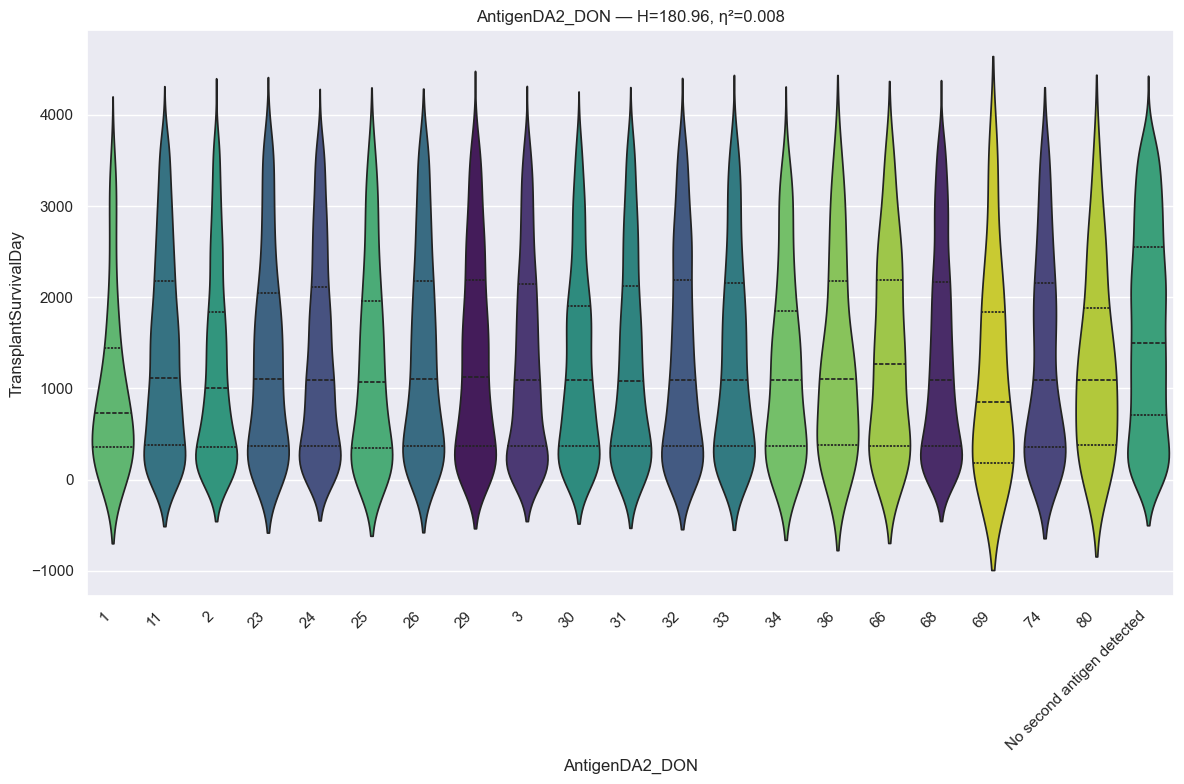

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :    123 records
 * 11                                                :   1179 records
 * 2                                                 :   1930 records
 * 23                                                :    657 records
 * 24                                                :   2205 records
 * 25                                                :    463 records
 * 26                                                :    712 records
 * 29                                                :   1046 records
 * 3                                                 :   2073 records
 * 30                                                :   1301 records
 * 31                                                :   1031 records
 * 32                                                :   1035 records
 * 33                                                :    881 records
 * 34                        

In [14]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [15]:
# mapping
mapping =  {'01:01': 'Other',
 '02:01': 'Other-300s',
 '02:03': 'Other',
 '02:05': 'Other-400s',
 '02:06': 'Other',
 '03:01': 'Other-100s',
 '10': 'Other',
 '11:01': 'Other-400s',
 '24:02': 'Other-200s',
 '24:03': 'Other-1100s',
 '26:01': 'Other-100s',
 '28': 'Other',
 '29:01': 'Other',
 '29:02': 'Other-200s',
 '30:01': 'Other-300s',
 '30:02': 'Other-400s',
 '33:01': 'Other',
 '33:03': 'Other-100s',
 '34:02': 'Other',
 '43': 'Other',
 '66:01': 'Other-1200s',
 '66:02': 'Other',
 '68:01': 'Other-400s',
 '68:02': 'Other',
 'Missing': 'Other-1100s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

            AntigenDA2_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                        68         1328.291396                1094.0                 3926.0                    0.0          2313
                        24         1313.414059                1096.0                 3836.0                    0.0          2205
                         3         1299.107574                1095.0                 3861.0                    0.0          2073
                         2         1215.125907                1001.0                 3945.0                    0.0          1930
No second antigen detected         1638.123442                1498.0                 3928.0                    0.0          1685
                        30         1274.135281                1092.0                 3773.0                    0.0          1301
                        11         1365.620865                1116.0                 3803.0      

In [16]:
# mapping
mapping =  {'1': 'Other-900s',
 '69': 'Other-1100s',
 '80': 'Other-1200s',
 'Other': 'Other-900s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

            AntigenDA2_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                        68         1328.291396                1094.0                 3926.0                    0.0          2313
                        24         1313.414059                1096.0                 3836.0                    0.0          2205
                         3         1299.107574                1095.0                 3861.0                    0.0          2073
                         2         1215.125907                1001.0                 3945.0                    0.0          1930
No second antigen detected         1638.123442                1498.0                 3928.0                    0.0          1685
                        30         1274.135281                1092.0                 3773.0                    0.0          1301
                        11         1365.620865                1116.0                 3803.0      

In [17]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 11                                                :   1179 records
 * 2                                                 :   1930 records
 * 23                                                :    657 records
 * 24                                                :   2205 records
 * 25                                                :    463 records
 * 26                                                :    712 records
 * 29                                                :   1046 records
 * 3                                                 :   2073 records
 * 30                                                :   1301 records
 * 31                                                :   1031 records
 * 32                                                :   1035 records
 * 33                                                :    881 records
 * 34                                                :    260 records
 * 36                        

In [18]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

####  Antigen DB1
* HLA-DRB1 matching is critical in transplantation to minimize graft-versus-host disease (GVHD) in stem cell transplants and reduce mortality. In solid organ transplant, HLA-DRB1, along with HLA-A, B, DQ, and DP, are key targets for donor-specific antibodies (DSAs), which, if present, can lead to antibody-mediated rejection (AMR).

In [19]:
# info
feature = u.get_feature_info(df, 'AntigenDB1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
AntigenDB1_DON  20007     76   7  3978

:::: NaN Count:
AntigenDB1_DON    0 



{'AntigenDB1_DON': CategoricalDtype(categories=['07:02', '08:01', '13', '13:02', '14', '14:01', '14:02',
                   '15', '15:01', '15:03', '15:07', '15:10', '15:16', '15:17',
                   '15:18', '18', '27', '27:04', '27:05', '35', '35:01',
                   '35:02', '35:03', '35:08', '35:12', '37', '38', '38:01',
                   '39', '39:01', '39:02', '39:06', '40', '40:01', '40:02',
                   '40:05', '40:06', '41', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '49', '50',
                   '50:01', '51', '51:01', '51:02', '52', '53', '54', '55',
                   '55:01', '56', '56:03', '57', '58', '59', '60', '61', '62',
                   '63', '64', '65', '7', '70', '703', '71', '72', '75', '76',
                   '77', '78', '8', '81', 'Missing'],
 , ordered=False, categories_dtype=object)}

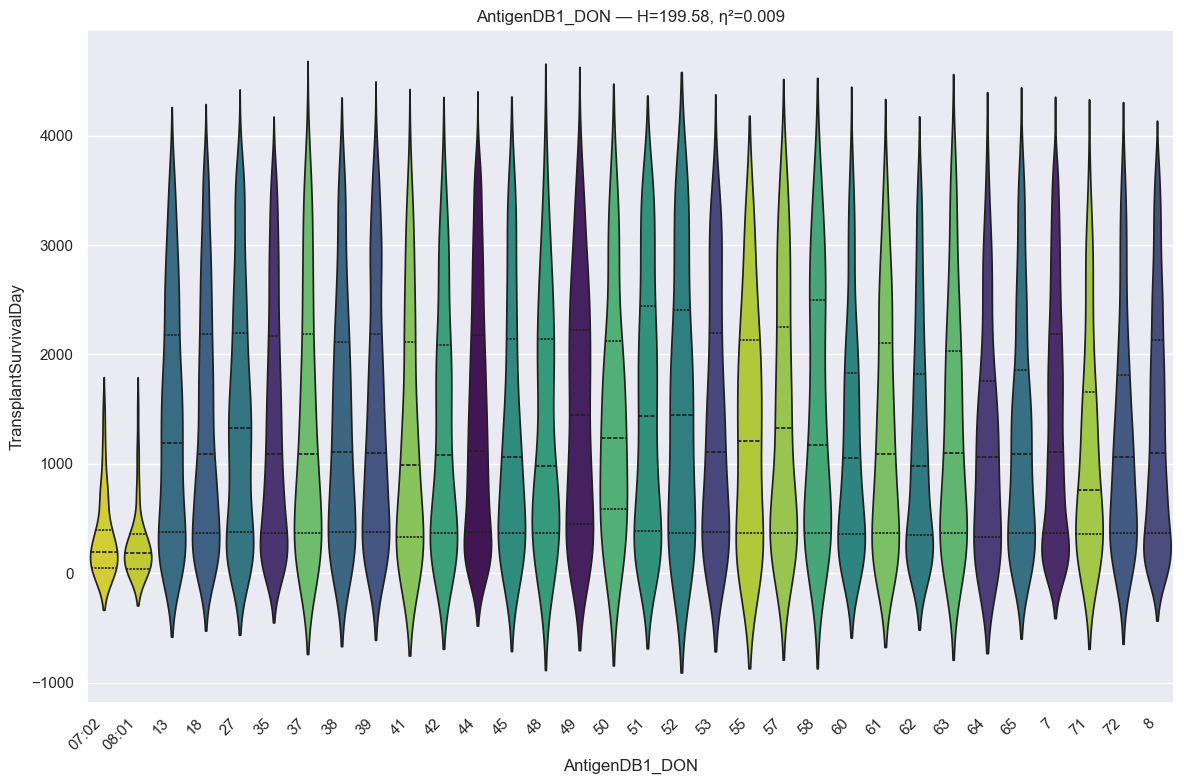

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 07:02                                             :     54 records
 * 08:01                                             :     47 records
 * 13                                                :    601 records
 * 18                                                :   1101 records
 * 27                                                :    831 records
 * 35                                                :   2413 records
 * 37                                                :    249 records
 * 38                                                :    308 records
 * 39                                                :    575 records
 * 41                                                :    171 records
 * 42                                                :    272 records
 * 44                                                :   1766 records
 * 45                                                :    263 records
 * 48                        

In [20]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [21]:
# mapping
mapping =  {'13:02': 'Other-300s',
 '14': 'Other-1300s',
 '14:01': 'Other-600s',
 '14:02': 'Other-100s',
 '15': 'Other-300s',
 '15:01': 'Other-200s',
 '15:03': 'Other',
 '15:10': 'Other',
 '15:16': 'Other',
 '15:18': 'Other',
 '27:05': 'Other-500s',
 '35:01': 'Other-200s',
 '35:02': 'Other',
 '35:03': 'Other',
 '35:08': 'Other',
 '35:12': 'Other',
 '38:01': 'Other',
 '39:01': 'Other-1900s',
 '39:02': 'Other-1400s',
 '39:06': 'Other',
 '40': 'Other',
 '40:01': 'Other-400s',
 '40:02': 'Other',
 '40:05': 'Other-1300s',
 '41:02': 'Other',
 '42:01': 'Other',
 '42:02': 'Other',
 '44:02': 'Other-200s',
 '44:03': 'Other-400s',
 '46': 'Other-1300s',
 '47': 'Other-1300s',
 '50:01': 'Other-200s',
 '51:01': 'Other-400s',
 '51:02': 'Other',
 '54': 'Other',
 '55:01': 'Other',
 '56': 'Other-1200s',
 '59': 'Other',
 '70': 'Other-1300s',
 '75': 'Other-1100s',
 '77': 'Other',
 '78': 'Other',
 '81': 'Other-1400s',
 'Missing': 'Other'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDB1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             7         1368.573906                1112.5                 3947.0                    0.0          3978
             8         1305.704305                1095.0                 3704.0                    0.0          2648
            35         1326.891007                1093.0                 3725.0                    0.0          2413
            44         1383.828992                1120.0                 3928.0                    0.0          1766
            18         1341.009991                1092.0                 3765.0                    0.0          1101
            62         1172.743169                 980.0                 3662.0                    0.0           915
            27         1423.552347                1324.0                 3861.0                    0.0           831
            13         1385.760399                1188.0        

In [22]:
# mapping
mapping =  {'08:01': 'Other-200s',
 '71': 'Other-1100s',
 '41': 'Other-1200s',
 '07:02': 'Other-300s',
 'Other': 'Other-500s',
 '58': 'Other-1400s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDB1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             7         1368.573906                1112.5                 3947.0                    0.0          3978
             8         1305.704305                1095.0                 3704.0                    0.0          2648
            35         1326.891007                1093.0                 3725.0                    0.0          2413
            44         1383.828992                1120.0                 3928.0                    0.0          1766
            18         1341.009991                1092.0                 3765.0                    0.0          1101
            62         1172.743169                 980.0                 3662.0                    0.0           915
            27         1423.552347                1324.0                 3861.0                    0.0           831
            13         1385.760399                1188.0        

In [23]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    601 records
 * 18                                                :   1101 records
 * 27                                                :    831 records
 * 35                                                :   2413 records
 * 37                                                :    249 records
 * 38                                                :    308 records
 * 39                                                :    575 records
 * 42                                                :    272 records
 * 44                                                :   1766 records
 * 45                                                :    263 records
 * 48                                                :     75 records
 * 49                                                :    261 records
 * 50                                                :     87 records
 * 51                        

In [24]:
# mapping
mapping = {'13': 'Group_1',
 '18': 'Group_1',
 '27': 'Group_1',
 '35': 'Group_1',
 '37': 'Group_1',
 '38': 'Group_1',
 '39': 'Group_1',
 '42': 'Group_1',
 '44': 'Group_1',
 '45': 'Group_1',
 '48': 'Group_1',
 '49': 'Group_1',
 '50': 'Group_1',
 '51': 'Group_1',
 '52': 'Group_1',
 '53': 'Group_1',
 '55': 'Group_1',
 '57': 'Group_1',
 '60': 'Group_1',
 '61': 'Group_1',
 '62': 'Group_1',
 '63': 'Group_1',
 '64': 'Group_1',
 '65': 'Group_1',
 '7': 'Group_1',
 '72': 'Group_1',
 '8': 'Group_1',
 'Other-1100s': 'Group_1',
 'Other-1200s': 'Group_1',
 'Other-1300s': 'Group_1',
 'Other-1400s': 'Group_1',
 'Other-200s': 'Group_2',
 'Other-300s': 'Group_2',
 'Other-500s': 'Group_2'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDB1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
       Group_1         1336.571349                1099.0                 3947.0                    0.0         19776
       Group_2          360.420213                 196.0                 3289.0                    0.0           188
    Other-400s          429.800000                 346.5                 1524.0                   21.0            20
   Other-1900s         1924.294118                1830.0                 3655.0                   24.0            17
    Other-100s          175.000000                  68.0                  426.0                   31.0             3
    Other-600s          619.333333                 742.0                  766.0                  350.0             3


#### Antigen DB2
* Transplantation antigens are proteins or peptides, primarily Major Histocompatibility Complex (MHC/HLA) molecules, that the immune system recognizes as foreign, triggering rejection in solid organ transplants. In mouse models, specifically H-2Db (a Class I MHC molecule), studies show that antigen-specific CD8+ T-cells are crucial for recognizing and rejecting donor tissue. 

In [25]:
# info
feature = u.get_feature_info(df, 'AntigenDB2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
AntigenDB2_DON  20007     85  44  2826

:::: NaN Count:
AntigenDB2_DON    0 



{'AntigenDB2_DON': CategoricalDtype(categories=['07:02', '08:01', '12', '13', '13:02', '14', '14:01',
                   '14:02', '15', '15:01', '15:10', '15:16', '15:17', '18',
                   '22', '27', '27:05', '27:08', '35', '35:01', '35:02',
                   '35:03', '35:08', '35:12', '37', '38', '38:01', '39',
                   '39:01', '39:02', '39:05', '39:06', '40', '40:01', '40:02',
                   '40:05', '41', '41:01', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '48:01',
                   '49', '50', '50:01', '51', '51:01', '51:02', '52', '53',
                   '54', '55', '55:01', '56', '56:01', '57', '57:01', '57:03',
                   '58', '59', '60', '61', '62', '63', '64', '65', '67', '7',
                   '70', '71', '72', '73', '75', '76', '77', '78', '8', '81',
                   '82', '82:01', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

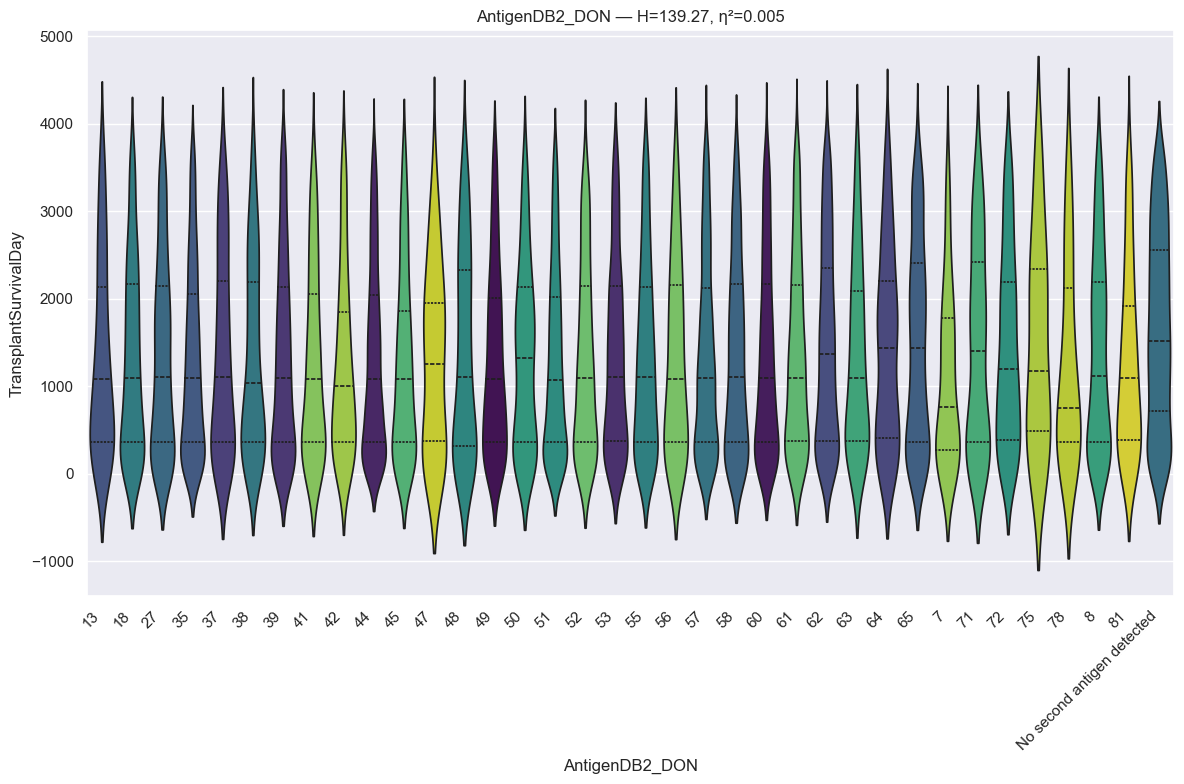

RANKING REPORT: AntigenDB2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    163 records
 * 18                                                :    467 records
 * 27                                                :    447 records
 * 35                                                :   1392 records
 * 37                                                :    240 records
 * 38                                                :    280 records
 * 39                                                :    633 records
 * 41                                                :    227 records
 * 42                                                :    218 records
 * 44                                                :   2826 records
 * 45                                                :    425 records
 * 47                                                :     60 records
 * 48                                                :    167 records
 * 49                        

In [26]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [27]:
# mapping
mapping =  {'07:02': 'Other',
 '08:01': 'Other-200s',
 '12': 'Other',
 '13:02': 'Other-100s',
 '14': 'Other',
 '14:01': 'Other',
 '14:02': 'Other',
 '15': 'Other',
 '15:01': 'Other-300s',
 '15:10': 'Other',
 '15:17': 'Other',
 '27:05': 'Other-100s',
 '27:08': 'Other',
 '35:01': 'Other-200s',
 '35:02': 'Other',
 '35:03': 'Other',
 '35:08': 'Other',
 '35:12': 'Other',
 '38:01': 'Other',
 '39:01': 'Other-1000s',
 '39:02': 'Other-1000s',
 '39:05': 'Other-500s',
 '39:06': 'Other',
 '40': 'Other-1300s',
 '40:01': 'Other-400s',
 '40:05': 'Other-1000s',
 '41:01': 'Other',
 '41:02': 'Other',
 '42:01': 'Other-100s',
 '44:02': 'Other-300s',
 '44:03': 'Other-200s',
 '46': 'Other-1300s',
 '48:01': 'Other',
 '50:01': 'Other-200s',
 '51:01': 'Other',
 '51:02': 'Other-900s',
 '54': 'Other-1000s',
 '55:01': 'Other-100s',
 '56:01': 'Other',
 '57:01': 'Other-200s',
 '57:03': 'Other-300s',
 '59': 'Other-300s',
 '67': 'Other-2200s',
 '70': 'Other-1100s',
 '73': 'Other-500s',
 '76': 'Other',
 '77': 'Other-1800s',
 '82': 'Other-1300s',
 'Missing': 'Other-600s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

            AntigenDB2_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                        44         1273.490800                1086.0                 3861.0                    0.0          2826
                        51         1259.640959                1073.0                 3702.0                    0.0          1543
                        35         1275.472701                1091.0                 3725.0                    0.0          1392
                        57         1325.569738                1093.0                 3926.0                    0.0          1183
                        60         1321.175376                1090.0                 3945.0                    0.0          1129
                        62         1466.164408                1371.0                 3947.0                    0.0          1107
No second antigen detected         1654.549020                1522.5                 3692.0      

In [28]:
# mapping
mapping =  {'Other-1000s': 'Other-1100s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

            AntigenDB2_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                        44         1273.490800                1086.0                 3861.0                    0.0          2826
                        51         1259.640959                1073.0                 3702.0                    0.0          1543
                        35         1275.472701                1091.0                 3725.0                    0.0          1392
                        57         1325.569738                1093.0                 3926.0                    0.0          1183
                        60         1321.175376                1090.0                 3945.0                    0.0          1129
                        62         1466.164408                1371.0                 3947.0                    0.0          1107
No second antigen detected         1654.549020                1522.5                 3692.0      

In [29]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDB2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    163 records
 * 18                                                :    467 records
 * 27                                                :    447 records
 * 35                                                :   1392 records
 * 37                                                :    240 records
 * 38                                                :    280 records
 * 39                                                :    633 records
 * 41                                                :    227 records
 * 42                                                :    218 records
 * 44                                                :   2826 records
 * 45                                                :    425 records
 * 47                                                :     60 records
 * 48                                                :    167 records
 * 49                        

In [30]:
# mapping
mapping = {'13': 'Group_1',
 '18': 'Group_1',
 '27': 'Group_1',
 '35': 'Group_1',
 '37': 'Group_1',
 '38': 'Group_1',
 '39': 'Group_1',
 '41': 'Group_1',
 '42': 'Group_1',
 '44': 'Group_1',
 '45': 'Group_1',
 '47': 'Group_1',
 '48': 'Group_1',
 '49': 'Group_1',
 '50': 'Group_1',
 '51': 'Group_1',
 '52': 'Group_1',
 '53': 'Group_1',
 '55': 'Group_1',
 '56': 'Group_1',
 '57': 'Group_1',
 '58': 'Group_1',
 '60': 'Group_1',
 '61': 'Group_1',
 '62': 'Group_1',
 '63': 'Group_1',
 '64': 'Group_1',
 '65': 'Group_1',
 '7': 'Group_1',
 '71': 'Group_1',
 '72': 'Group_1',
 '75': 'Group_1',
 '78': 'Group_1',
 '8': 'Group_1',
 '81': 'Group_1',
 'No second antigen detected': 'Group_1',
 'Other-1100s': 'Group_1',
 'Other-1300s': 'Group_1',
 'Other': 'Group_2',
 'Other-300s': 'Group_2',
 'Other-200s': 'Group_3'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDB2_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
       Group_1         1335.654227                1099.0                 3947.0                    0.0         19802
       Group_2          390.034884                 189.5                 2920.0                    7.0            86
       Group_3          249.090909                 185.5                 1096.0                    0.0            44
    Other-100s          178.227273                 182.5                  384.0                   15.0            22
    Other-500s          585.066667                 388.0                 1470.0                   21.0            15
    Other-400s          454.500000                 357.0                 1524.0                    4.0            12
    Other-900s          991.916667                 872.0                 2138.0                  158.0            12
    Other-600s          616.833333                  97.5        

#### Antigen DR1
* HLA-DR1 is a specific antigen within the HLA Class II system that plays a significant role in transplantation compatibility. Recipients with the HLA-DR1 phenotype often show increased overall graft survival and are considered `low responders`, meaning they have a lower risk of organ rejection, particularly of kidneys.

In [31]:
# info
feature = u.get_feature_info(df, 'AntigenDR1', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
AntigenDR1_DON  20007     43   4  5012

:::: NaN Count:
AntigenDR1_DON    0 



{'AntigenDR1_DON': CategoricalDtype(categories=['01:01', '01:02', '01:03', '03:01', '03:02', '04:01',
                   '04:02', '04:03', '04:04', '04:05', '04:07', '04:11',
                   '08:01', '08:02', '09:01', '1', '10', '103', '11', '11:01',
                   '11:03', '11:04', '12', '12:01', '13', '13:01', '13:02',
                   '13:03', '13:05', '14', '14:02', '14:04', '14:54', '15',
                   '15:01', '16', '17', '18', '3', '4', '7', '8', '9',
                   'Missing'],
 , ordered=False, categories_dtype=object)}

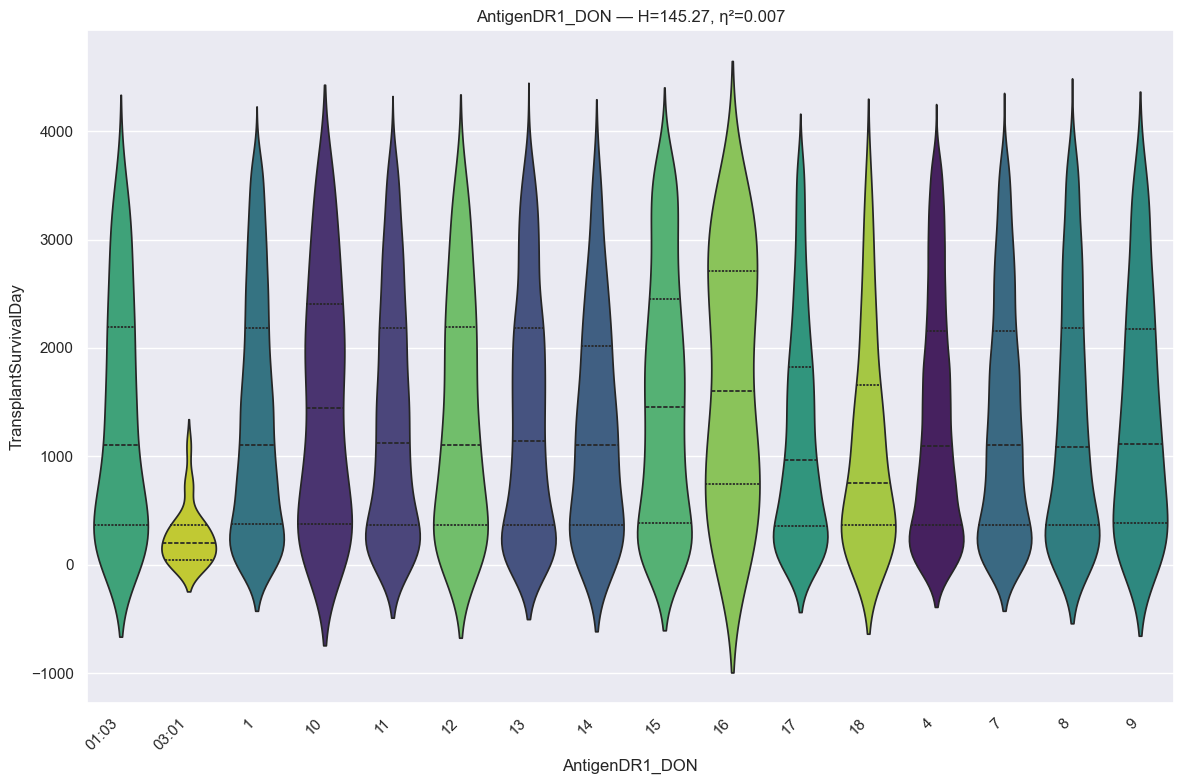

RANKING REPORT: AntigenDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :    344 records
 * 03:01                                             :     48 records
 * 1                                                 :   3180 records
 * 10                                                :    244 records
 * 11                                                :   1590 records
 * 12                                                :    309 records
 * 13                                                :   1472 records
 * 14                                                :    333 records
 * 15                                                :    757 records
 * 16                                                :     58 records
 * 17                                                :   1930 records
 * 18                                                :    257 records
 * 4                                                 :   5012 records
 * 7                         

In [32]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [33]:
# mapping
mapping =  {'01:01': 'Other-300s',
 '01:02': 'Other-300s',
 '03:02': 'Other-400s',
 '04:01': 'Other-300s',
 '04:02': 'Other',
 '04:03': 'Other',
 '04:04': 'Other-200s',
 '04:05': 'Other',
 '04:07': 'Other-300s',
 '04:11': 'Other',
 '08:01': 'Other',
 '08:02': 'Other-200s',
 '09:01': 'Other-100s',
 '103': 'Other-<100',
 '11:01': 'Other-400s',
 '11:03': 'Other',
 '11:04': 'Other',
 '12:01': 'Other',
 '13:01': 'Other-400s',
 '13:02': 'Other-200s',
 '13:03': 'Other',
 '13:05': 'Other',
 '14:04': 'Other',
 '14:54': 'Other',
 '15:01': 'Other-400s',
 '3': 'Other-2500s',
 'Missing': 'Other-2100s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDR1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             4         1327.943935                1095.0                 3861.0                    0.0          5012
             1         1363.427673                1108.0                 3803.0                    0.0          3180
             7         1333.009652                1103.0                 3928.0                    0.0          2901
            17         1176.674611                 963.0                 3724.0                    0.0          1930
            11         1370.537107                1124.0                 3836.0                    0.0          1590
            13         1379.312500                1143.5                 3945.0                    0.0          1472
             8         1329.870556                1088.0                 3947.0                    0.0          1097
            15         1527.989432                1456.0        

In [34]:
# mapping
mapping =  {'03:01': 'Other-200s',     
 'Other': 'Other-400s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDR1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             4         1327.943935                1095.0                 3861.0                    0.0          5012
             1         1363.427673                1108.0                 3803.0                    0.0          3180
             7         1333.009652                1103.0                 3928.0                    0.0          2901
            17         1176.674611                 963.0                 3724.0                    0.0          1930
            11         1370.537107                1124.0                 3836.0                    0.0          1590
            13         1379.312500                1143.5                 3945.0                    0.0          1472
             8         1329.870556                1088.0                 3947.0                    0.0          1097
            15         1527.989432                1456.0        

In [35]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :    344 records
 * 1                                                 :   3180 records
 * 10                                                :    244 records
 * 11                                                :   1590 records
 * 12                                                :    309 records
 * 13                                                :   1472 records
 * 14                                                :    333 records
 * 15                                                :    757 records
 * 16                                                :     58 records
 * 17                                                :   1930 records
 * 18                                                :    257 records
 * 4                                                 :   5012 records
 * 7                                                 :   2901 records
 * 8                         

In [36]:
# mapping
mapping = {'01:03': 'Group_1',
 '1': 'Group_1',
 '10': 'Group_1',
 '11': 'Group_1',
 '12': 'Group_1',
 '13': 'Group_1',
 '14': 'Group_1',
 '15': 'Group_1',
 '16': 'Group_1',
 '17': 'Group_1',
 '18': 'Group_1',
 '4': 'Group_1',
 '7': 'Group_1',
 '8': 'Group_1',
 '9': 'Group_1',
 'Other-200s': 'Group_2',
 'Other-300s': 'Group_3',
 'Other-400s': 'Group_4'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDR1_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
       Group_1         1335.085191                1099.0                 3947.0                    0.0         19826
       Group_2          261.761194                 187.0                 1110.0                    0.0            67
       Group_3          346.415094                 205.0                 1524.0                    7.0            53
       Group_4          457.782609                 329.0                 1458.0                    8.0            46
    Other-<100           31.000000                  32.0                   55.0                   11.0             5
   Other-2500s         2528.750000                2389.0                 3571.0                 1766.0             4
    Other-100s          138.666667                  49.0                  336.0                   31.0             3
   Other-2100s         2148.333333                1714.0        

#### Antigen DR2
* HLA-DR2 (a specific type of Human Leukocyte Antigen, part of Class II MHC) is a key protein in transplant immunology that affects compatibility and immune response. While HLA matching is generally essential, the presence of DR2 has historically been linked to higher sensitization and potentially lower graft survival in kidney transplants.

In [37]:
# info
feature = u.get_feature_info(df, 'AntigenDR2', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top  freq
AntigenDR2_DON  20007     44  15  4192

:::: NaN Count:
AntigenDR2_DON    0 



{'AntigenDR2_DON': CategoricalDtype(categories=['01:01', '01:03', '03:01', '04:01', '04:04', '04:05',
                   '04:07', '08:01', '08:02', '09:01', '1', '10', '103', '11',
                   '11:01', '11:03', '11:04', '12', '12:01', '12:02', '13',
                   '13:01', '13:02', '13:03', '13:05', '14', '14:01', '14:02',
                   '14:04', '14:06', '14:54', '15', '15:01', '15:02', '15:03',
                   '16', '16:01', '16:02', '17', '18', '3', '4', '5', '7', '8',
                   '9', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

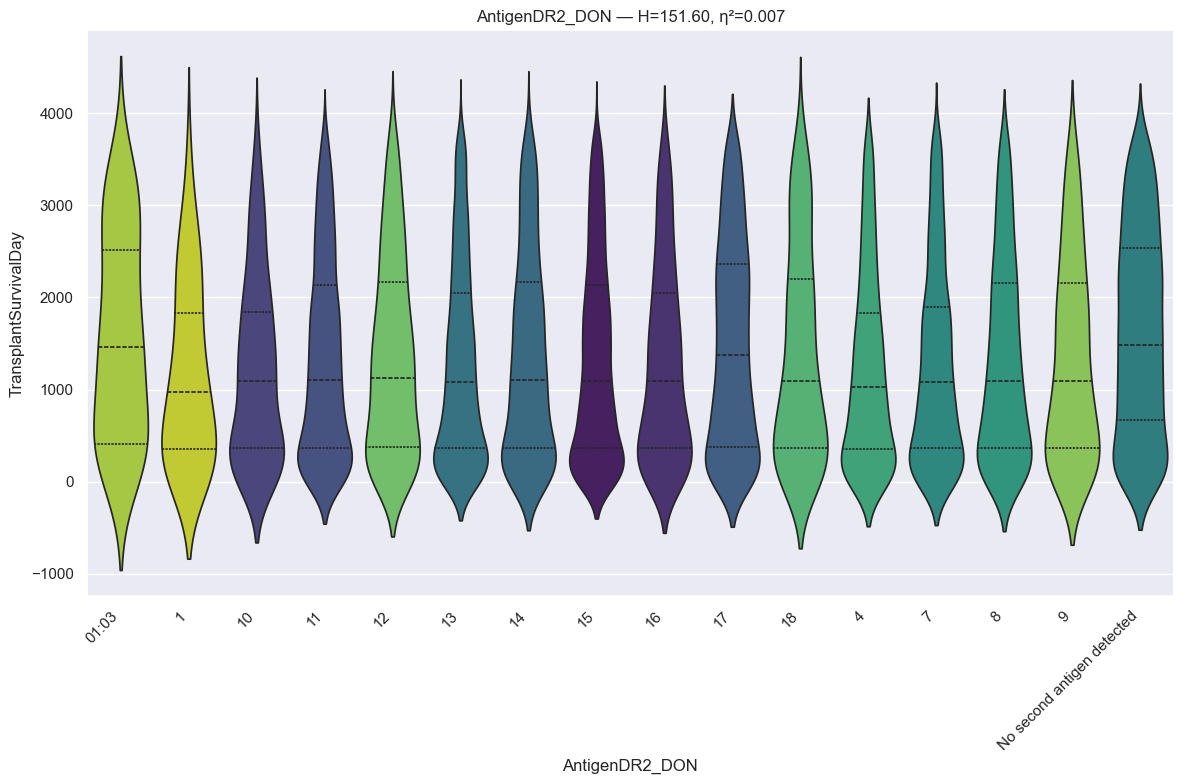

RANKING REPORT: AntigenDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :     59 records
 * 1                                                 :     66 records
 * 10                                                :    236 records
 * 11                                                :   2007 records
 * 12                                                :    530 records
 * 13                                                :   3124 records
 * 14                                                :   1146 records
 * 15                                                :   4192 records
 * 16                                                :    712 records
 * 17                                                :   1833 records
 * 18                                                :    291 records
 * 4                                                 :   1370 records
 * 7                                                 :   1724 records
 * 8                         

In [38]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [39]:
 # mapping
mapping = {'01:01': 'Other',
 '03:01': 'Other-200s',
 '04:01': 'Other-500s',
 '04:04': 'Other',
 '04:05': 'Other',
 '08:01': 'Other-300s',
 '08:02': 'Other',
 '09:01': 'Other-200s',
 '103': 'Other',
 '11:01': 'Other-100s',
 '11:03': 'Other-200s',
 '11:04': 'Other-300s',
 '12:01': 'Other-300s',
 '13:01': 'Other-300s',
 '13:02': 'Other-200s',
 '13:03': 'Other-300s',
 '13:05': 'Other',
 '14:01': 'Other',
 '14:02': 'Other-400s',
 '14:04': 'Other-1200s',
 '14:06': 'Other',
 '14:54': 'Other-200s',
 '15:01': 'Other-200s',
 '15:02': 'Other-300s',
 '15:03': 'Other-200s',
 '16:01': 'Other-500s',
 '16:02': 'Other-200s',
 'Missing': 'Other-900s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

            AntigenDR2_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                        15         1313.574905                1094.0                 3945.0                    0.0          4192
                        13         1268.121319                1082.5                 3947.0                    0.0          3124
                        11         1326.679621                1100.0                 3803.0                    0.0          2007
                        17         1463.146208                1379.0                 3719.0                    0.0          1833
                         7         1274.313805                1085.0                 3860.0                    0.0          1724
                         4         1214.260584                1031.0                 3682.0                    0.0          1370
No second antigen detected         1613.149665                1483.0                 3799.0      

In [40]:
 # mapping
mapping = {'Other': 'Other-200s',    
 '10': 'Other-1200s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

            AntigenDR2_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                        15         1313.574905                1094.0                 3945.0                    0.0          4192
                        13         1268.121319                1082.5                 3947.0                    0.0          3124
                        11         1326.679621                1100.0                 3803.0                    0.0          2007
                        17         1463.146208                1379.0                 3719.0                    0.0          1833
                         7         1274.313805                1085.0                 3860.0                    0.0          1724
                         4         1214.260584                1031.0                 3682.0                    0.0          1370
No second antigen detected         1613.149665                1483.0                 3799.0      

In [41]:
# values for NominalSurvivalRanker
class_values = {"method": "bonferroni", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: AntigenDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :     59 records
 * 1                                                 :     66 records
 * 11                                                :   2007 records
 * 12                                                :    530 records
 * 13                                                :   3124 records
 * 14                                                :   1146 records
 * 15                                                :   4192 records
 * 16                                                :    712 records
 * 17                                                :   1833 records
 * 18                                                :    291 records
 * 4                                                 :   1370 records
 * 7                                                 :   1724 records
 * 8                                                 :    920 records
 * 9                         

In [42]:
# mapping
mapping = {'01:03': 'Group_1',
 '1': 'Group_1',
 '11': 'Group_1',
 '12': 'Group_1',
 '13': 'Group_1',
 '14': 'Group_1',
 '15': 'Group_1',
 '16': 'Group_1',
 '17': 'Group_1',
 '18': 'Group_1',
 '4': 'Group_1',
 '7': 'Group_1',
 '8': 'Group_1',
 '9': 'Group_1',
 'No second antigen detected': 'Group_1',
 'Other-1200s': 'Group_1',
 'Other-200s': 'Group_2',
 'Other-300s': 'Group_3'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntigenDR2_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
       Group_1         1334.963157                1099.0                 3947.0                    0.0         19841
       Group_2          256.417722                 180.0                 1498.0                    8.0            79
       Group_3          349.235294                 205.0                 1150.0                    9.0            51
    Other-100s          197.285714                 181.0                  498.0                   11.0            14
    Other-500s          572.888889                 392.0                 1524.0                   51.0             9
    Other-900s          970.222222                 719.0                 3289.0                    3.0             9
    Other-400s          441.000000                 455.5                  752.0                  101.0             4


#### Citizenship

In [43]:
# info
feature = u.get_feature_info(df, 'Citizenship', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique         top   freq
Citizenship_DON  20007      7  US Citizen  18000

:::: NaN Count:
Citizenship_DON    0 



{'Citizenship_DON': CategoricalDtype(categories=['Missing', 'NON-RESIDENT ALIEN',
                   'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant',
                   'Non-US Citizen/US Resident', 'RESIDENT ALIEN', 'US Citizen',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

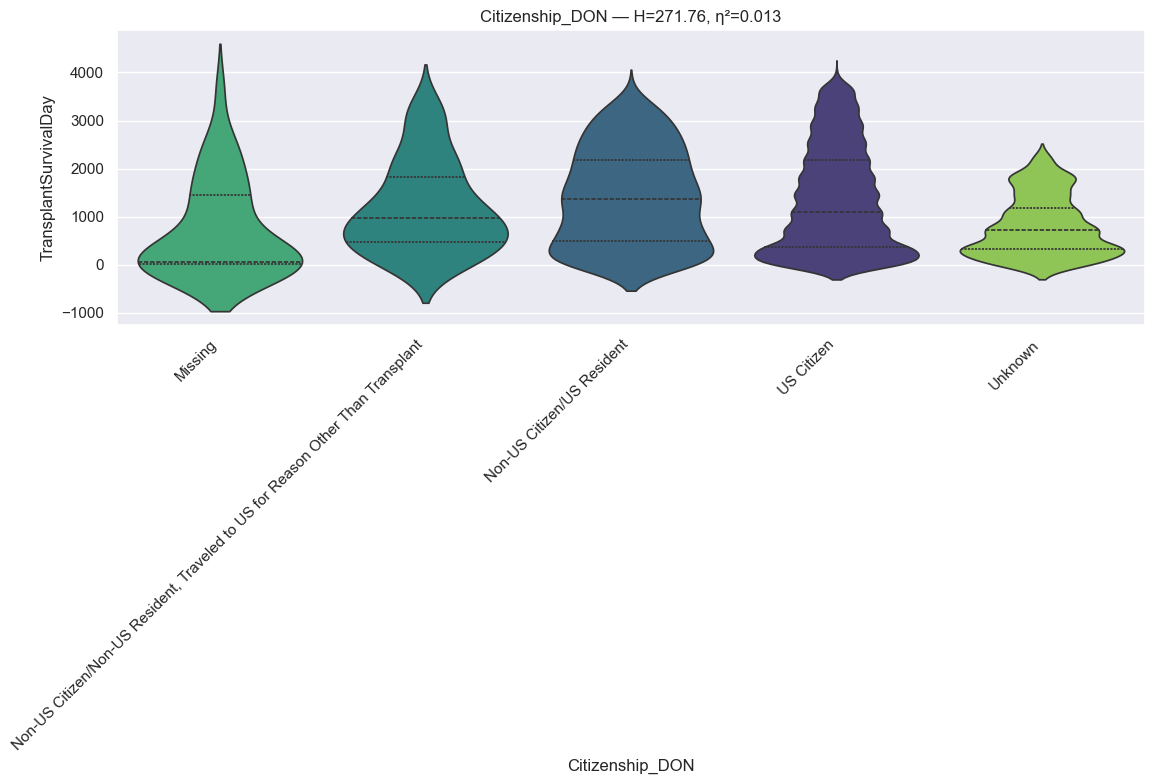

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     36 records
 * Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     74 records
 * Non-US Citizen/US Resident                        :    668 records
 * US Citizen                                        :  18000 records
 * Unknown                                           :   1190 records
BYPASSED CATEGORIES (n < min_n):
 * NON-RESIDENT ALIEN                                :     10 records
 * RESIDENT ALIEN                                    :     29 records
--------------------------------------------------------------------------------
Kruskal H: 271.7595 | P-value: 1.332039e-57 | Effect η²: 0.0134
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
US Citizen   vs Unknown      | p=2.3709e-55 | thr=0.0050 | r=-0.27

In [44]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [45]:
# mapping
mapping = {'NON-RESIDENT ALIEN': 'Other',
           'RESIDENT ALIEN': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

                                                                Citizenship_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                                                                     US Citizen         1358.029611                1104.0                 3947.0                    0.0         18000
                                                                        Unknown          799.182353                 717.0                 2218.0                    0.0          1190
                                                     Non-US Citizen/US Resident         1391.616766                1362.0                 3520.0                    0.0           668
Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant         1193.905405                 967.0                 3371.0                    6.0            74
                                                                          Other         26

In [46]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     36 records
 * Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     74 records
 * Non-US Citizen/US Resident                        :    668 records
 * Other                                             :     39 records
 * US Citizen                                        :  18000 records
 * Unknown                                           :   1190 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 312.0431 | P-value: 2.576417e-65 | Effect η²: 0.0154
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 4 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORI

In [47]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Past Cocaine Use

In [48]:
# info
feature = u.get_feature_info(df, 'PastCocaineUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top   freq
PastCocaineUse_DON  20007      4  No  14941

:::: NaN Count:
PastCocaineUse_DON    0 



{'PastCocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

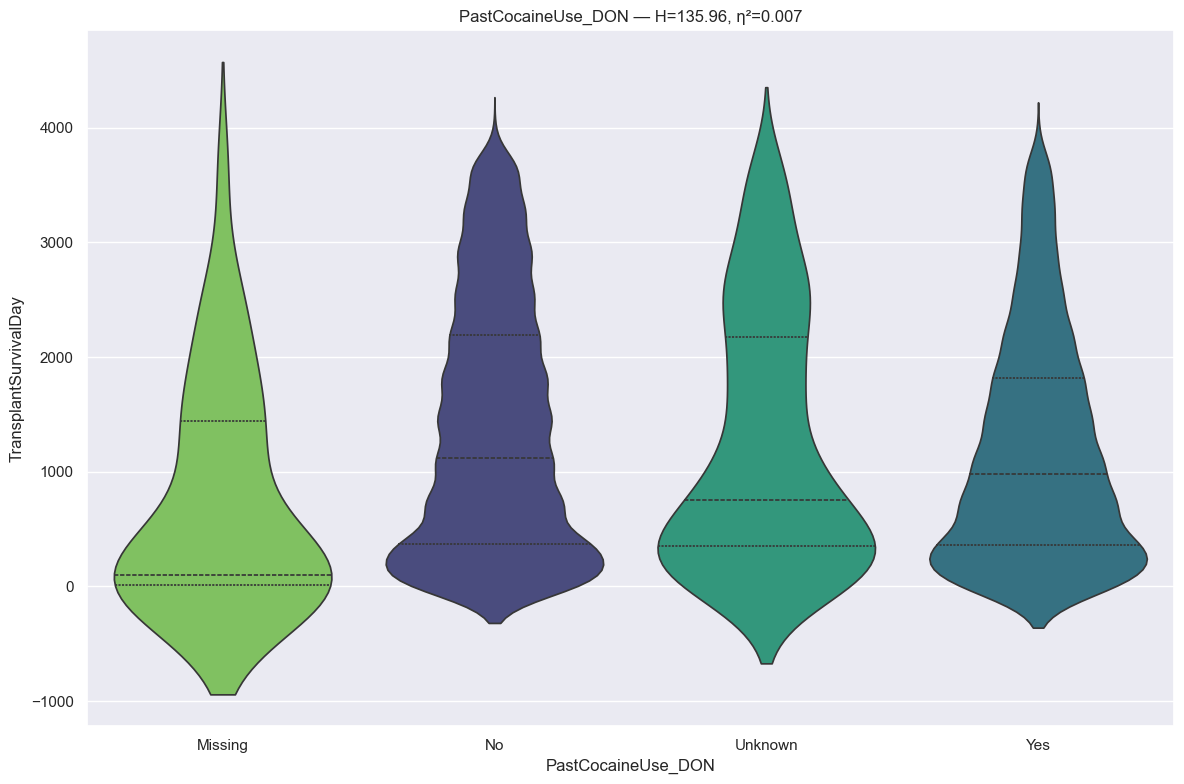

RANKING REPORT: PastCocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  14941 records
 * Unknown                                           :    383 records
 * Yes                                               :   4645 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 135.9621 | P-value: 2.805587e-29 | Effect η²: 0.0066
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.8975e-26 | thr=0.0083 | r=-0.103 | *Sig*
Missing      vs No           | p=4.2176e-06 | thr=0.0083 | r= 0.431 | *Sig*
Missing      vs Yes          | p=9.5442e-05 | thr=0.0083 | r= 0.367 | *Sig*
Missing      vs Unknown      | p=1.7079e-04 | thr=0.0083 | r= 0.370 | *Sig*
No   

In [49]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Ethnicity

In [50]:
# info
feature = u.get_feature_info(df, 'Ethnicity', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique                  top   freq
Ethnicity_DON  20007      7  White, Non-Hispanic  12428

:::: NaN Count:
Ethnicity_DON    0 



{'Ethnicity_DON': CategoricalDtype(categories=['Amer Ind/Alaska Native', 'Asian', 'Black', 'Hispanic',
                   'Multiracial', 'Native Hawaiian/other Pacific Islander',
                   'White, Non-Hispanic'],
 , ordered=False, categories_dtype=object)}

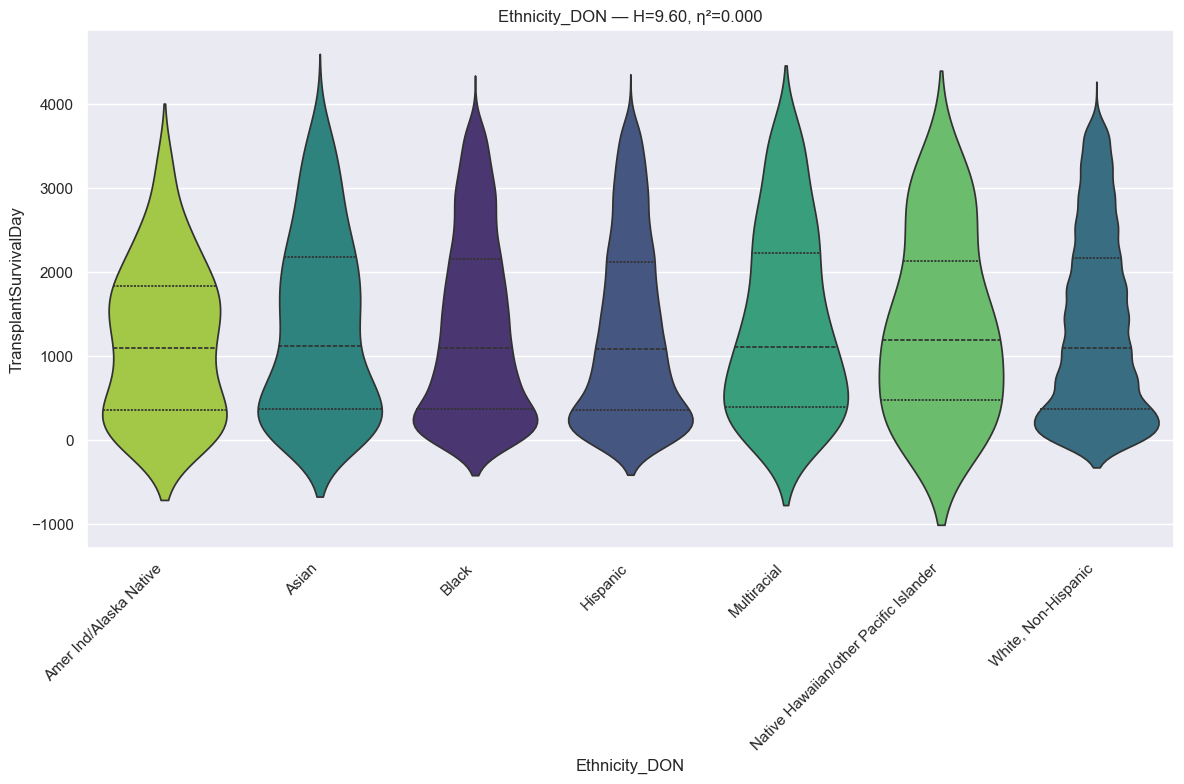

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Amer Ind/Alaska Native                            :    102 records
 * Asian                                             :    324 records
 * Black                                             :   3314 records
 * Hispanic                                          :   3629 records
 * Multiracial                                       :    172 records
 * Native Hawaiian/other Pacific Islander            :     38 records
 * White, Non-Hispanic                               :  12428 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 9.6015 | P-value: 1.424703e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Hispanic     vs White, Non-Hispanic | p=9.4816e-03 | thr=0.0024 | r= 0.028 | Not Sig
Amer Ind/Alaska Nativ

In [51]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [52]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** Non‑significant Global Kruskal–Wallis across all categories suggests there is no evidence that any ethnicity category differs in survival distribution, confirmed by the pairwise testing, therefore no splitting is justified.

#### Hepatitis B Core Antibody

In [53]:
# info
feature = u.get_feature_info(df, 'Hepatitis_B_CoreAntibody', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                              count unique       top   freq
Hepatitis_B_CoreAntibody_DON  20007      5  Negative  19595

:::: NaN Count:
Hepatitis_B_CoreAntibody_DON    0 



{'Hepatitis_B_CoreAntibody_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

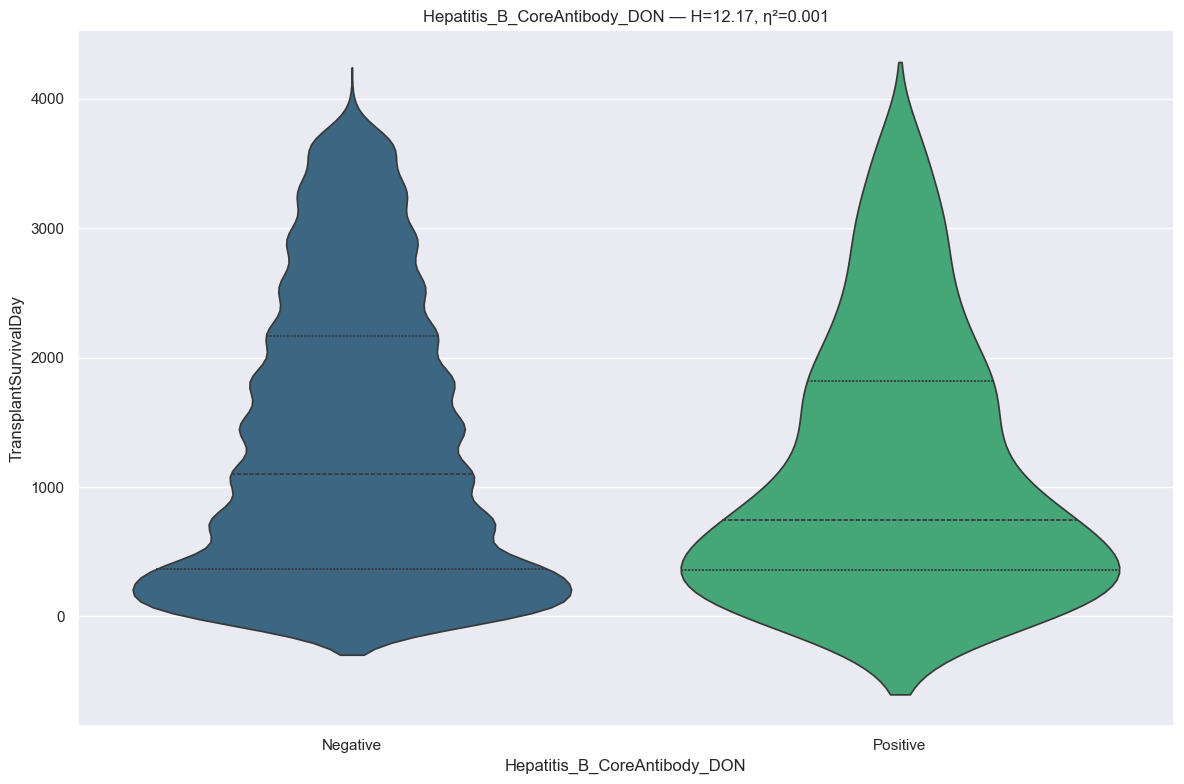

RANKING REPORT: Hepatitis_B_CoreAntibody_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :  19595 records
 * Positive                                          :    400 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :      1 records
 * Not Done                                          :     10 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 12.1671 | P-value: 4.863923e-04 | Effect η²: 0.0006
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=4.8640e-04 | thr=0.0500 | r=-0.102 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Grou

In [54]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [55]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Not Done': 'Other',
           'Indeterminate': 'Other',
           'Pending': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

Hepatitis_B_CoreAntibody_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                    Negative         1330.591375                1097.0                 3947.0                    0.0         19595
                    Positive         1138.667500                 746.0                 3681.0                    0.0           400
                       Other         1256.750000                 927.5                 2562.0                  266.0            12


#### Surface Antigen HEP B

In [56]:
# info
feature = u.get_feature_info(df, 'SurfaceAntigenHEP_B', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                         count unique       top   freq
SurfaceAntigenHEP_B_DON  20007      5  Negative  19971

:::: NaN Count:
SurfaceAntigenHEP_B_DON    0 



{'SurfaceAntigenHEP_B_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

In [57]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

[WARNING] Cannot perform statistical comparison for SurfaceAntigenHEP_B_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Negative

SurfaceAntigenHEP_B_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
               Negative         1326.824946                1096.0                 3947.0                    0.0         19971
               Positive          801.500000                 740.0                 2191.0                    8.0            14
                Missing         1316.454545                1442.0                 2633.0                  184.0            11
               Not Done         1592.000000                1459.0                 2899.0                  726.0             9
          Indeterminate         2717.500000                27

##### **Note:** We will perform a manual Binning in which the Positive, Missing, Not Done, and Indeterminate groups are grouped into a single category called `Non-Negative` (Total $n=36$). This would give us just enough data to meet your $n \ge 30$ threshold and compare `Negative` vs. `Non-Negative`.

In [58]:
# mapping
mapping = {'Positive': 'Other',
           'Missing': 'Other',
           'Not Done': 'Other',
           'Indeterminate': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

SurfaceAntigenHEP_B_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
               Negative         1326.824946                1096.0                 3947.0                    0.0         19971
                  Other         1262.916667                1106.5                 2915.0                    8.0            36


In [59]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr"}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: SurfaceAntigenHEP_B_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :  19971 records
 * Other                                             :     36 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 0.0483 | P-value: 8.261188e-01 | Effect η²: 0.0000
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Other        | p=8.2613e-01 | fdr_alpha=0.05 | r= 0.021 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - Negative
  - Other



In [60]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Blood Group

In [61]:
# info
feature = u.get_feature_info(df, 'BloodGroup', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top   freq
BloodGroup_DON  20007      8   O  10018

:::: NaN Count:
BloodGroup_DON    0 



{'BloodGroup_DON': CategoricalDtype(categories=['A', 'A1', 'A1B', 'A2', 'A2B', 'AB', 'B', 'O'], ordered=False, categories_dtype=object)}

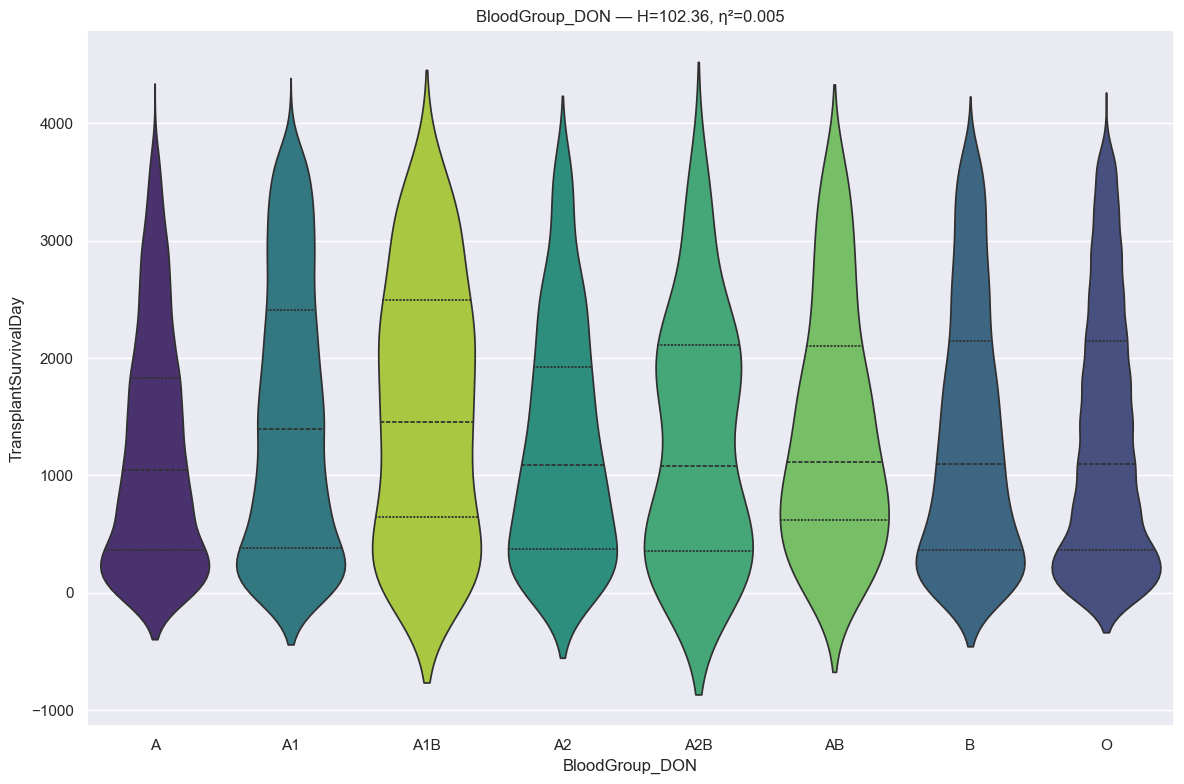

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * A                                                 :   3040 records
 * A1                                                :   3539 records
 * A1B                                               :    194 records
 * A2                                                :    606 records
 * A2B                                               :     74 records
 * AB                                                :    242 records
 * B                                                 :   2294 records
 * O                                                 :  10018 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 102.3577 | P-value: 3.513755e-19 | Effect η²: 0.0048
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0018 | r_threshold: 0.10)
--------------------------------------------------------------------------------
A            vs A1           | p=

In [62]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

##### **Note:** Not going to collapse blood types since it is a very important part of transplant

#### Heavy Alcohol Use

In [63]:
# info
feature = u.get_feature_info(df, 'HeavyAlcoholUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top   freq
HeavyAlcoholUse_DON  20007      4  No  15661

:::: NaN Count:
HeavyAlcoholUse_DON    0 



{'HeavyAlcoholUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

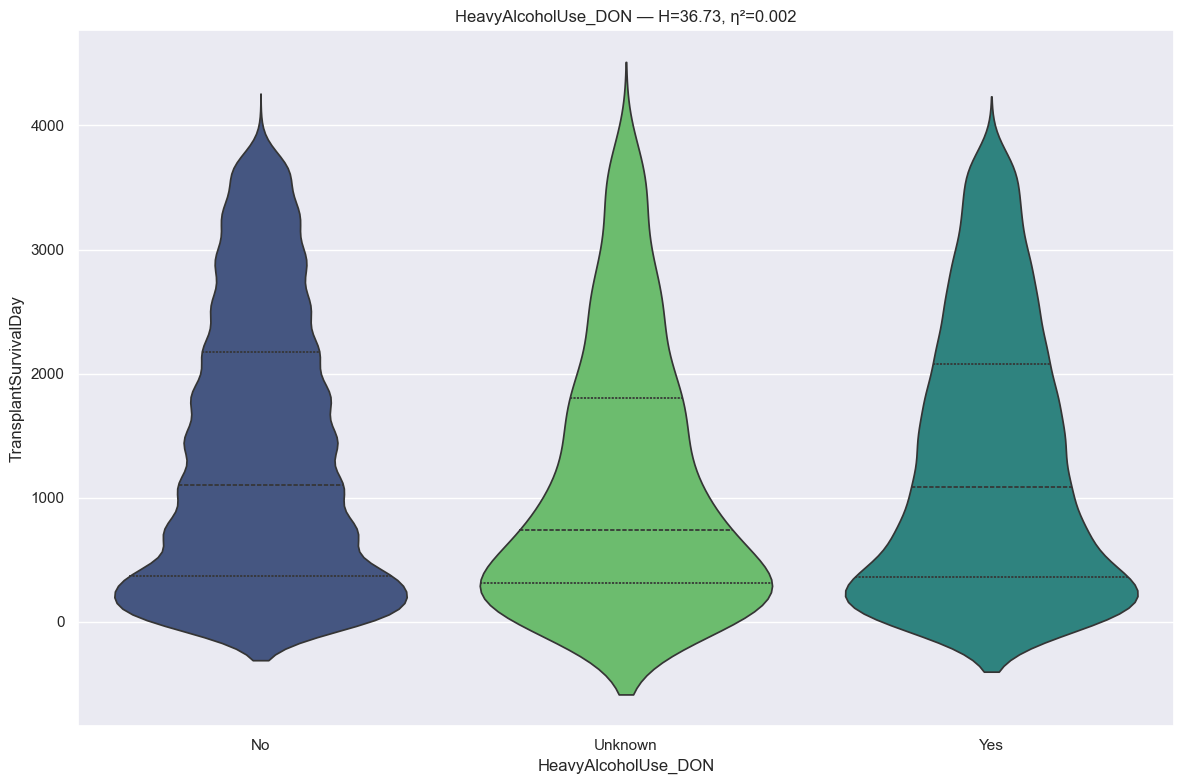

RANKING REPORT: HeavyAlcoholUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  15661 records
 * Unknown                                           :    513 records
 * Yes                                               :   3823 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     10 records
--------------------------------------------------------------------------------
Kruskal H: 36.7291 | P-value: 1.057741e-08 | Effect η²: 0.0017
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=4.9971e-07 | thr=0.0167 | r=-0.130 | *Sig*
No           vs Yes          | p=1.6486e-04 | thr=0.0167 | r=-0.039 | *Sig*
Unknown      vs Yes          | p=7.5035e-04 | thr=0.0167 | r= 0.092 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::

In [64]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [65]:
# Collapse Missing & Unknown into Other
# mapping: collapse Missing & Unknown: small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

HeavyAlcoholUse_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                 No         1346.692868                1102.0                 3947.0                    0.0         15661
                Yes         1273.254512                1088.0                 3832.0                    0.0          3823
              Other         1119.076482                 739.0                 3926.0                    0.0           523


#### Gender

In [66]:
# add to remove list
remove_cols.extend(['Gender_DON'])

#### Residency State

In [67]:
# info
feature = u.get_feature_info(df, 'ResidencyState', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top  freq
ResidencyState_DON  20007     54  CA  2183

:::: NaN Count:
ResidencyState_DON    0 



{'ResidencyState_DON': CategoricalDtype(categories=['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE',
                   'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA',
                   'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND',
                   'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA',
                   'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA',
                   'WI', 'WV', 'WY', 'XX', 'ZZ'],
 , ordered=False, categories_dtype=object)}

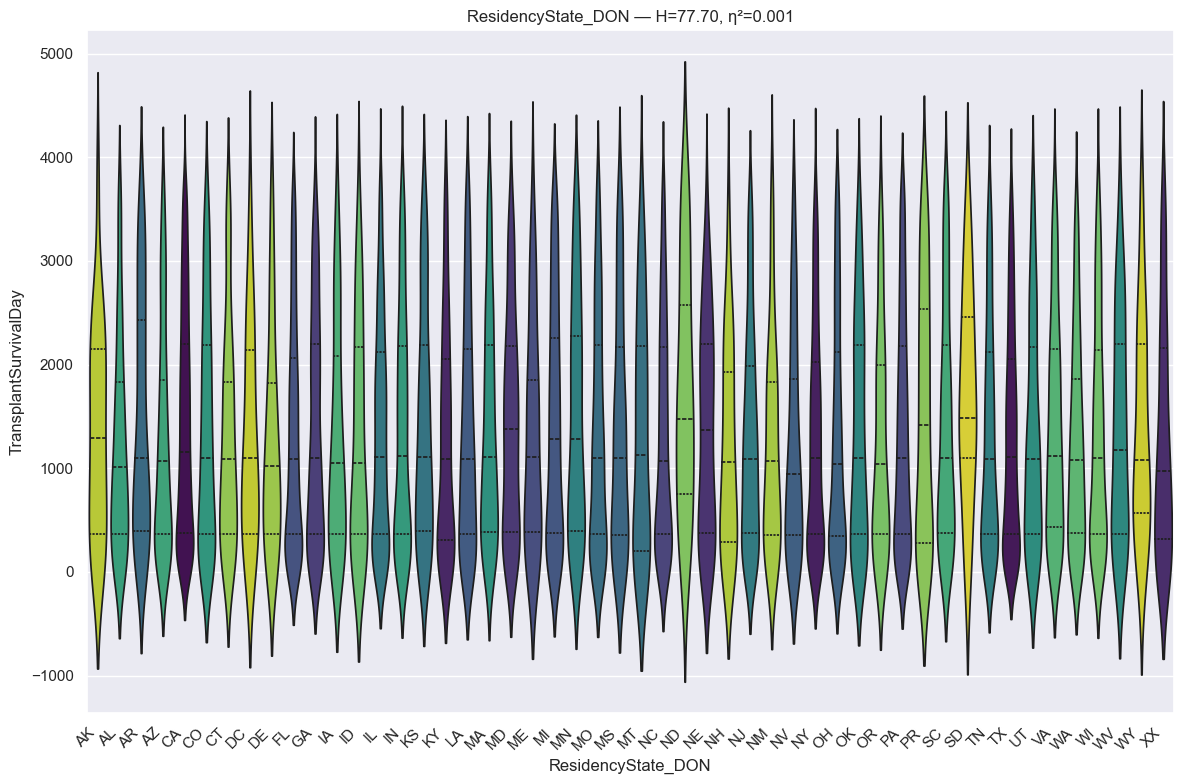

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AK                                                :     47 records
 * AL                                                :    282 records
 * AR                                                :    202 records
 * AZ                                                :    488 records
 * CA                                                :   2183 records
 * CO                                                :    336 records
 * CT                                                :    193 records
 * DC                                                :     37 records
 * DE                                                :     99 records
 * FL                                                :   1276 records
 * GA                                                :    630 records
 * IA                                                :    154 records
 * ID                                                :     94 records
 * IL                    

In [68]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [69]:
# mapping
mapping = { 'RI': 'Other-1200s',
 'VT': 'Other-1000s',
 'ZZ': 'Other-1900s',
 'HI': 'Other-400s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

ResidencyState_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                CA         1409.588181                1160.0                 3947.0                    0.0          2183
                TX         1290.740860                1106.5                 3821.0                    0.0          1860
                FL         1285.742163                1084.0                 3732.0                    0.0          1276
                PA         1339.819388                1095.5                 3689.0                    0.0           980
                NY         1287.484925                1096.0                 3928.0                    1.0           796
                IL         1312.073454                1105.0                 3926.0                    1.0           776
                OH         1266.519284                1038.5                 3678.0                    0.0           726
                NC         1284.

In [70]:
# mapping
mapping = { 'ME': 'Other-1200s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

ResidencyState_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                CA         1409.588181                1160.0                 3947.0                    0.0          2183
                TX         1290.740860                1106.5                 3821.0                    0.0          1860
                FL         1285.742163                1084.0                 3732.0                    0.0          1276
                PA         1339.819388                1095.5                 3689.0                    0.0           980
                NY         1287.484925                1096.0                 3928.0                    1.0           796
                IL         1312.073454                1105.0                 3926.0                    1.0           776
                OH         1266.519284                1038.5                 3678.0                    0.0           726
                NC         1284.

In [71]:
# values for NominalSurvivalRanker
class_values = {"method": "bonferroni", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AK                                                :     47 records
 * AL                                                :    282 records
 * AR                                                :    202 records
 * AZ                                                :    488 records
 * CA                                                :   2183 records
 * CO                                                :    336 records
 * CT                                                :    193 records
 * DC                                                :     37 records
 * DE                                                :     99 records
 * FL                                                :   1276 records
 * GA                                                :    630 records
 * IA                                                :    154 records
 * ID                                                :     94 records
 * IL                    

In [72]:
# mapping
mapping = {'AK': 'Group_1',
 'AL': 'Group_1',
 'AR': 'Group_1',
 'AZ': 'Group_1',
 'CA': 'Group_1',
 'CO': 'Group_1',
 'CT': 'Group_1',
 'DC': 'Group_1',
 'DE': 'Group_1',
 'FL': 'Group_1',
 'GA': 'Group_1',
 'IA': 'Group_1',
 'ID': 'Group_1',
 'IL': 'Group_1',
 'IN': 'Group_1',
 'KS': 'Group_1',
 'KY': 'Group_1',
 'LA': 'Group_1',
 'MA': 'Group_1',
 'MD': 'Group_1',
 'MI': 'Group_1',
 'MN': 'Group_1',
 'MO': 'Group_1',
 'MS': 'Group_1',
 'MT': 'Group_1',
 'NC': 'Group_1',
 'NE': 'Group_1',
 'NH': 'Group_1',
 'NJ': 'Group_1',
 'NM': 'Group_1',
 'NV': 'Group_1',
 'NY': 'Group_1',
 'OH': 'Group_1',
 'OK': 'Group_1',
 'OR': 'Group_1',
 'Other-1200s': 'Group_1',
 'PA': 'Group_1',
 'PR': 'Group_1',
 'SC': 'Group_1',
 'TN': 'Group_1',
 'TX': 'Group_1',
 'UT': 'Group_1',
 'VA': 'Group_1',
 'WA': 'Group_1',
 'WI': 'Group_1',
 'WV': 'Group_1',
 'WY': 'Group_1',
 'XX': 'Group_1',
 'ND': 'Group_2',
 'SD': 'Group_2'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

ResidencyState_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           Group_1         1325.350933                1096.0                 3947.0                    0.0         19887
           Group_2         1710.746835                1478.0                 3845.0                    3.0            79
       Other-1000s         1097.391304                 736.0                 3630.0                   10.0            23
       Other-1900s         1927.833333                2041.5                 3520.0                   14.0            12
        Other-400s          451.500000                 500.5                  735.0                   44.0             6


#### Antibody HEP C
* Research shows that getting a kidney from a hepatitis C-positive donor does not lower a patient's or the kidney's survival for up to ten years after transplant. However, there may still be some risk, especially if the donor's virus type differs from the patients.'

In [73]:
# info
feature = u.get_feature_info(df, 'Antibody_HEP_C', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top   freq
Antibody_HEP_C_DON  20007      5  Negative  19047

:::: NaN Count:
Antibody_HEP_C_DON    0 



{'Antibody_HEP_C_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive'],
 , ordered=False, categories_dtype=object)}

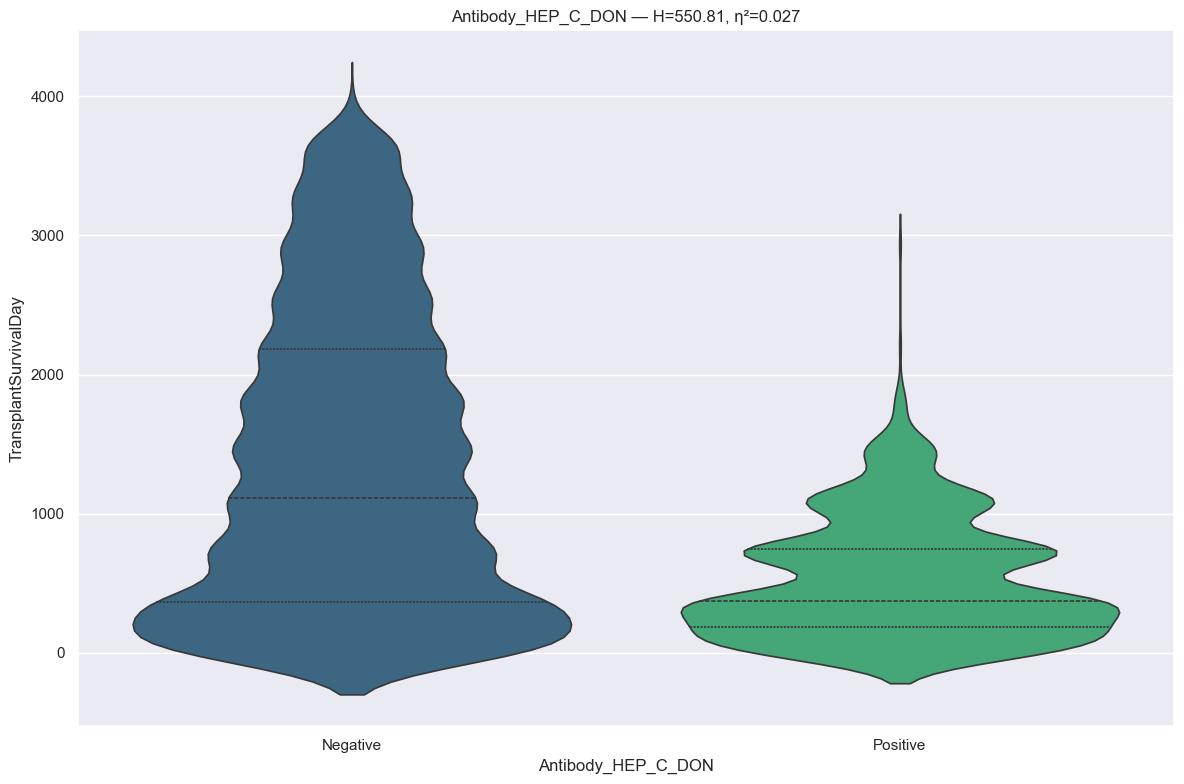

RANKING REPORT: Antibody_HEP_C_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :  19047 records
 * Positive                                          :    956 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :      1 records
 * Missing                                           :      2 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 550.8052 | P-value: 8.410624e-122 | Effect η²: 0.0275
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=8.4112e-122 | thr=0.0500 | r=-0.449 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 

In [74]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [75]:
# mapping (small sample size)
mapping = {'Missing': 'Other',
           'Indeterminate': 'Other',
           'Pending': 'Other'
          }
# map the change
df[feature[0]] = df[feature[0]].map(mapping).fillna(df[feature[0]])
# sanity check
ranker.mean_survival_by_category(df, feature[0])

Antibody_HEP_C_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
          Negative         1366.612957                1113.0                 3947.0                    0.0         19047
          Positive          533.234310                 373.0                 2936.0                    0.0           956
             Other          959.250000                 769.0                 2231.0                   68.0             4


#### Non Heart Beating

In [76]:
# info
feature = u.get_feature_info(df, 'NonHeartBeating', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top   freq
NonHeartBeating_DON  20007      3  No  19766

:::: NaN Count:
NonHeartBeating_DON    0 



{'NonHeartBeating_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

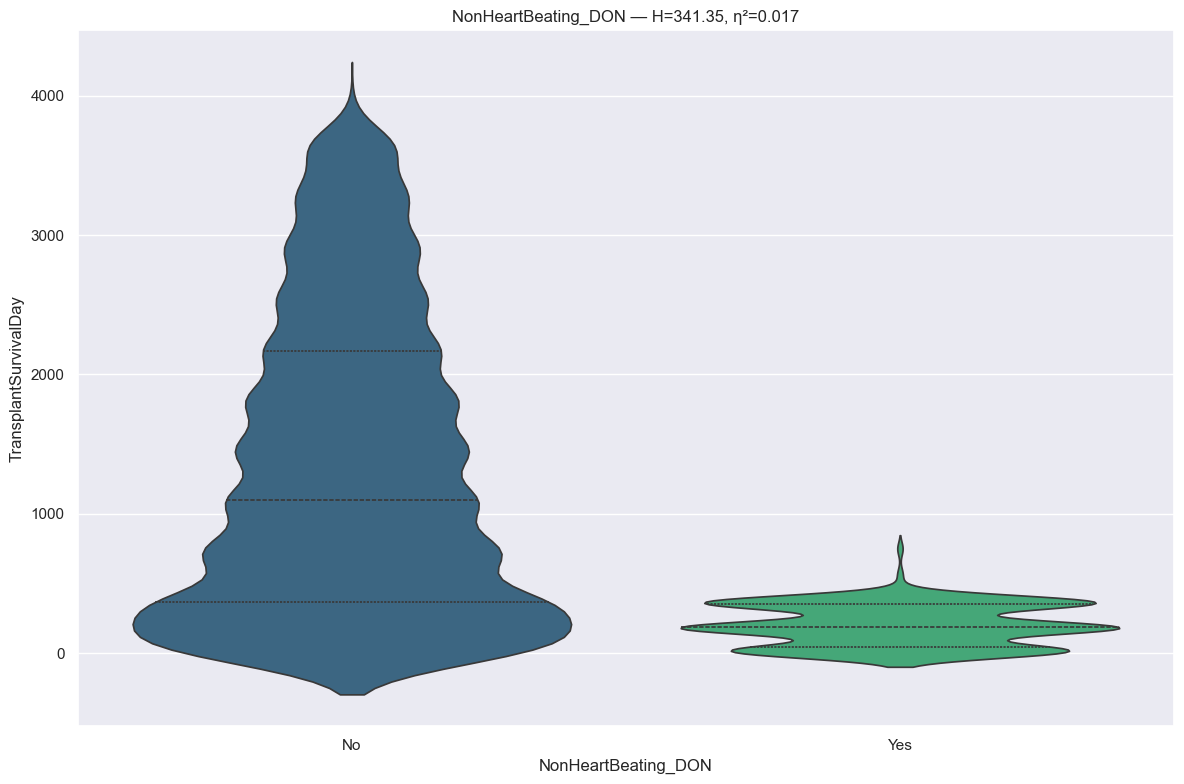

RANKING REPORT: NonHeartBeating_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19766 records
 * Yes                                               :    237 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 341.3466 | P-value: 3.247908e-76 | Effect η²: 0.0170
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.2482e-76 | thr=0.0500 | r=-0.697 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Missing

NonHeartBeating_DON  mean_survival_days  median

In [77]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Anti Hypertensive

In [78]:
# info
feature = u.get_feature_info(df, 'AntiHypertensive_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique top   freq
AntiHypertensive_DON  20007      4  No  13411

:::: NaN Count:
AntiHypertensive_DON    0 



{'AntiHypertensive_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

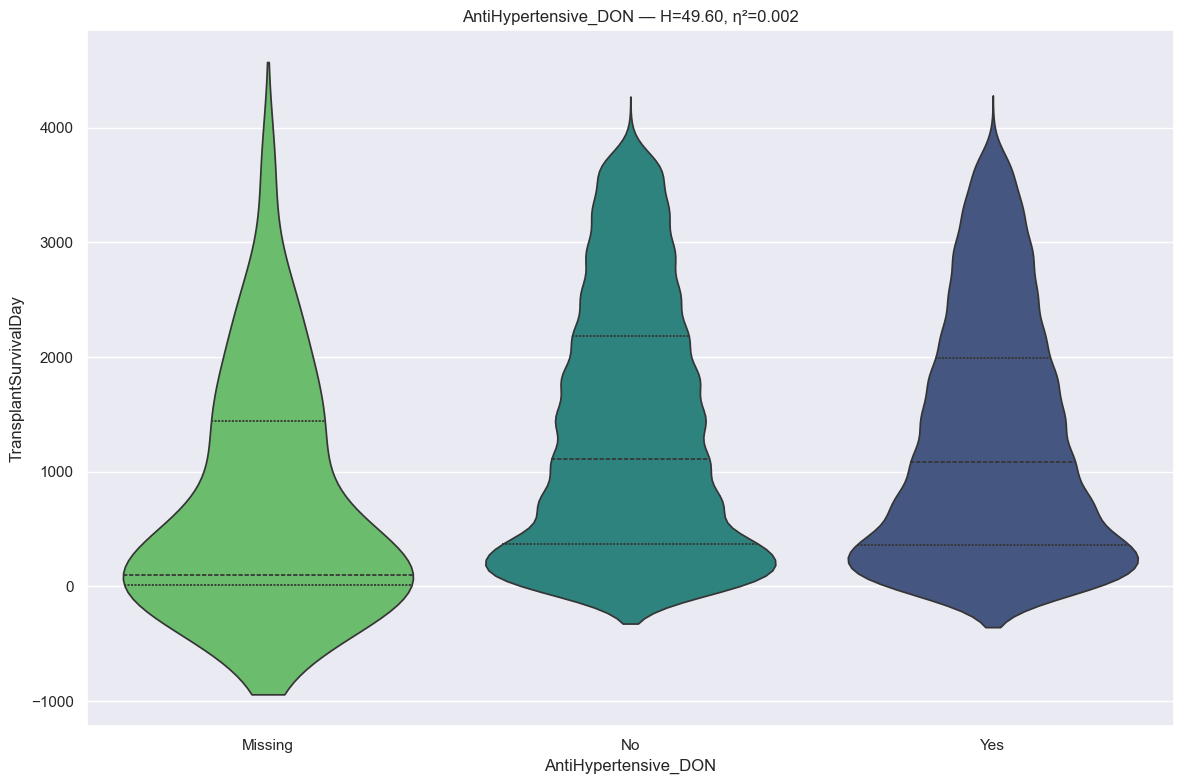

RANKING REPORT: AntiHypertensive_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  13411 records
 * Yes                                               :   6551 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 49.5977 | P-value: 1.698209e-11 | Effect η²: 0.0024
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.2798e-08 | thr=0.0167 | r=-0.048 | *Sig*
Missing      vs No           | p=5.7943e-06 | thr=0.0167 | r= 0.425 | *Sig*
Missing      vs Yes          | p=2.6309e-05 | thr=0.0167 | r= 0.395 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::::

In [79]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [80]:
# mapping(collapse: sample sample size)
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = df[feature[0]].map(mapping).fillna(df[feature[0]])
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntiHypertensive_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                  No         1361.092312                1107.0                 3947.0                    0.0         13411
                 Yes         1259.841704                1084.0                 3926.0                    0.0          6551
               Other          814.533333                 390.0                 3631.0                    0.0            45


#### Blood Infection Source

In [81]:
# info
feature = u.get_feature_info(df, 'BloodInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                          count unique top   freq
BloodInfectionSource_DON  20007      3  No  18052

:::: NaN Count:
BloodInfectionSource_DON    0 



{'BloodInfectionSource_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

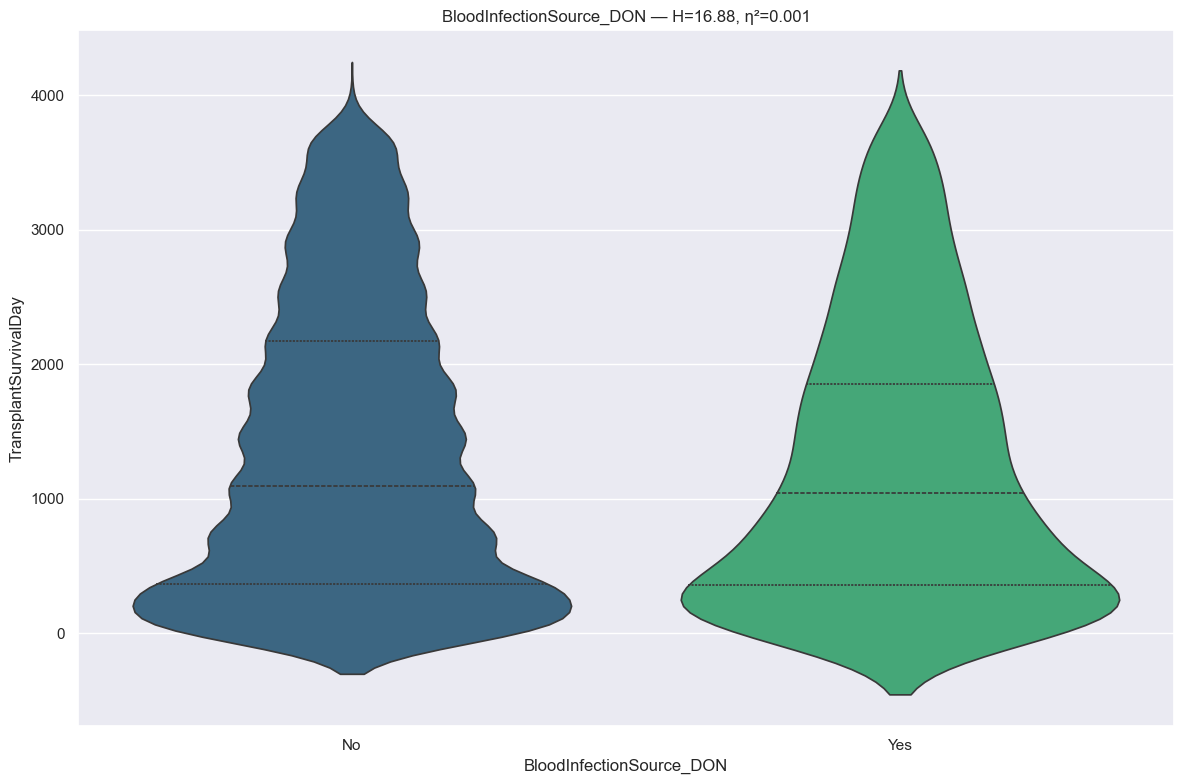

RANKING REPORT: BloodInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  18052 records
 * Yes                                               :   1953 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 16.8812 | P-value: 3.979412e-05 | Effect η²: 0.0008
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.9794e-05 | thr=0.0500 | r=-0.057 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Missing

BloodInfectionSource_DON  mean_survival_day

In [82]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [83]:
# mapping(collapse: sample sample size)
mapping = {'No': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = df[feature[0]].map(mapping).fillna(df[feature[0]])
# sanity check
ranker.mean_survival_by_category(df, feature[0])

BloodInfectionSource_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                   Other         1337.305085                1099.0                 3947.0                    0.0         18054
                     Yes         1228.766001                1040.0                 3732.0                    0.0          1953


#### OtherInfectionSource_DON

In [84]:
# info
feature = u.get_feature_info(df, 'OtherInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                          count unique top   freq
OtherInfectionSource_DON  20007      3  No  13826

:::: NaN Count:
OtherInfectionSource_DON    0 



{'OtherInfectionSource_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

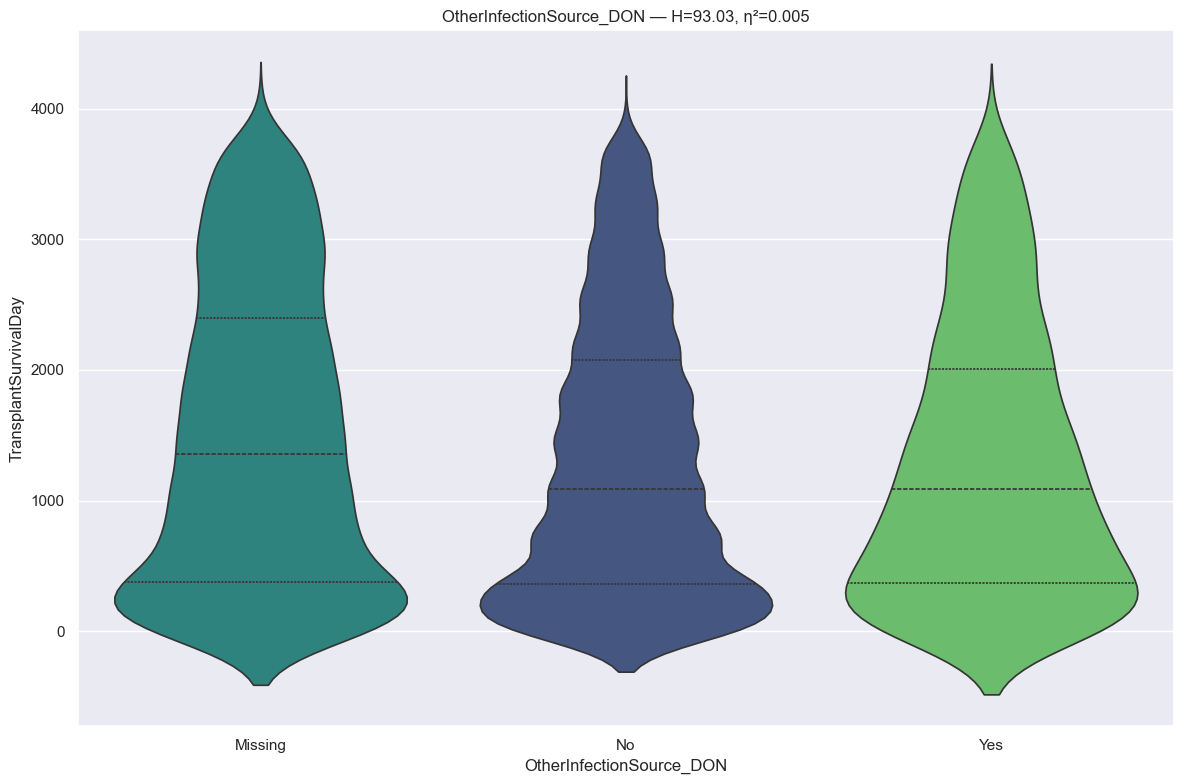

RANKING REPORT: OtherInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   4763 records
 * No                                                :  13826 records
 * Yes                                               :   1418 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 93.0341 | P-value: 6.279175e-21 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=3.4071e-21 | thr=0.0167 | r=-0.092 | *Sig*
Missing      vs Yes          | p=1.4604e-08 | thr=0.0167 | r=-0.099 | *Sig*
No           vs Yes          | p=6.5624e-01 | thr=0.0167 | r=-0.007 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> G

In [85]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Diuretics

In [86]:
# info
feature = u.get_feature_info(df, 'Diuretics', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique  top   freq
Diuretics_DON  20007      4  Yes  13904

:::: NaN Count:
Diuretics_DON    0 



{'Diuretics_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

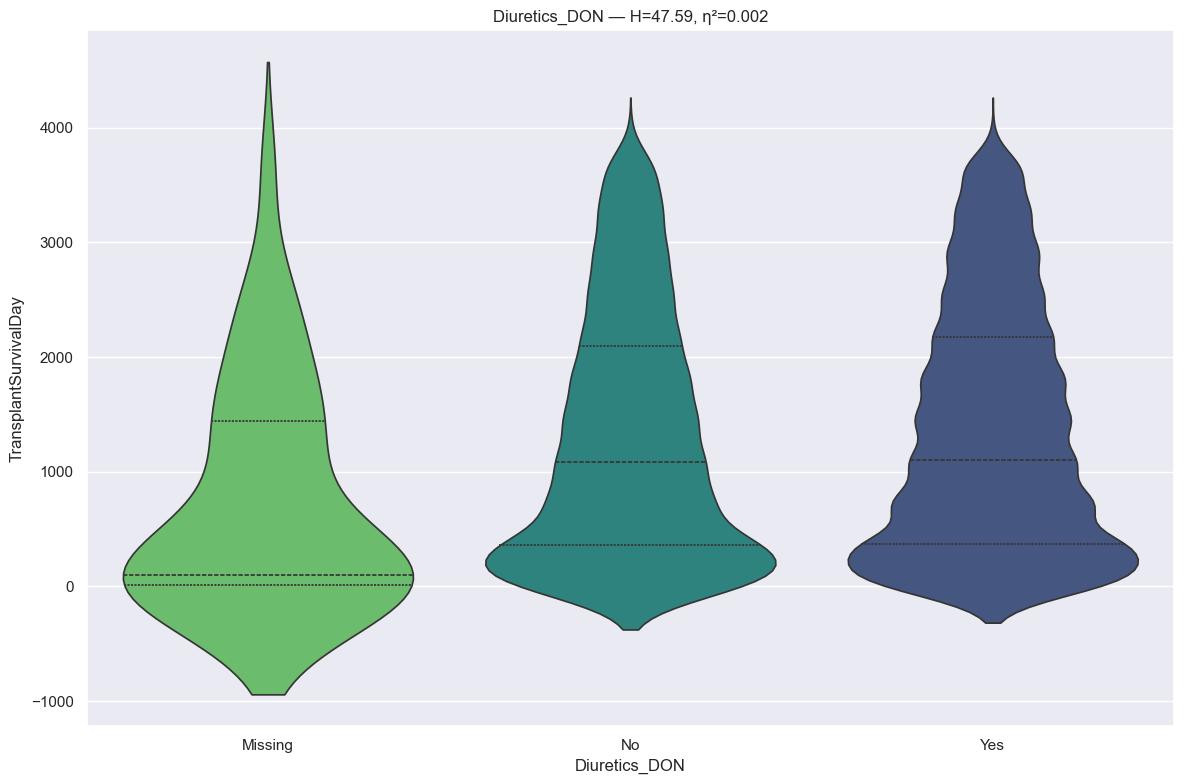

RANKING REPORT: Diuretics_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   6061 records
 * Yes                                               :  13904 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 47.5900 | P-value: 4.633986e-11 | Effect η²: 0.0023
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.2068e-07 | thr=0.0167 | r= 0.047 | *Sig*
Missing      vs Yes          | p=5.9832e-06 | thr=0.0167 | r= 0.425 | *Sig*
Missing      vs No           | p=2.7832e-05 | thr=0.0167 | r= 0.394 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::

In [87]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [88]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

Diuretics_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
          Yes         1350.236982                1104.0                 3947.0                    0.0         13904
           No         1276.136281                1085.0                 3887.0                    0.0          6061
        Other          836.404762                 287.0                 3672.0                    0.0            42


#### Steroids Use

In [89]:
# info
feature = u.get_feature_info(df, 'SteroidsUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique  top   freq
SteroidsUse_DON  20007      4  Yes  14208

:::: NaN Count:
SteroidsUse_DON    0 



{'SteroidsUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

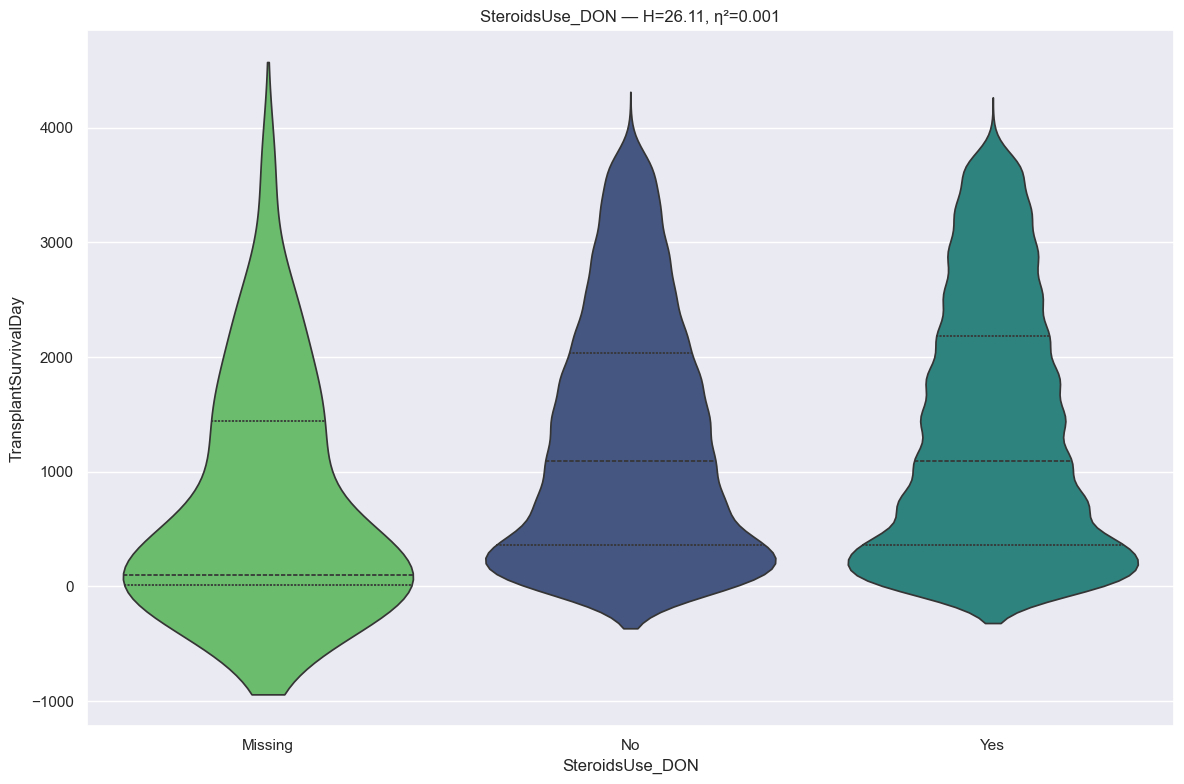

RANKING REPORT: SteroidsUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   5747 records
 * Yes                                               :  14208 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 26.1129 | P-value: 2.136296e-06 | Effect η²: 0.0012
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=7.8928e-06 | thr=0.0167 | r= 0.419 | *Sig*
Missing      vs No           | p=1.5739e-05 | thr=0.0167 | r= 0.406 | *Sig*
No           vs Yes          | p=1.0751e-02 | thr=0.0167 | r= 0.023 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::

In [90]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [91]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

SteroidsUse_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
            Yes         1344.670045                1098.0                 3945.0                    0.0         14208
             No         1285.896816                1095.0                 3947.0                    0.0          5747
          Other          930.096154                 586.0                 3631.0                    0.0            52


#### Triiodothyronine T3

In [92]:
# info
feature = u.get_feature_info(df, 'TriiodothyronineT3', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique top   freq
TriiodothyronineT3_DON  20007      4  No  19879

:::: NaN Count:
TriiodothyronineT3_DON    0 



{'TriiodothyronineT3_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

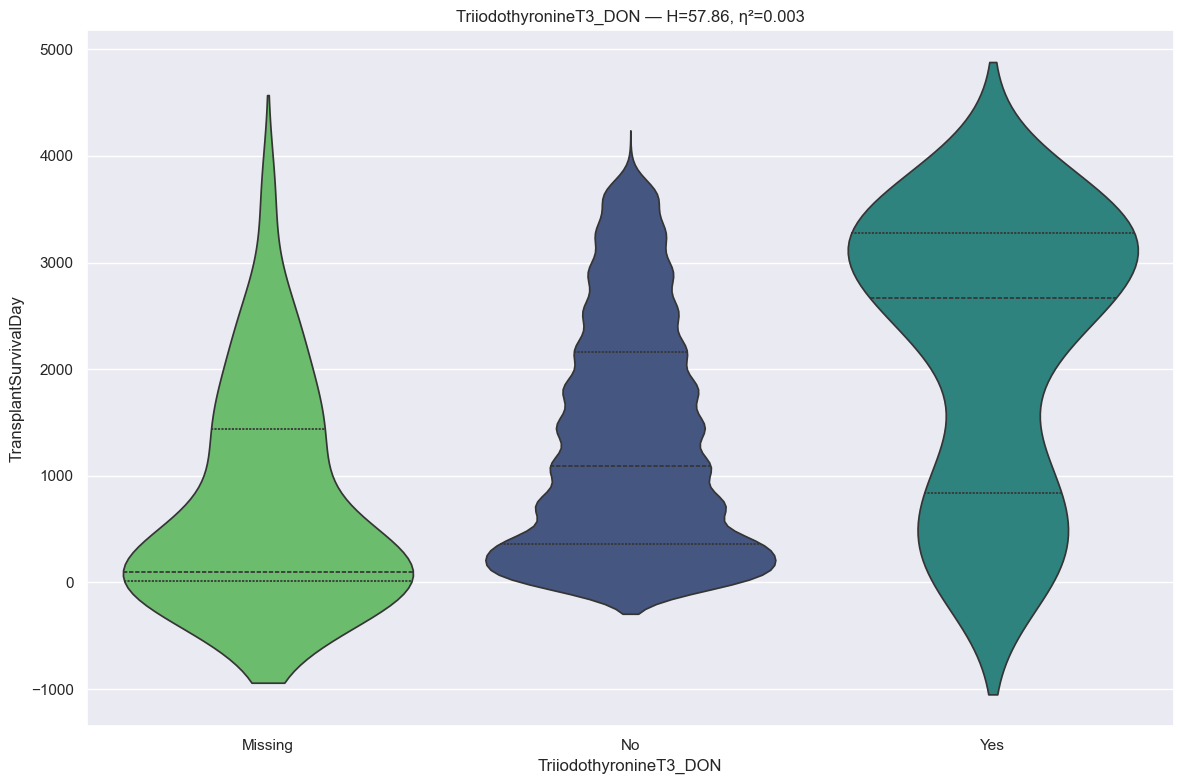

RANKING REPORT: TriiodothyronineT3_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19879 records
 * Yes                                               :     85 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      5 records
--------------------------------------------------------------------------------
Kruskal H: 57.8649 | P-value: 2.721383e-13 | Effect η²: 0.0028
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.0448e-10 | thr=0.0167 | r= 0.388 | *Sig*
Missing      vs Yes          | p=1.3734e-08 | thr=0.0167 | r= 0.642 | *Sig*
Missing      vs No           | p=9.9242e-06 | thr=0.0167 | r= 0.414 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::

In [93]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [94]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

TriiodothyronineT3_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                    No         1324.080738                1096.0                 3947.0                    0.0         19879
                   Yes         2195.600000                2672.0                 3832.0                    0.0            85
                 Other          824.627907                 184.0                 3631.0                    0.0            43


#### Thyroxine T4

In [95]:
# info
feature = u.get_feature_info(df, 'ThyroxineT4', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique  top   freq
ThyroxineT4_DON  20007      4  Yes  13263

:::: NaN Count:
ThyroxineT4_DON    0 



{'ThyroxineT4_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

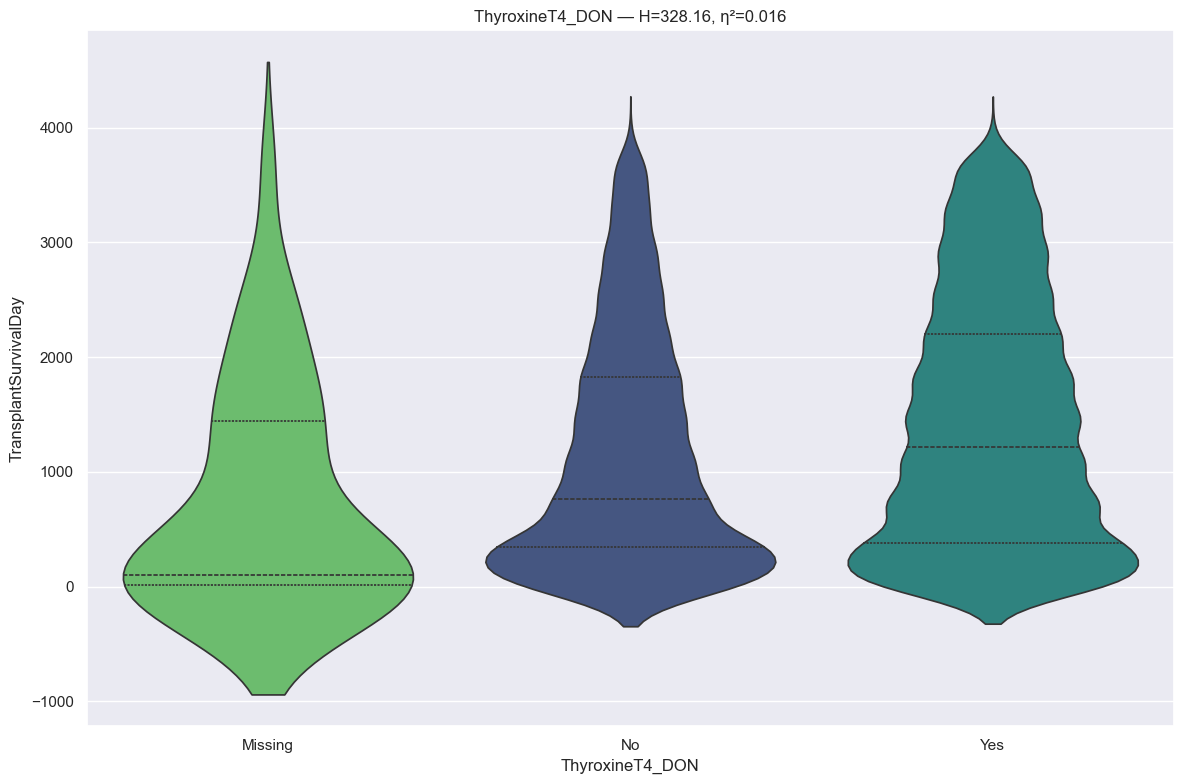

RANKING REPORT: ThyroxineT4_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   6703 records
 * Yes                                               :  13263 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 328.1611 | P-value: 5.504492e-72 | Effect η²: 0.0163
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.6690e-69 | thr=0.0167 | r= 0.152 | *Sig*
Missing      vs Yes          | p=1.8005e-06 | thr=0.0167 | r= 0.448 | *Sig*
Missing      vs No           | p=1.8807e-04 | thr=0.0167 | r= 0.351 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::::::::

In [96]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [97]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

ThyroxineT4_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
            Yes         1421.726985                1214.0                 3947.0                    0.0         13263
             No         1142.193645                 767.0                 3926.0                    0.0          6703
          Other          756.024390                 184.0                 3631.0                    0.0            41


#### Pulmonary Infection

In [98]:
# info
feature = u.get_feature_info(df, 'PulmonaryInfection', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique  top   freq
PulmonaryInfection_DON  20007      3  Yes  14217

:::: NaN Count:
PulmonaryInfection_DON    0 



{'PulmonaryInfection_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

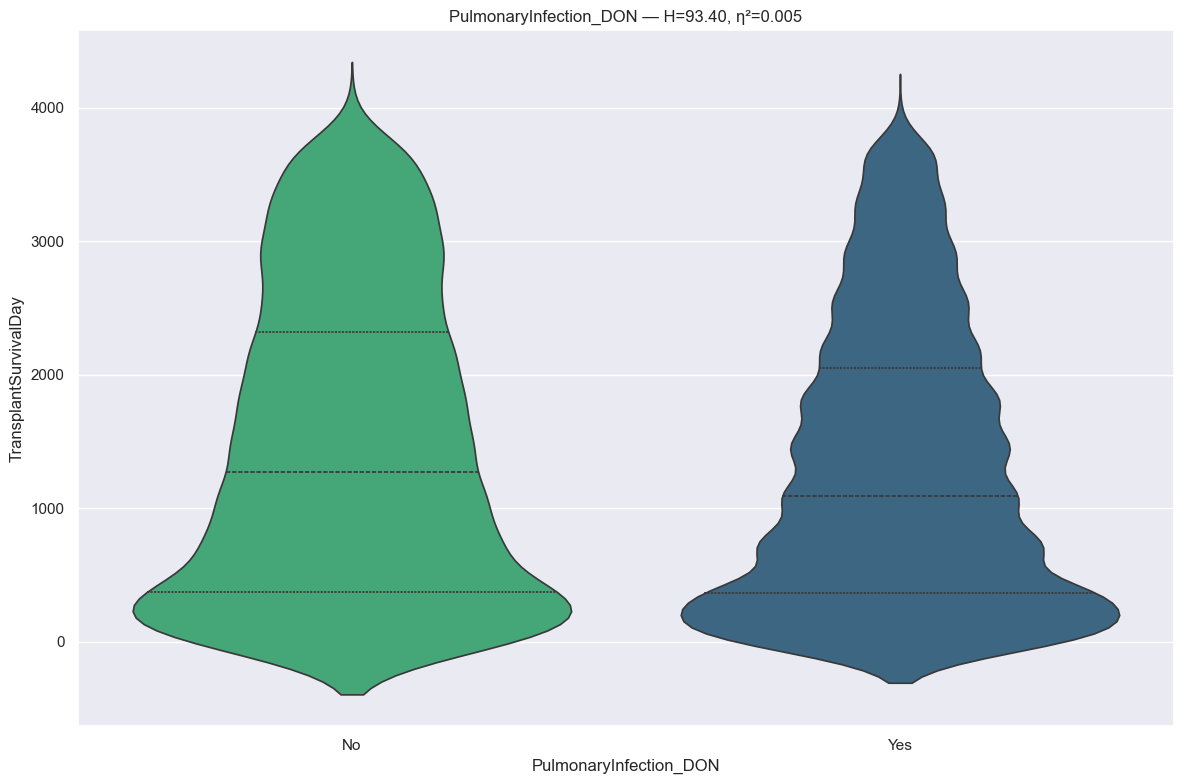

RANKING REPORT: PulmonaryInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5788 records
 * Yes                                               :  14217 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 93.4044 | P-value: 4.263021e-22 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.2631e-22 | thr=0.0500 | r=-0.087 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Missing

PulmonaryInfection_DON  mean_survival_days  m

In [99]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [100]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'No': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

PulmonaryInfection_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                   Yes         1275.535837                1089.0                 3945.0                    0.0         14217
                 Other         1452.364940                1272.5                 3947.0                    0.0          5790


#### Urine Infection

In [101]:
# info
feature = u.get_feature_info(df, 'UrineInfection', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique top   freq
UrineInfection_DON  20007      3  No  18800

:::: NaN Count:
UrineInfection_DON    0 



{'UrineInfection_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

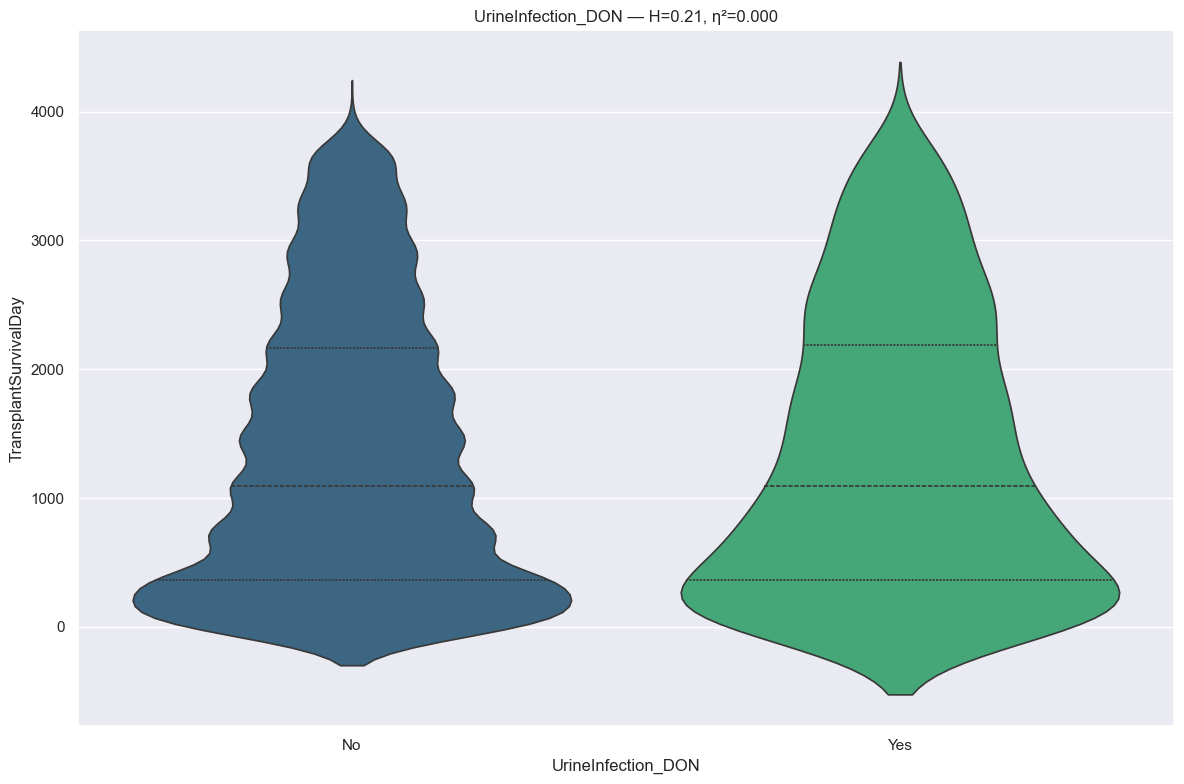

RANKING REPORT: UrineInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  18800 records
 * Yes                                               :   1205 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 0.2146 | P-value: 6.431920e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.4319e-01 | thr=0.0500 | r=-0.008 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (2 categories)
  - No
  - Yes

>>> Other (1 categories)
  - Missing

UrineInfection_DON  mean_survival_days  median_survival_days  maximum_surviv

In [102]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [103]:
# mapping: collapse Missing & No into Other: underpowered, small sample size
mapping = {'No': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

UrineInfection_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             Other         1326.970216                1097.0                 3947.0                    0.0         18802
               Yes         1322.648963                1091.0                 3861.0                    0.0          1205


#### Vasodilators

In [104]:
# info
feature = u.get_feature_info(df, 'Vasodilators', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                  count unique top   freq
Vasodilators_DON  20007      4  No  16687

:::: NaN Count:
Vasodilators_DON    0 



{'Vasodilators_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

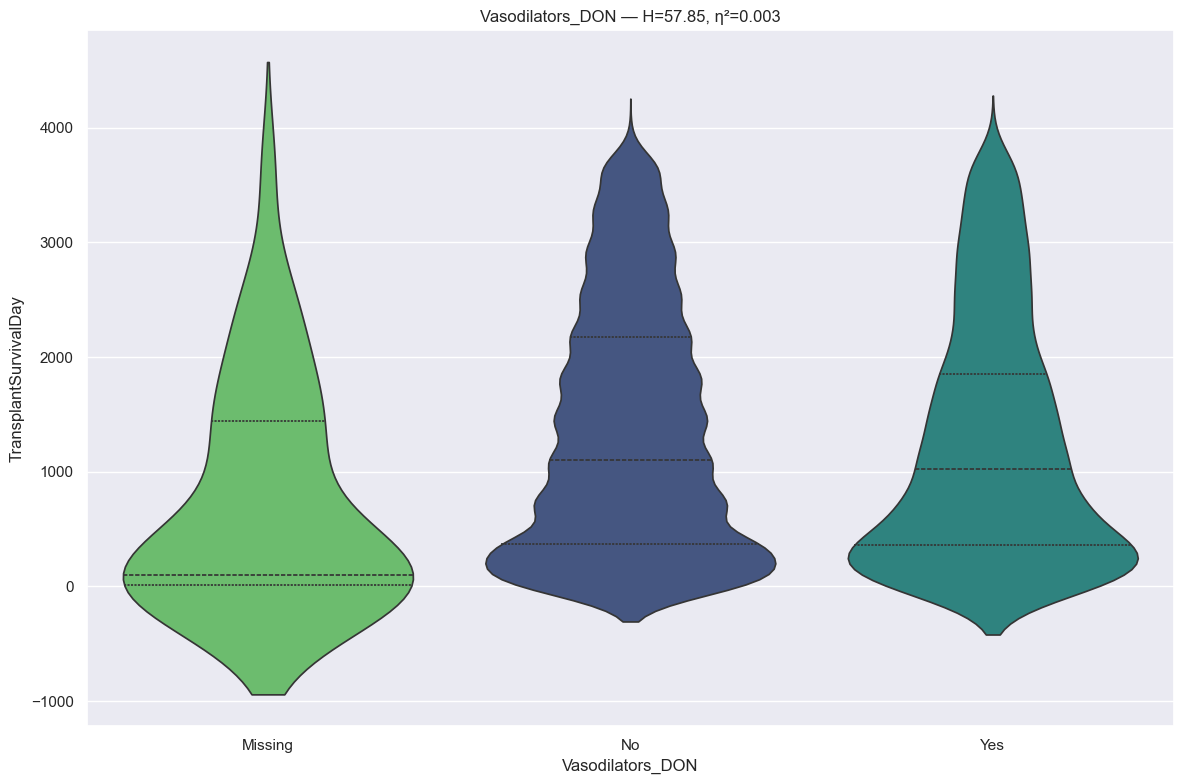

RANKING REPORT: Vasodilators_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  16687 records
 * Yes                                               :   3276 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      6 records
--------------------------------------------------------------------------------
Kruskal H: 57.8468 | P-value: 2.746140e-13 | Effect η²: 0.0028
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.1233e-10 | thr=0.0167 | r=-0.068 | *Sig*
Missing      vs No           | p=6.7117e-06 | thr=0.0167 | r= 0.422 | *Sig*
Missing      vs Yes          | p=5.5213e-05 | thr=0.0167 | r= 0.380 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::::::::

In [105]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [106]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

Vasodilators_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
              No         1347.535267                1104.0                 3947.0                    0.0         16687
             Yes         1227.838217                1025.0                 3860.0                    0.0          3276
           Other          790.159091                 446.5                 3631.0                    0.0            44


#### Antibody Result RPR VDRL
* RPR (Rapid Plasma Reagin) and VDRL (Venereal Disease Research Laboratory) are essential non-treponemal screening tests used to detect active syphilis infection in both donors and recipients. A positive (reactive) RPR/VDRL result requires confirmation with a treponemal-specific test (such as TP-PA), as non-treponemal tests can yield false positives due to other conditions, including autoimmune disorders or infections.

In [107]:
# info
feature = u.get_feature_info(df, 'AntibodyResultRPR_VDRL', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                            count unique       top   freq
AntibodyResultRPR_VDRL_DON  20007      4  Negative  19475

:::: NaN Count:
AntibodyResultRPR_VDRL_DON    0 



{'AntibodyResultRPR_VDRL_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Positive'], ordered=False, categories_dtype=object)}

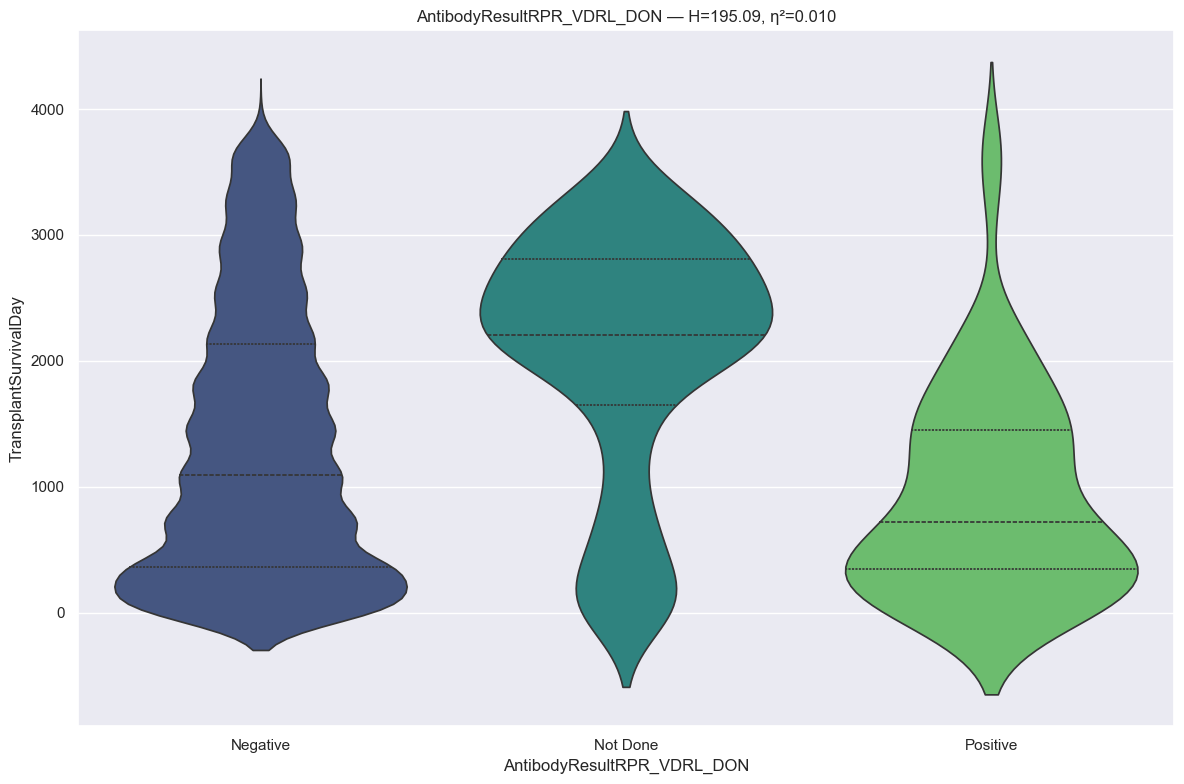

RANKING REPORT: AntibodyResultRPR_VDRL_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :  19475 records
 * Not Done                                          :    408 records
 * Positive                                          :    111 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     13 records
--------------------------------------------------------------------------------
Kruskal H: 195.0874 | P-value: 4.338136e-43 | Effect η²: 0.0097
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=3.1436e-41 | thr=0.0167 | r= 0.388 | *Sig*
Not Done     vs Positive     | p=1.5589e-22 | thr=0.0167 | r=-0.604 | *Sig*
Negative     vs Positive     | p=3.0871e-04 | thr=0.0167 | r=-0.198 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::

In [108]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [109]:
# mapping: collapse Missing & Negative into Other: underpowered, small sample size
mapping = {'Negative': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntibodyResultRPR_VDRL_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                     Other         1313.802648                1095.0                 3947.0                    0.0         19488
                  Not Done         2053.666667                2207.0                 3396.0                    0.0           408
                  Positive          920.756757                 718.0                 3724.0                    2.0           111


#### Infection Clinical

In [110]:
# info
feature = u.get_feature_info(df, 'InfectionClinical', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique  top   freq
InfectionClinical_DON  20007      4  Yes  15244

:::: NaN Count:
InfectionClinical_DON    0 



{'InfectionClinical_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

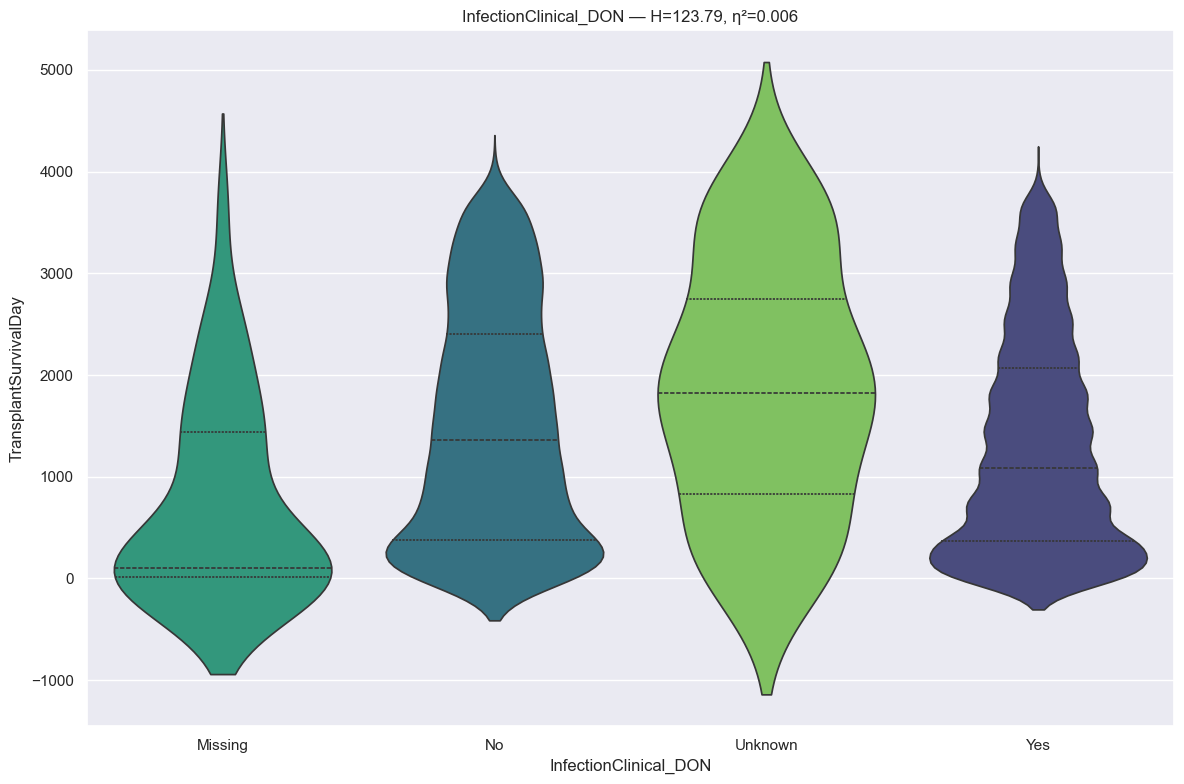

RANKING REPORT: InfectionClinical_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   4683 records
 * Unknown                                           :     42 records
 * Yes                                               :  15244 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 123.7855 | P-value: 1.180480e-26 | Effect η²: 0.0060
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=9.1588e-23 | thr=0.0083 | r=-0.095 | *Sig*
Missing      vs No           | p=9.2602e-07 | thr=0.0083 | r= 0.461 | *Sig*
Missing      vs Unknown      | p=9.5163e-06 | thr=0.0083 | r= 0.576 | *Sig*
Missing      vs Yes          | p=1.9387e-05 | thr=0.0083 | r= 0.401 | *Sig*
Un

In [111]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Cocaine Use

In [112]:
# info
feature = u.get_feature_info(df, 'CocaineUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique      top   freq
CocaineUse_DON      20007      4  Missing  15362
PastCocaineUse_DON  20007      4       No  14941

:::: NaN Count:
CocaineUse_DON        0
PastCocaineUse_DON    0 



{'CocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object),
 'PastCocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

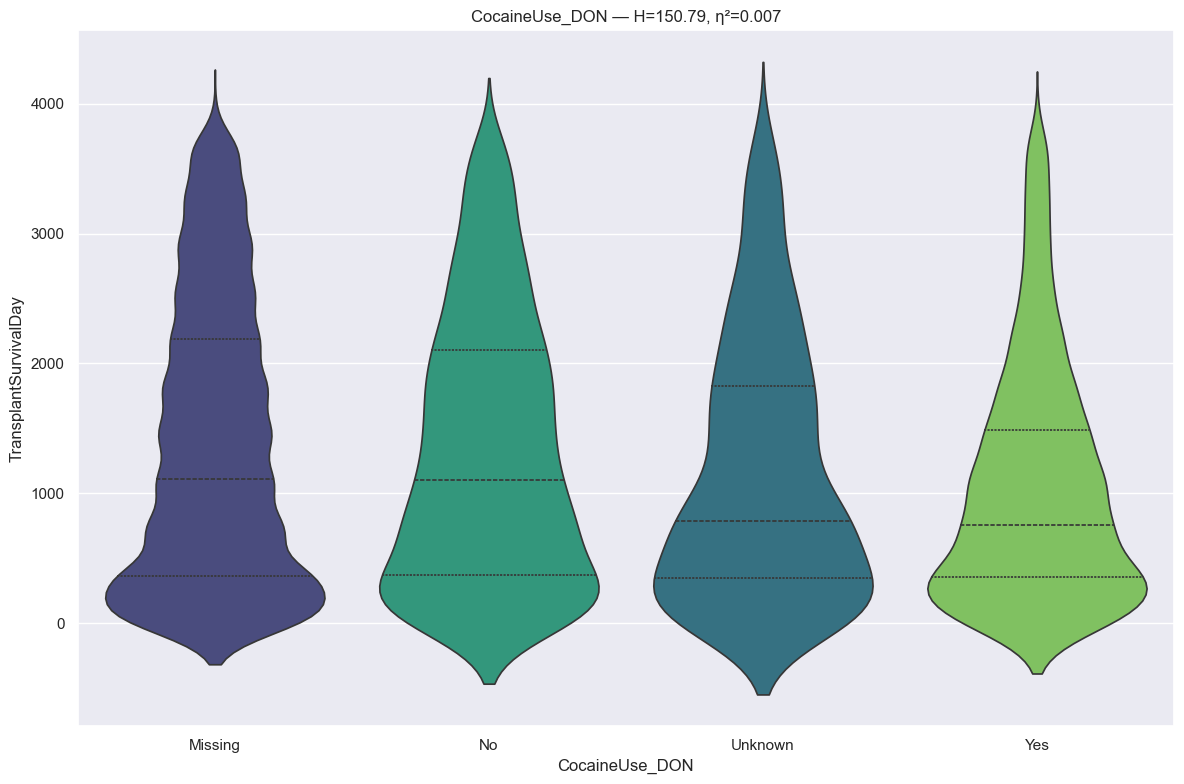

RANKING REPORT: CocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :  15362 records
 * No                                                :   1614 records
 * Unknown                                           :    627 records
 * Yes                                               :   2404 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 150.7909 | P-value: 1.778885e-32 | Effect η²: 0.0074
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=3.3362e-31 | thr=0.0083 | r=-0.147 | *Sig*
No           vs Yes          | p=2.0674e-12 | thr=0.0083 | r=-0.131 | *Sig*
Missing      vs Unknown      | p=3.0617e-06 | thr=0.0083 | r=-0.110 | *Sig*
No           vs Unknown      | p=8.3449e-04 | thr=0.0083 | r=-0.091 | *Sig*
Missing  

In [113]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [114]:
# mapping: collapse Missing & No into Other: survival days very similar
mapping = {'No': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

CocaineUse_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
         Other         1369.242990                1111.0                 3947.0                    0.0         16976
           Yes         1070.467970                 759.0                 3861.0                    0.0          2404
       Unknown         1157.594896                 790.0                 3773.0                    0.0           627


#### Other Drug Use

In [115]:
# info
feature = u.get_feature_info(df, 'OtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique  top   freq
OtherDrugUse_DON      20007      4  Yes   9051
PastOtherDrugUse_DON  20007      4  Yes  11850

:::: NaN Count:
OtherDrugUse_DON        0
PastOtherDrugUse_DON    0 



{'OtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object),
 'PastOtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

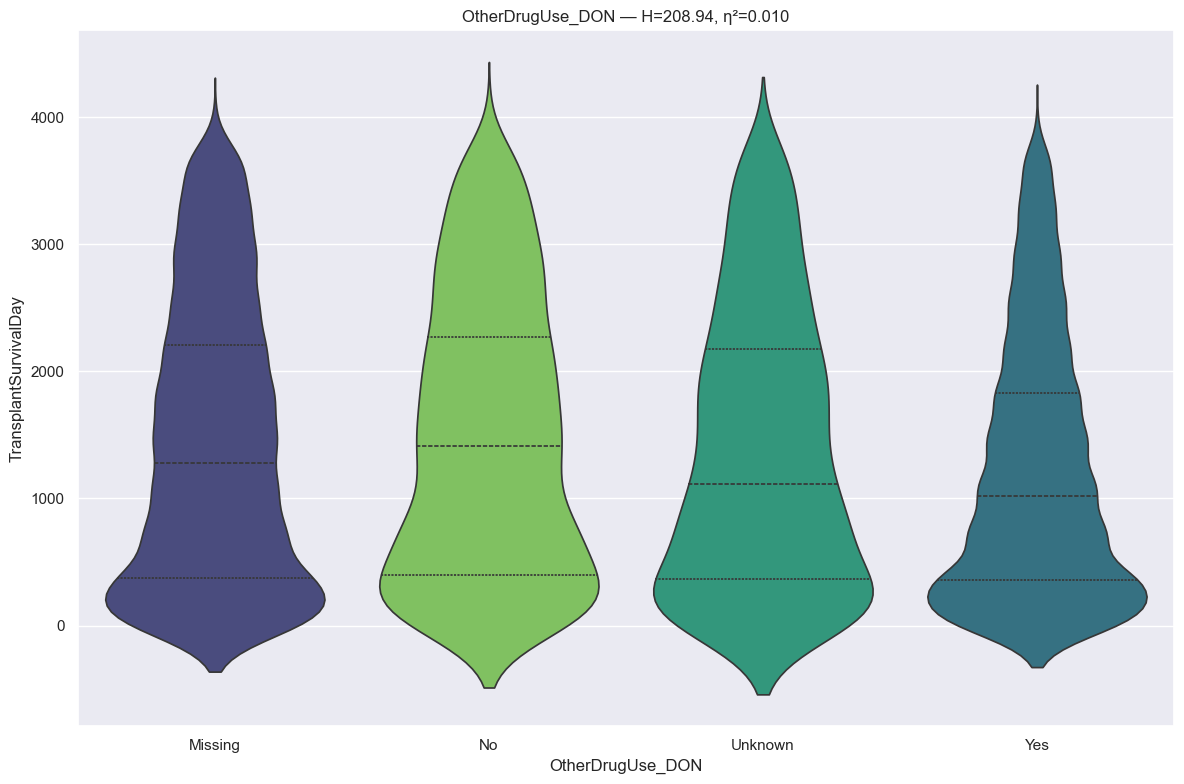

RANKING REPORT: OtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   8157 records
 * No                                                :   1784 records
 * Unknown                                           :   1015 records
 * Yes                                               :   9051 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 208.9391 | P-value: 4.936967e-45 | Effect η²: 0.0103
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=1.9311e-38 | thr=0.0083 | r=-0.114 | *Sig*
No           vs Yes          | p=4.0483e-22 | thr=0.0083 | r=-0.145 | *Sig*
Unknown      vs Yes          | p=7.0097e-06 | thr=0.0083 | r=-0.086 | *Sig*
No           vs Unknown      | p=1.2571e-02 | thr=0.0083 | r=-0.057 | Not Sig
Missi

In [116]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [117]:
# mapping: collapse Missing & No & Unknown into Other: very similar survial days
mapping = {'No': 'Other',
           'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

OtherDrugUse_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           Other         1431.050383                1292.5                 3947.0                    0.0         10956
             Yes         1200.408574                1019.0                 3928.0                    0.0          9051


#### Cancer ExtraCranial

In [118]:
# info
feature = u.get_feature_info(df, 'CancerExtraCranial', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique top   freq
CancerExtraCranial_DON  20007      4  No  19807

:::: NaN Count:
CancerExtraCranial_DON    0 



{'CancerExtraCranial_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

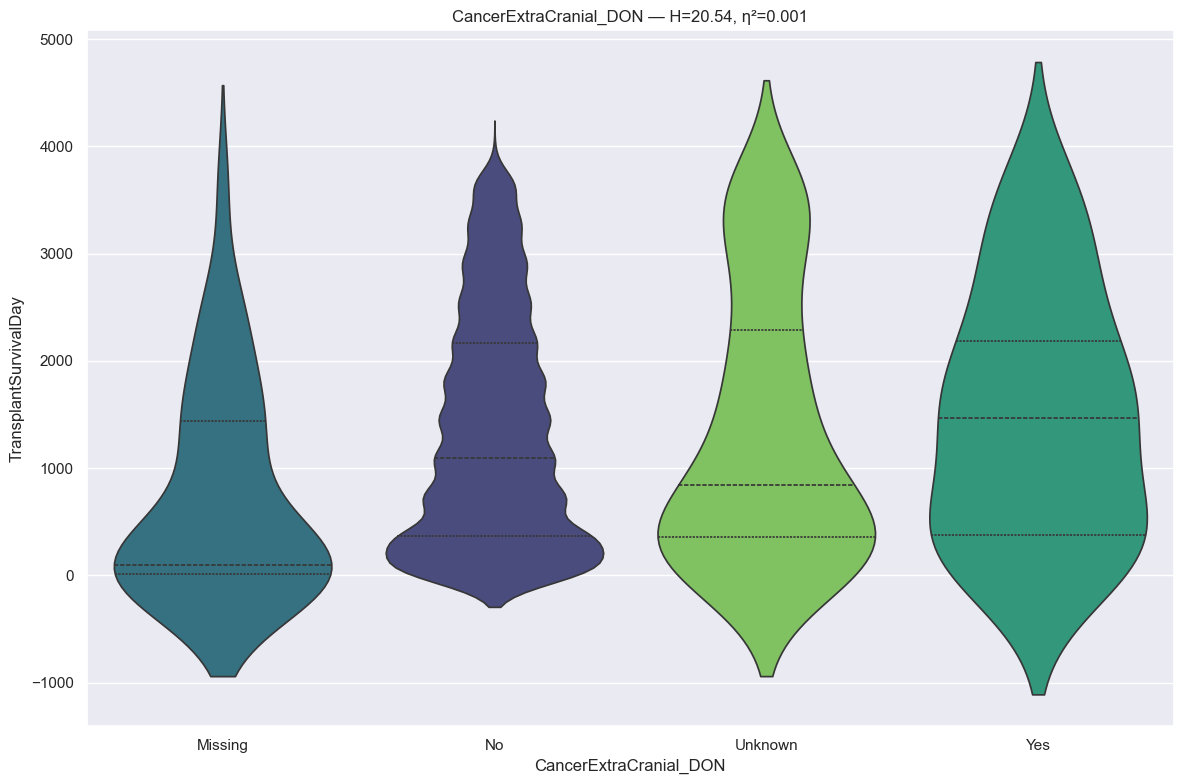

RANKING REPORT: CancerExtraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19807 records
 * Unknown                                           :    127 records
 * Yes                                               :     35 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 20.5365 | P-value: 1.313860e-04 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=9.3417e-06 | thr=0.0083 | r= 0.415 | *Sig*
Missing      vs Yes          | p=4.7293e-04 | thr=0.0083 | r= 0.477 | *Sig*
Missing      vs Unknown      | p=7.6439e-04 | thr=0.0083 | r= 0.361 | *Sig*
Unknown      vs Yes          | p=3.8158e-01 | thr=0.0083 | r= 0.097 | Not Sig


In [119]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [120]:
# mapping: collapse No & Unknown into Other: similar survival days
mapping = {'Unknown': 'Other',
           'No': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

CancerExtraCranial_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                 Other         1327.563911                1097.0                 3947.0                    0.0         19934
               Missing          737.078947                  98.5                 3631.0                    0.0            38
                   Yes         1480.514286                1464.0                 3659.0                   18.0            35


#### Cancer Site

In [121]:
# info
feature = u.get_feature_info(df, 'CancerSite', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top   freq
CancerSite_DON  20007     19  NO  19700

:::: NaN Count:
CancerSite_DON    0 



{'CancerSite_DON': CategoricalDtype(categories=['BREAST', 'CNS TUMOR - ASTROCYTOMA',
                   'CNS TUMOR - GLIOBLASTOMA MULTIFORME',
                   'CNS TUMOR - MEDULLOBLASTOMA', 'CNS TUMOR - MENINGIOMA',
                   'CNS TUMOR - NEUROBLASTOMA', 'CNS TUMOR - OTHER',
                   'GASTROINTESTINAL - COLO-RECTAL',
                   'GASTROINTESTINAL - STOMACH', 'GENITOURINARY - BLADDER',
                   'GENITOURINARY - KIDNEY', 'GENITOURINARY - OVARIAN',
                   'GENITOURINARY - PENIS, TESTICULAR',
                   'GENITOURINARY - PROSTATE', 'GENITOURINARY - UNKNOWN',
                   'GENITOURINARY - UTERINE BODY CHORIOCARCINOMA',
                   'GENITOURINARY - UTERINE BODY ENDOMETRIAL',
                   'GENITOURINARY - UTERINE CERVIX', 'GENITOURINARY - VULVA',
                   'LEUKEMIA/LYMPHOMA', 'Missing', 'NO', 'OTHER, SPECIFY',
                   'SKIN - MELANOMA', 'SKIN - SQUAMOUS, BASAL CELL', 'THYROID',
                  

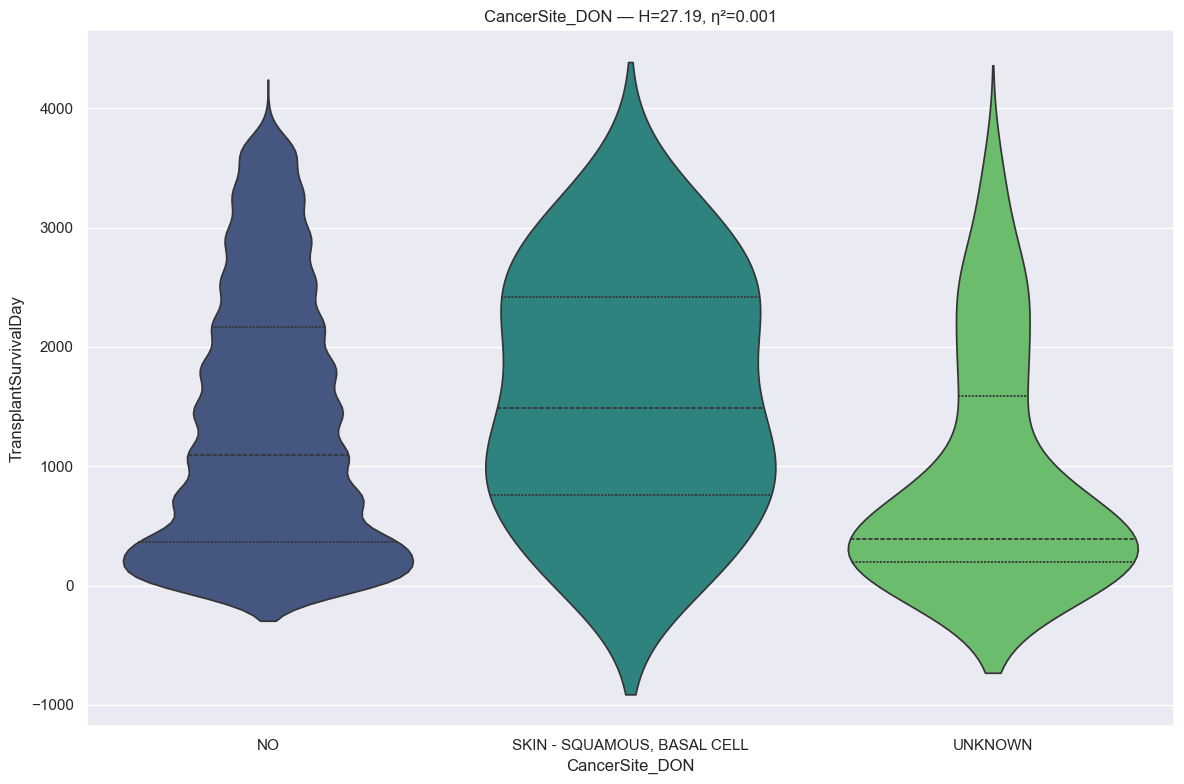

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * NO                                                :  19700 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     49 records
 * UNKNOWN                                           :    131 records
BYPASSED CATEGORIES (n < min_n):
 * CNS TUMOR - ASTROCYTOMA                           :     13 records
 * CNS TUMOR - GLIOBLASTOMA MULTIFORME               :     11 records
 * CNS TUMOR - MEDULLOBLASTOMA                       :      1 records
 * CNS TUMOR - MENINGIOMA                            :      3 records
 * CNS TUMOR - OTHER                                 :     13 records
 * GASTROINTESTINAL - COLO-RECTAL                    :      3 records
 * GASTROINTESTINAL - STOMACH                        :      1 records
 * GENITOURINARY - BLADDER                           :      2 records
 * GENITOURINARY - KIDNEY                            :      6 records
 * GENITOURINARY - PENIS, TESTICULAR                 :     17 reco

In [122]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [123]:
# mapping
mapping = {'CNS TUMOR - ASTROCYTOMA': 'Other-1600s',
 'CNS TUMOR - GLIOBLASTOMA MULTIFORME': 'Other-1000s',
 'CNS TUMOR - MEDULLOBLASTOMA': 'Other',
 'CNS TUMOR - MENINGIOMA': 'Other-700s',
 'CNS TUMOR - OTHER': 'Other-1600s',
 'GASTROINTESTINAL - COLO-RECTAL': 'Other-1700s',
 'GASTROINTESTINAL - STOMACH': 'Other',
 'GENITOURINARY - BLADDER': 'Other',
 'GENITOURINARY - KIDNEY': 'Other-900s',
 'GENITOURINARY - PENIS, TESTICULAR': 'Other-1200s',
 'GENITOURINARY - PROSTATE': 'Other-600s',
 'LEUKEMIA/LYMPHOMA': 'Other-400s',
 'Missing': 'Other-1400s',
 'OTHER, SPECIFY': 'Other-1100s',
 'SKIN - MELANOMA': 'Other-900s',
 'THYROID': 'Other-600s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

             CancerSite_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                         NO         1329.481675                1097.0                 3947.0                    0.0         19700
                    UNKNOWN          919.053435                 393.0                 3630.0                    0.0           131
SKIN - SQUAMOUS, BASAL CELL         1596.142857                1485.0                 3469.0                    7.0            49
                Other-1100s         1199.518519                 707.0                 3284.0                   19.0            27
                Other-1600s         1657.230769                1276.0                 3651.0                    2.0            26
                Other-1200s         1248.882353                 747.0                 3627.0                   24.0            17
                Other-1000s         1069.545455                1121.0                 2184

In [124]:
# mapping
mapping = {'Other': 'Other-1600s'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

             CancerSite_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                         NO         1329.481675                1097.0                 3947.0                    0.0         19700
                    UNKNOWN          919.053435                 393.0                 3630.0                    0.0           131
SKIN - SQUAMOUS, BASAL CELL         1596.142857                1485.0                 3469.0                    7.0            49
                Other-1600s         1653.066667                1427.5                 3651.0                    2.0            30
                Other-1100s         1199.518519                 707.0                 3284.0                   19.0            27
                Other-1200s         1248.882353                 747.0                 3627.0                   24.0            17
                Other-1000s         1069.545455                1121.0                 2184

In [125]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * NO                                                :  19700 records
 * Other-1600s                                       :     30 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     49 records
 * UNKNOWN                                           :    131 records
BYPASSED CATEGORIES (n < min_n):
 * Other-1000s                                       :     11 records
 * Other-1100s                                       :     27 records
 * Other-1200s                                       :     17 records
 * Other-1400s                                       :      9 records
 * Other-1700s                                       :      3 records
 * Other-400s                                        :      6 records
 * Other-600s                                        :     11 records
 * Other-700s                                        :      3 records
 * Other-900s                                        :     10 reco

In [126]:
# mapping:
mapping = {'NO': 'Group_1',
 'Other-1600s': 'Group_2',
 'SKIN - SQUAMOUS, BASAL CELL': 'Group_2',
 'UNKNOWN': 'Group_3'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

CancerSite_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
       Group_1         1329.481675                1097.0                 3947.0                    0.0         19700
       Group_3          919.053435                 393.0                 3630.0                    0.0           131
       Group_2         1617.759494                1460.0                 3651.0                    2.0            79
   Other-1100s         1199.518519                 707.0                 3284.0                   19.0            27
   Other-1200s         1248.882353                 747.0                 3627.0                   24.0            17
   Other-1000s         1069.545455                1121.0                 2184.0                    5.0            11
    Other-600s          627.272727                 342.0                 2072.0                   14.0            11
    Other-900s          914.100000                 634.5        

#### Cigarette History

In [127]:
# info
feature = u.get_feature_info(df, 'CigaretteHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique top   freq
CigaretteHistory_DON  20007      4  No  17458

:::: NaN Count:
CigaretteHistory_DON    0 



{'CigaretteHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

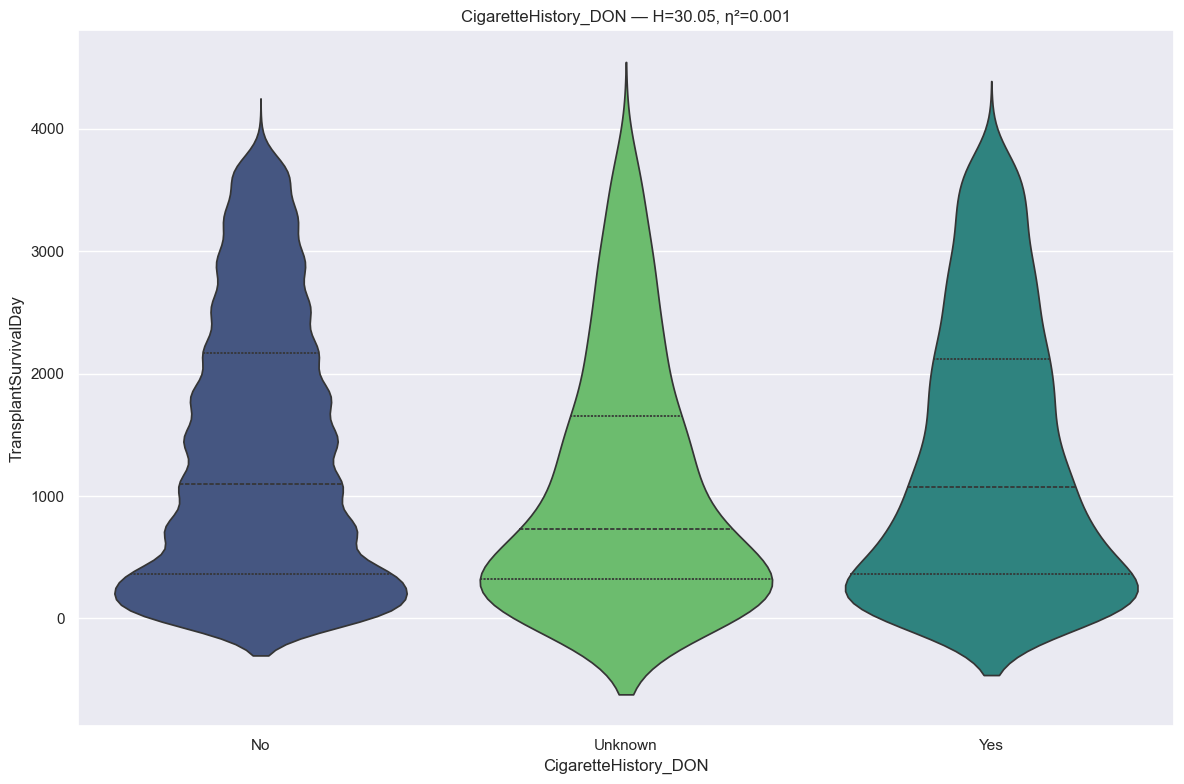

RANKING REPORT: CigaretteHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  17458 records
 * Unknown                                           :    341 records
 * Yes                                               :   2204 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 30.0505 | P-value: 2.982686e-07 | Effect η²: 0.0014
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.2083e-06 | thr=0.0167 | r=-0.153 | *Sig*
Unknown      vs Yes          | p=6.9672e-04 | thr=0.0167 | r= 0.114 | *Sig*
No           vs Yes          | p=5.3642e-03 | thr=0.0167 | r=-0.036 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::::

In [128]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [129]:
# mapping (Missing and Unknown are close enough, with only 4 in Missing)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

CigaretteHistory_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                  No         1337.473880                1101.0                 3947.0                    0.0         17458
                 Yes         1282.543557                1075.0                 3928.0                    0.0          2204
               Other         1064.176812                 734.0                 3926.0                    0.0           345


#### Hypertension History

In [130]:
# info
feature = u.get_feature_info(df, 'HypertensionHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                         count unique top   freq
HypertensionHistory_DON  20007      4  No  17184

:::: NaN Count:
HypertensionHistory_DON    0 



{'HypertensionHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

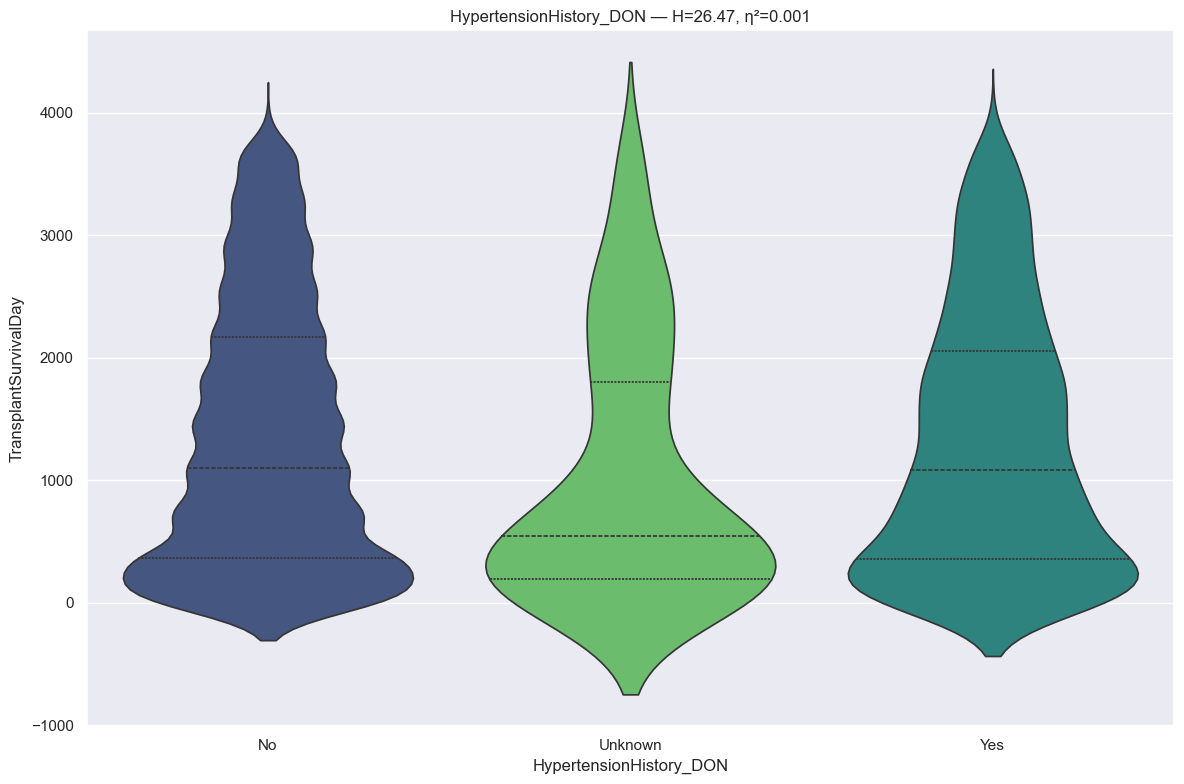

RANKING REPORT: HypertensionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  17184 records
 * Unknown                                           :    169 records
 * Yes                                               :   2651 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 26.4739 | P-value: 1.783466e-06 | Effect η²: 0.0012
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.4131e-05 | thr=0.0167 | r=-0.194 | *Sig*
Unknown      vs Yes          | p=4.7612e-04 | thr=0.0167 | r= 0.160 | *Sig*
No           vs Yes          | p=3.6089e-03 | thr=0.0167 | r=-0.035 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::

In [131]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [132]:
# mapping (Missing and Unknown are close enough, with only 3 in Missing)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

HypertensionHistory_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                     No         1337.980680                1099.0                 3947.0                    0.0         17184
                    Yes         1273.089023                1085.0                 3926.0                    0.0          2651
                  Other         1027.133721                 598.5                 3668.0                    1.0           172


#### Cancer Intra Cranial

In [133]:
# info
feature = u.get_feature_info(df, 'CancerIntraCranial', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique top   freq
CancerIntraCranial_DON  20007      4  No  19795

:::: NaN Count:
CancerIntraCranial_DON    0 



{'CancerIntraCranial_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

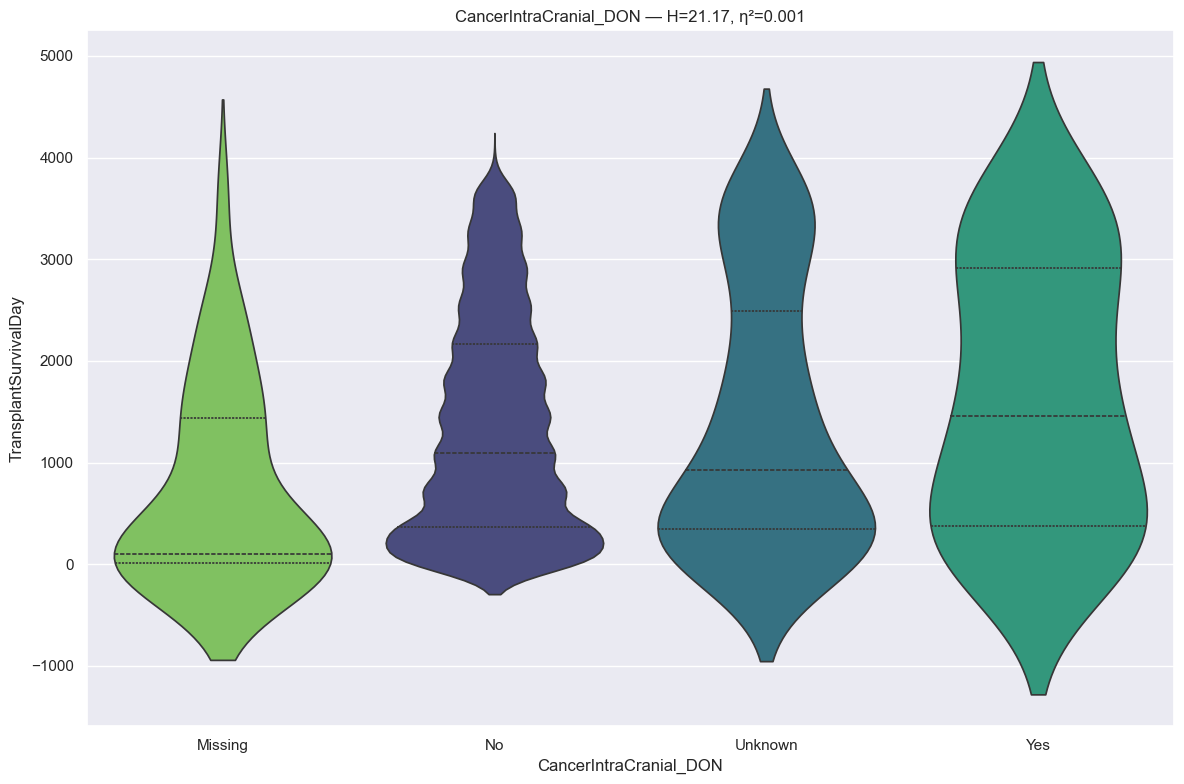

RANKING REPORT: CancerIntraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19795 records
 * Unknown                                           :    138 records
 * Yes                                               :     36 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 21.1748 | P-value: 9.683317e-05 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=9.3416e-06 | thr=0.0083 | r= 0.415 | *Sig*
Missing      vs Unknown      | p=4.8686e-04 | thr=0.0083 | r= 0.370 | *Sig*
Missing      vs Yes          | p=7.8295e-04 | thr=0.0083 | r= 0.455 | *Sig*
No           vs Yes          | p=2.2587e-01 | thr=0.0083 | r= 0.117 | Not Sig


In [134]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [135]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cancer History

In [136]:
# info
feature = u.get_feature_info(df, 'CancerHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique top   freq
CancerHistory_DON  20007      4  No  19700

:::: NaN Count:
CancerHistory_DON    0 



{'CancerHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

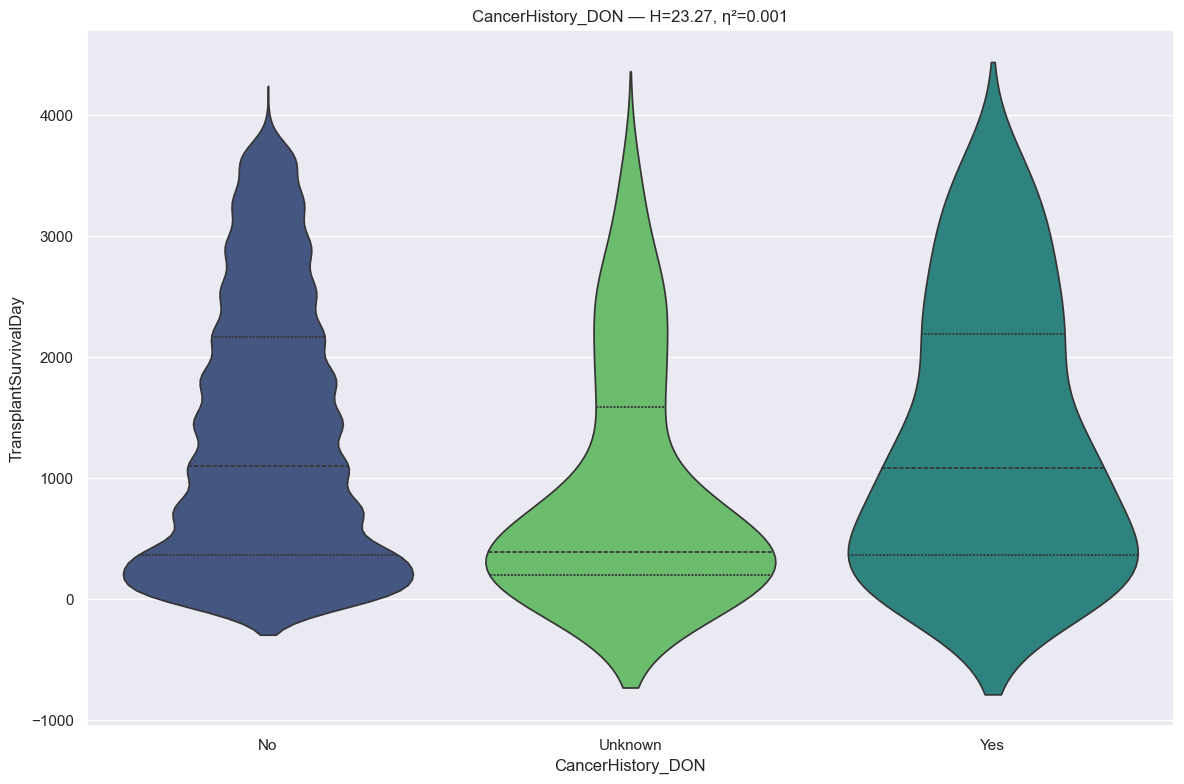

RANKING REPORT: CancerHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19700 records
 * Unknown                                           :    131 records
 * Yes                                               :    167 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      9 records
--------------------------------------------------------------------------------
Kruskal H: 23.2717 | P-value: 8.843183e-06 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.5398e-06 | thr=0.0167 | r=-0.243 | *Sig*
Unknown      vs Yes          | p=1.1376e-03 | thr=0.0167 | r= 0.220 | *Sig*
No           vs Yes          | p=6.4680e-01 | thr=0.0167 | r=-0.021 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::

In [137]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [138]:
# mapping (Combine missing to unknown, not enough to trust the mean survival at all)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

CancerHistory_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
               No         1329.481675                1097.0                 3947.0                    0.0         19700
              Yes         1312.041916                1084.0                 3651.0                    0.0           167
            Other          954.185714                 431.0                 3631.0                    0.0           140


#### Diabetes History

In [139]:
# info
feature = u.get_feature_info(df, 'DiabetesHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique top   freq
DiabetesHistory_DON  20007      7  No  19246

:::: NaN Count:
DiabetesHistory_DON    0 



{'DiabetesHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes, 0-5 Years',
                   'Yes, 6-10 Years', 'Yes, >10 Years',
                   'Yes, Duration Unknown'],
 , ordered=False, categories_dtype=object)}

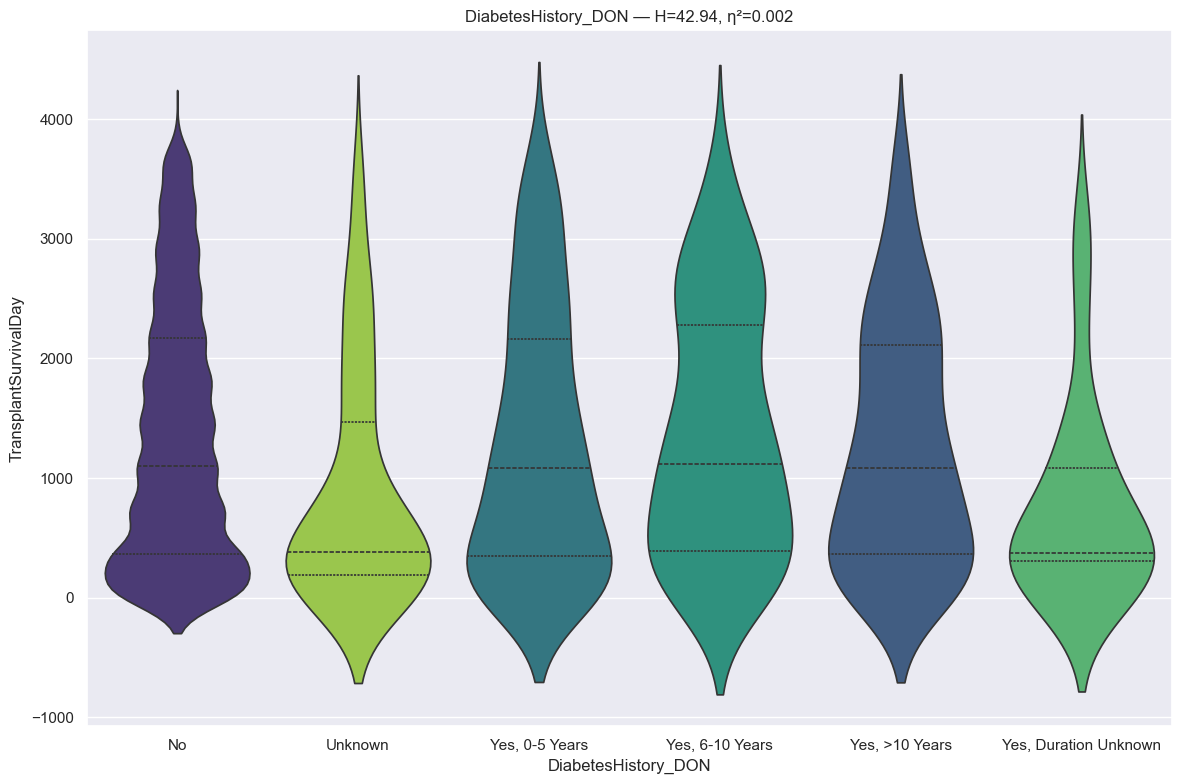

RANKING REPORT: DiabetesHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19246 records
 * Unknown                                           :    142 records
 * Yes, 0-5 Years                                    :    286 records
 * Yes, 6-10 Years                                   :    113 records
 * Yes, >10 Years                                    :    173 records
 * Yes, Duration Unknown                             :     44 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 42.9378 | P-value: 3.803828e-08 | Effect η²: 0.0019
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.1645e-07 | thr=0.0033 | r=-0.258 | *Sig*
Unknown      vs 

In [140]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [141]:
# mapping: collapse - similar survival days
mapping = {'Yes, 0-5 Years': 'Other',
           'Yes, >10 Years': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

  DiabetesHistory_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                   No         1332.350099                1098.0                 3947.0                    0.0         19246
                Other         1264.374459                1084.5                 3773.0                    0.0           462
              Unknown          894.866197                 382.0                 3652.0                    1.0           142
      Yes, 6-10 Years         1379.415929                1120.0                 3644.0                    0.0           113
Yes, Duration Unknown          772.500000                 374.0                 3255.0                    0.0            44


#### Diabetes

In [142]:
# info
feature = u.get_feature_info(df, 'Diabetes_DON', cat=False)
# dtype
{col: df[col].dtype for col in feature}

              count unique top   freq
Diabetes_DON  20007      4  No  19246

:::: NaN Count:
Diabetes_DON    0 



{'Diabetes_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

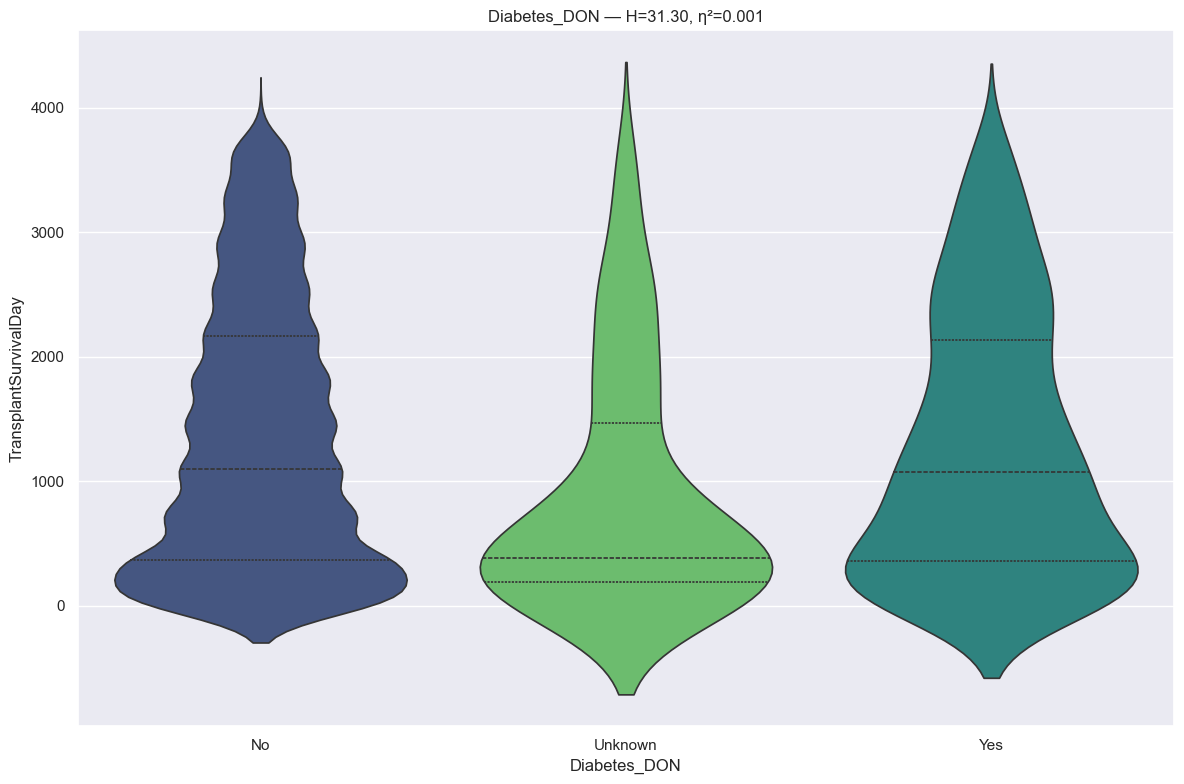

RANKING REPORT: Diabetes_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19246 records
 * Unknown                                           :    142 records
 * Yes                                               :    616 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 31.3042 | P-value: 1.593636e-07 | Effect η²: 0.0015
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.1645e-07 | thr=0.0167 | r=-0.258 | *Sig*
Unknown      vs Yes          | p=5.4937e-05 | thr=0.0167 | r= 0.217 | *Sig*
No           vs Yes          | p=6.1477e-02 | thr=0.0167 | r=-0.044 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

::::::::::::::::::::::

In [143]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [144]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

Diabetes_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
          No         1332.350099                1098.0                 3947.0                    0.0         19246
         Yes         1250.383117                1075.0                 3773.0                    0.0           616
       Other          902.344828                 383.0                 3652.0                    1.0           145


#### Past Other Drug Use

In [145]:
# info
feature = u.get_feature_info(df, 'PastOtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique  top   freq
PastOtherDrugUse_DON  20007      4  Yes  11850

:::: NaN Count:
PastOtherDrugUse_DON    0 



{'PastOtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

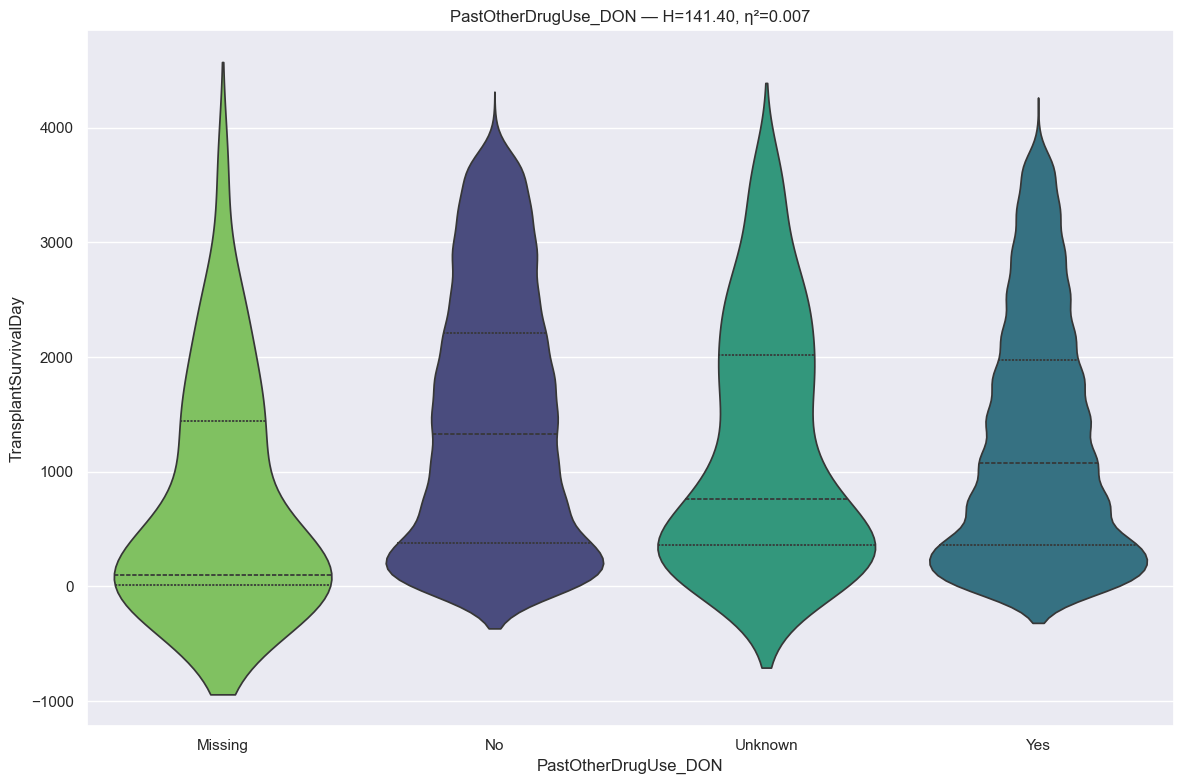

RANKING REPORT: PastOtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   7887 records
 * Unknown                                           :    232 records
 * Yes                                               :  11850 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 141.3953 | P-value: 1.890553e-30 | Effect η²: 0.0069
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.2679e-27 | thr=0.0083 | r=-0.091 | *Sig*
Missing      vs No           | p=1.5441e-06 | thr=0.0083 | r= 0.451 | *Sig*
Missing      vs Yes          | p=2.9163e-05 | thr=0.0083 | r= 0.392 | *Sig*
Missing      vs Unknown      | p=2.1638e-04 | thr=0.0083 | r= 0.375 | *Sig*
No 

In [146]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Cancer Skin

In [147]:
# info
feature = u.get_feature_info(df, 'CancerSkin', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                count unique top   freq
CancerSkin_DON  20007      4  No  19824

:::: NaN Count:
CancerSkin_DON    0 



{'CancerSkin_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

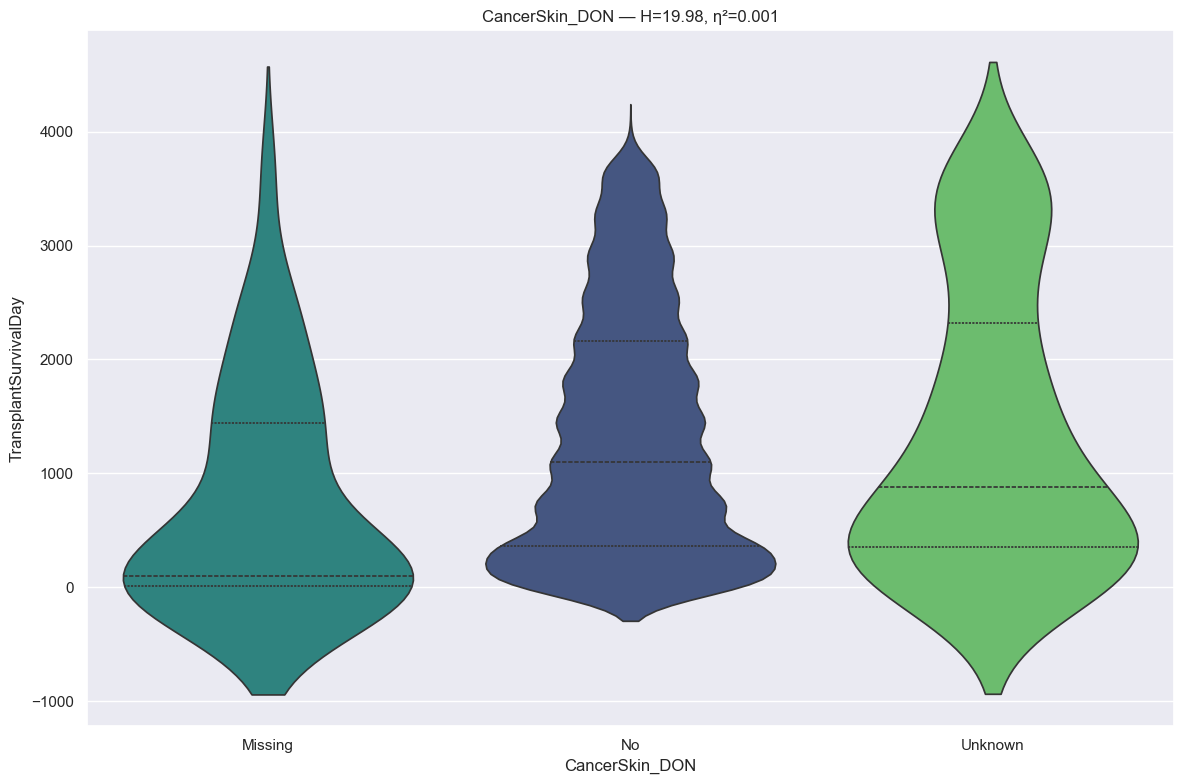

RANKING REPORT: CancerSkin_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19824 records
 * Unknown                                           :    130 records
BYPASSED CATEGORIES (n < min_n):
 * Yes                                               :     15 records
--------------------------------------------------------------------------------
Kruskal H: 19.9765 | P-value: 4.593722e-05 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=9.3689e-06 | thr=0.0167 | r= 0.415 | *Sig*
Missing      vs Unknown      | p=7.3474e-04 | thr=0.0167 | r= 0.361 | *Sig*
No           vs Unknown      | p=5.4153e-01 | thr=0.0167 | r=-0.031 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

::::::::::::::::::::

In [148]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [149]:
# mapping: collapse No & Unknown into Other: similar survival days
mapping = {'Unknown': 'Other',
           'No': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

CancerSkin_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
         Other         1327.331462                1097.0                 3947.0                    0.0         19954
       Missing          737.078947                  98.5                 3631.0                    0.0            38
           Yes         1993.666667                2553.0                 3659.0                  193.0            15


#### Serology Anti CMV

In [150]:
# info
feature = u.get_feature_info(df, 'SerologyAntiCMV', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique       top   freq
SerologyAntiCMV_DON  20007      6  Positive  11684

:::: NaN Count:
SerologyAntiCMV_DON    0 



{'SerologyAntiCMV_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

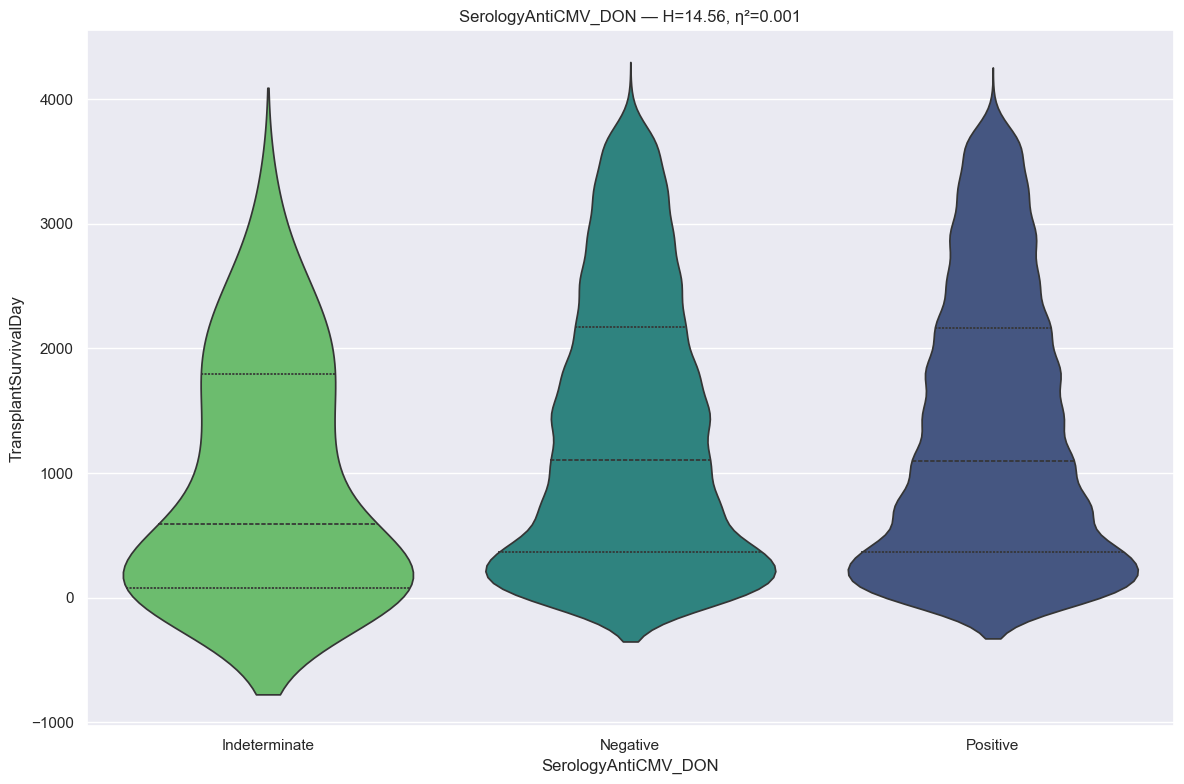

RANKING REPORT: SerologyAntiCMV_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     78 records
 * Negative                                          :   8224 records
 * Positive                                          :  11684 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      6 records
 * Not Done                                          :     14 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 14.5610 | P-value: 6.888544e-04 | Effect η²: 0.0006
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Indeterminate vs Negative     | p=1.5395e-04 | thr=0.0167 | r= 0.249 | *Sig*
Indeterminate vs Positive     | p=2.0495e-04 | thr=0.0167 | r= 0.244 | *Sig*
Negative

In [151]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [152]:
# mapping (Missing and Unknown are close enough, with only 4 in Missing)
mapping = {'Not Done': 'Other',
           'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

SerologyAntiCMV_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           Positive         1323.053834                1095.0                 3928.0                    0.0         11684
           Negative         1335.547787                1102.0                 3947.0                    0.0          8224
      Indeterminate          925.384615                 589.5                 3316.0                    0.0            78
              Other         1390.476190                1097.0                 3273.0                    0.0            21


#### Cause Of Death

In [153]:
# info
feature = u.get_feature_info(df, 'CauseOfDeath', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                  count unique          top   freq
CauseOfDeath_DON  20007      6  HEAD TRAUMA  10708

:::: NaN Count:
CauseOfDeath_DON    0 



{'CauseOfDeath_DON': CategoricalDtype(categories=['ANOXIA', 'CEREBROVASCULAR/STROKE', 'CNS TUMOR',
                   'HEAD TRAUMA', 'Missing', 'OTHER SPECIFY'],
 , ordered=False, categories_dtype=object)}

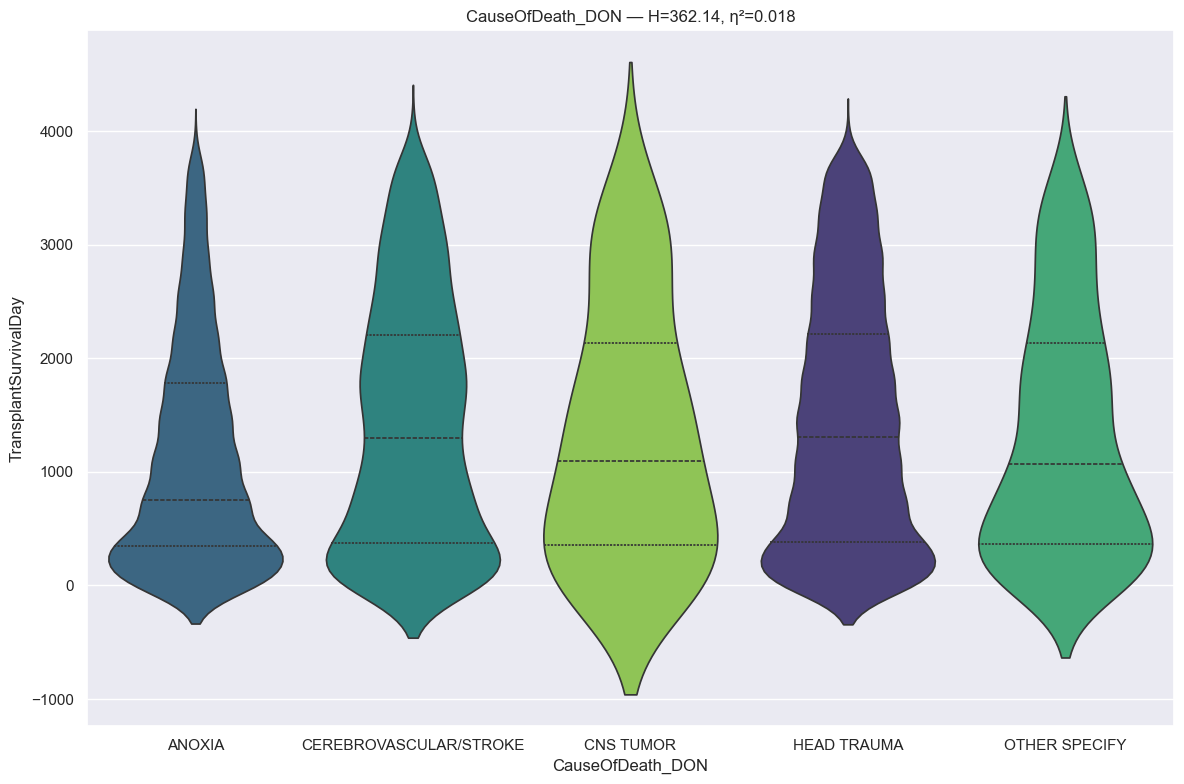

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   6414 records
 * CEREBROVASCULAR/STROKE                            :   2387 records
 * CNS TUMOR                                         :     68 records
 * HEAD TRAUMA                                       :  10708 records
 * OTHER SPECIFY                                     :    427 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 362.1440 | P-value: 4.184833e-77 | Effect η²: 0.0179
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
ANOXIA       vs HEAD TRAUMA  | p=1.1449e-77 | thr=0.0050 | r= 0.170 | *Sig*
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.0572e-28 | thr=0.0050 | r= 0.154 | *Sig*
AN

In [154]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [155]:
# mapping: collapse Missing & OTHER SPECIFY into Other: underpowered, small sample size
mapping = {'OTHER SPECIFY': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

      CauseOfDeath_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           HEAD TRAUMA         1438.529324                1309.0                 3945.0                    0.0         10708
                ANOXIA         1109.235734                 756.0                 3860.0                    0.0          6414
CEREBROVASCULAR/STROKE         1414.826979                1295.0                 3947.0                    0.0          2387
                 Other         1299.388372                1072.5                 3672.0                    0.0           430
             CNS TUMOR         1310.985294                1095.0                 3648.0                    1.0            68


In [156]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   6414 records
 * CEREBROVASCULAR/STROKE                            :   2387 records
 * CNS TUMOR                                         :     68 records
 * HEAD TRAUMA                                       :  10708 records
 * Other                                             :    430 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 362.1514 | P-value: 4.169307e-77 | Effect η²: 0.0179
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (5 categories)
  - ANOXIA
  - CEREBROVASCULAR/STROK

In [157]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Death Mechanism

In [158]:
# info
feature = u.get_feature_info(df, 'DeathMechanism', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique           top  freq
DeathMechanism_DON  20007     13  BLUNT INJURY  6265

:::: NaN Count:
DeathMechanism_DON    0 



{'DeathMechanism_DON': CategoricalDtype(categories=['ASPHYXIATION', 'BLUNT INJURY', 'CARDIOVASCULAR',
                   'DEATH FROM NATURAL CAUSES', 'DROWNING', 'DRUG INTOXICATION',
                   'ELECTRICAL', 'GUNSHOT WOUND',
                   'INTRACRANIAL HEMORRHAGE/STROKE', 'Missing',
                   'NONE OF THE ABOVE', 'SEIZURE', 'STAB'],
 , ordered=False, categories_dtype=object)}

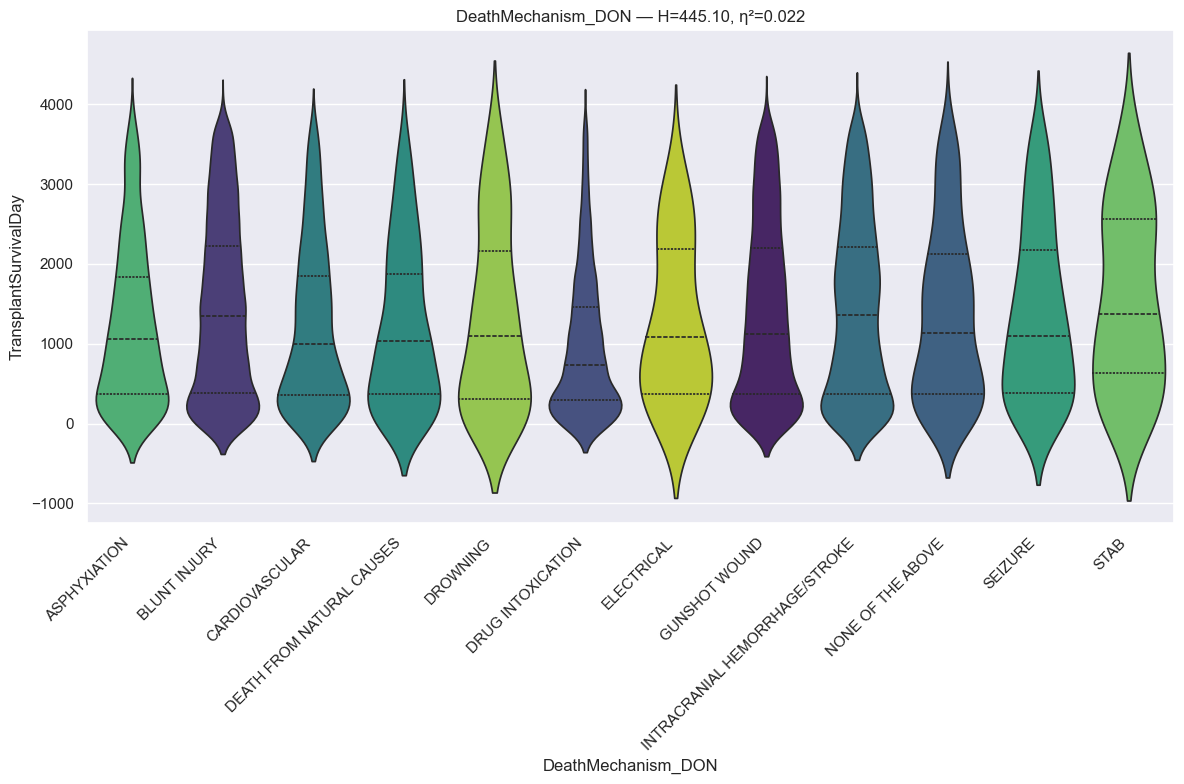

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :   1189 records
 * BLUNT INJURY                                      :   6265 records
 * CARDIOVASCULAR                                    :   1473 records
 * DEATH FROM NATURAL CAUSES                         :    283 records
 * DROWNING                                          :    123 records
 * DRUG INTOXICATION                                 :   3088 records
 * ELECTRICAL                                        :     37 records
 * GUNSHOT WOUND                                     :   4376 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2628 records
 * NONE OF THE ABOVE                                 :    316 records
 * SEIZURE                                           :    157 records
 * STAB                                              :     67 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      5 

In [159]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": True,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [160]:
# mapping: collapse Missing into Group_1: underpowered, small sample size
mapping = {'ASPHYXIATION': 'Group_1',
 'BLUNT INJURY': 'Group_1',
 'CARDIOVASCULAR': 'Group_1',
 'DEATH FROM NATURAL CAUSES': 'Group_1',
 'DROWNING': 'Group_1',
 'ELECTRICAL': 'Group_1',
 'GUNSHOT WOUND': 'Group_1',
 'INTRACRANIAL HEMORRHAGE/STROKE': 'Group_1',
 'NONE OF THE ABOVE': 'Group_1',
 'SEIZURE': 'Group_1',
 'STAB': 'Group_1',
 'DRUG INTOXICATION': 'Group_2',
 'Missing': 'Group_1'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

DeathMechanism_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           Group_1         1389.717655                1120.0                 3947.0                    0.0         16919
           Group_2          981.493847                 730.0                 3832.0                    0.0          3088


#### Heparin Management

In [161]:
# info
feature = u.get_feature_info(df, 'HeparinManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique  top   freq
HeparinManagement_DON  20007      4  Yes  19641

:::: NaN Count:
HeparinManagement_DON    0 



{'HeparinManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

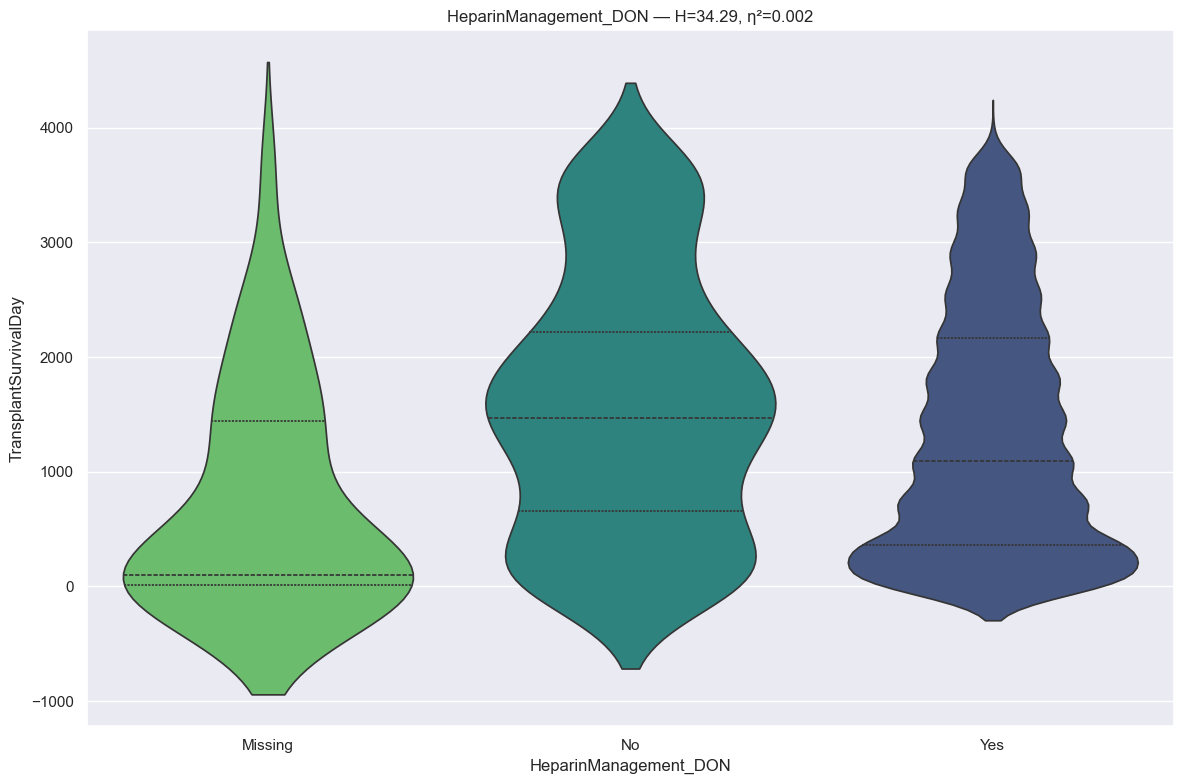

RANKING REPORT: HeparinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :    326 records
 * Yes                                               :  19641 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 34.2892 | P-value: 3.582592e-08 | Effect η²: 0.0016
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=1.3032e-06 | thr=0.0167 | r= 0.480 | *Sig*
Missing      vs Yes          | p=9.9650e-06 | thr=0.0167 | r= 0.414 | *Sig*
No           vs Yes          | p=1.2634e-04 | thr=0.0167 | r=-0.124 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::

In [162]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [163]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

HeparinManagement_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                  Yes         1323.731531                1096.0                 3947.0                    0.0         19641
                   No         1576.549080                1467.5                 3675.0                    0.0           326
                Other          753.000000                 143.5                 3631.0                    0.0            40


#### Arginnie Management

In [164]:
# info
feature = u.get_feature_info(df, 'ArginnieManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                        count unique  top   freq
ArginnieManagement_DON  20007      4  Yes  14031

:::: NaN Count:
ArginnieManagement_DON    0 



{'ArginnieManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

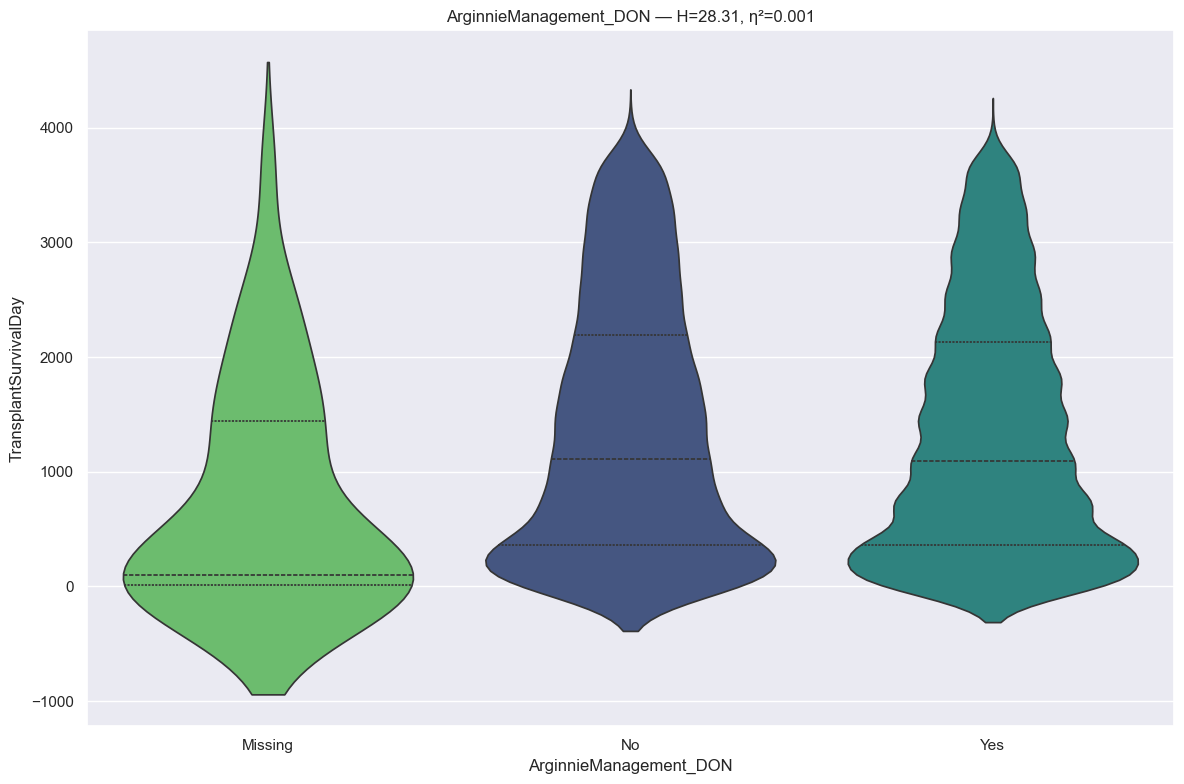

RANKING REPORT: ArginnieManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   5933 records
 * Yes                                               :  14031 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      5 records
--------------------------------------------------------------------------------
Kruskal H: 28.3072 | P-value: 7.131418e-07 | Effect η²: 0.0013
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=5.3773e-06 | thr=0.0167 | r= 0.428 | *Sig*
Missing      vs Yes          | p=1.2332e-05 | thr=0.0167 | r= 0.410 | *Sig*
No           vs Yes          | p=3.1767e-03 | thr=0.0167 | r=-0.026 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::

In [165]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [166]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

ArginnieManagement_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                   Yes         1308.360915                1095.0                 3947.0                    0.0         14031
                    No         1373.578797                1109.0                 3945.0                    0.0          5933
                 Other          847.232558                 184.0                 3639.0                    0.0            43


#### Insulin Management

In [167]:
# info
feature = u.get_feature_info(df, 'InsulinManagement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique  top   freq
InsulinManagement_DON  20007      4  Yes  11293

:::: NaN Count:
InsulinManagement_DON    0 



{'InsulinManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

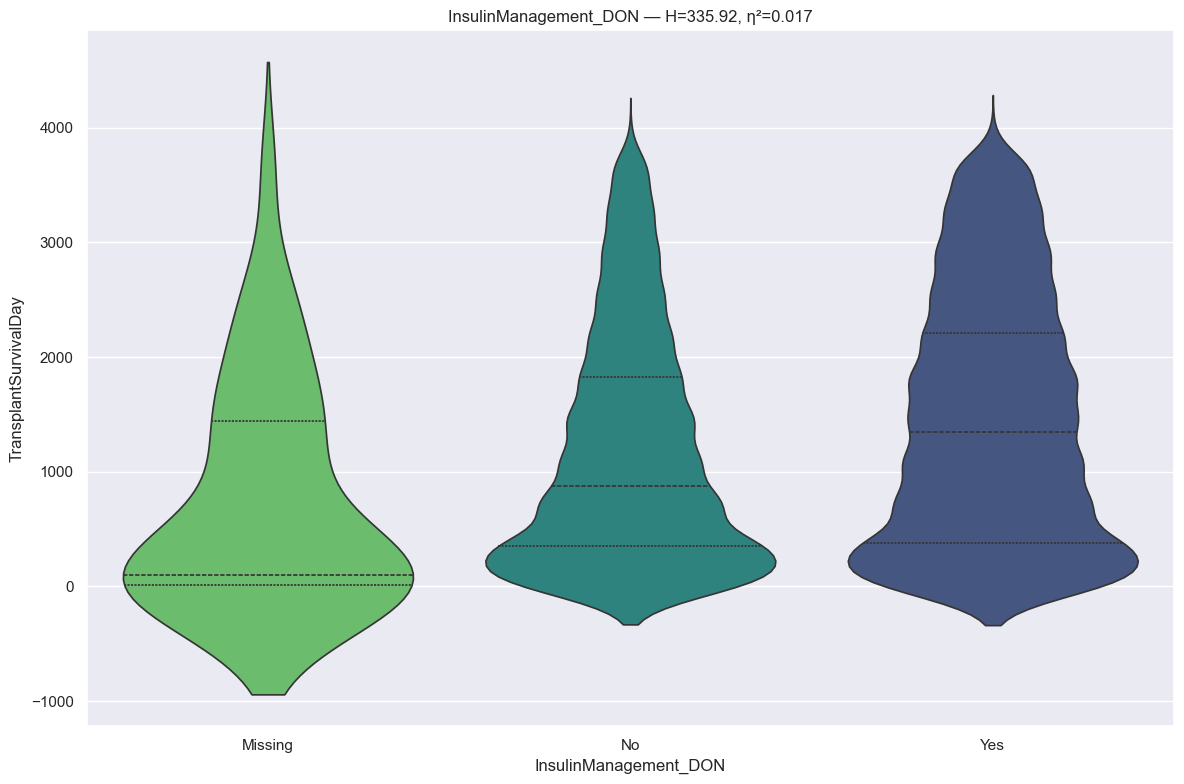

RANKING REPORT: InsulinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   8673 records
 * Yes                                               :  11293 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 335.9164 | P-value: 1.139392e-73 | Effect η²: 0.0167
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=7.4349e-71 | thr=0.0167 | r= 0.147 | *Sig*
Missing      vs Yes          | p=1.1977e-06 | thr=0.0167 | r= 0.456 | *Sig*
Missing      vs No           | p=1.1152e-04 | thr=0.0167 | r= 0.363 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

::::::::::::::

In [168]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [169]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

InsulinManagement_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                  Yes         1447.636766                1344.0                 3947.0                    0.0         11293
                   No         1171.890926                 879.0                 3928.0                    0.0          8673
                Other          768.634146                 184.0                 3631.0                    0.0            41


#### HBV NAT Result

In [170]:
# info
feature = u.get_feature_info(df, 'HBV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top   freq
HBV_NAT_Result_DON  20007      5  Negative  13910

:::: NaN Count:
HBV_NAT_Result_DON    0 



{'HBV_NAT_Result_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Positive', 'Unknown'], ordered=False, categories_dtype=object)}

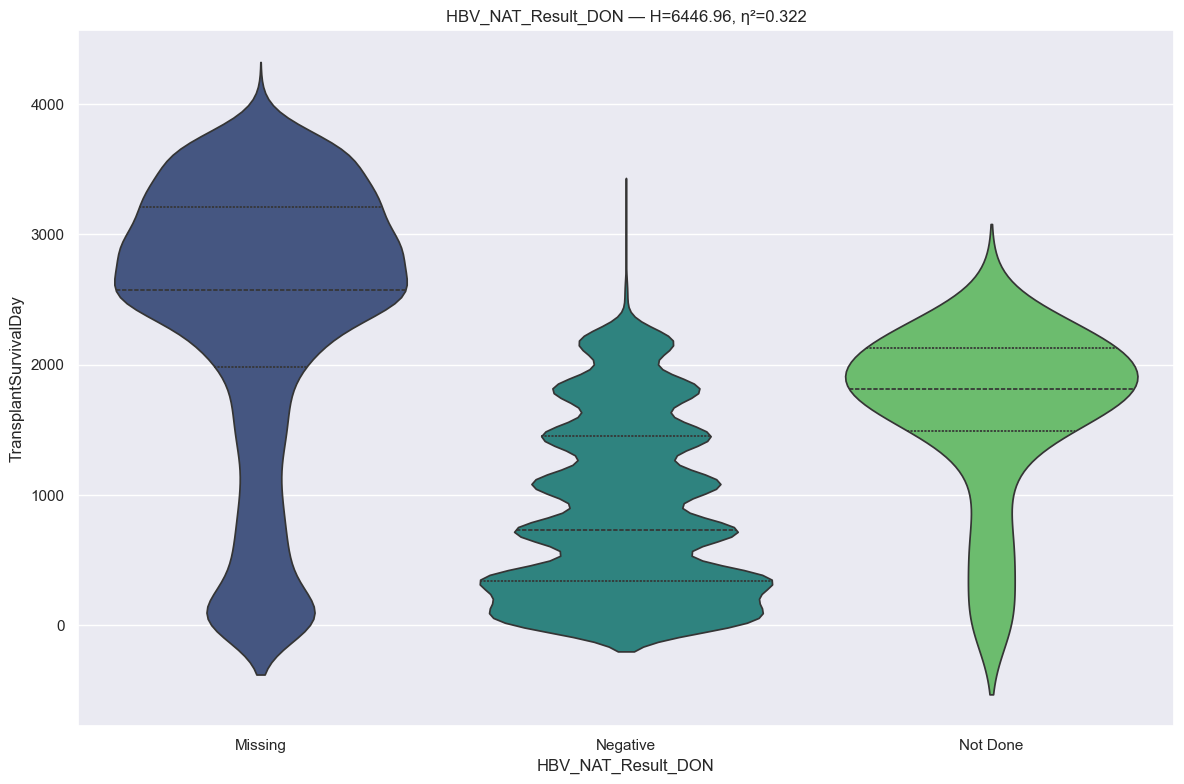

RANKING REPORT: HBV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6008 records
 * Negative                                          :  13910 records
 * Not Done                                          :     75 records
BYPASSED CATEGORIES (n < min_n):
 * Positive                                          :     12 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 6446.9558 | P-value: 0.000000e+00 | Effect η²: 0.3224
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.713 | *Sig*
Negative     vs Not Done     | p=1.1614e-18 | thr=0.0167 | r= 0.589 | *Sig*
Missing      vs Not Done     | p=1.3462e-16 | thr=0.0167 | r=-0.555 | *Sig*
:::

In [171]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [172]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Missing': 'Other',
           'Unknown': 'Other'}
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

HBV_NAT_Result_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
          Negative          872.722358                 733.0                 3235.0                    0.0         13910
             Other         2374.656572                2576.0                 3947.0                    0.0          6010
          Not Done         1647.293333                1816.0                 2551.0                    1.0            75
          Positive          723.750000                 552.5                 2150.0                   25.0            12


#### HCV NAT Result

In [173]:
# info
feature = u.get_feature_info(df, 'HCV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top   freq
HCV_NAT_Result_DON  20007      5  Negative  13311

:::: NaN Count:
HCV_NAT_Result_DON    0 



{'HCV_NAT_Result_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

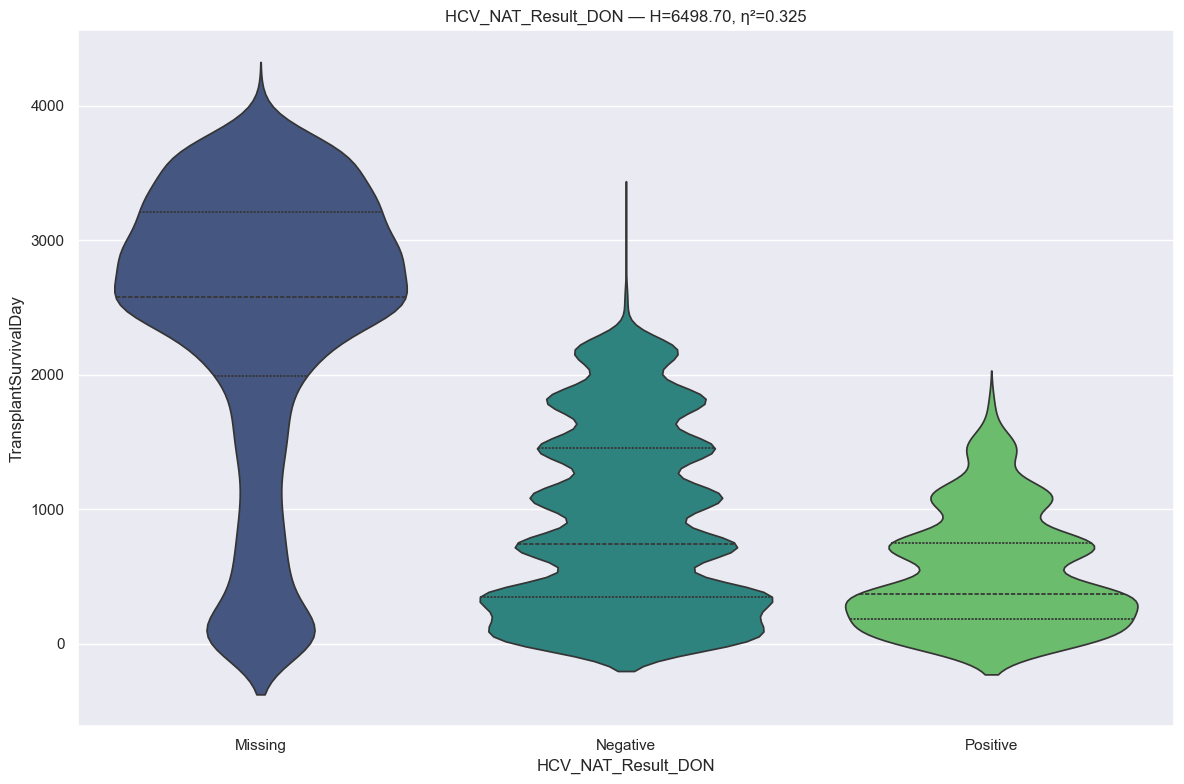

RANKING REPORT: HCV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6008 records
 * Negative                                          :  13311 records
 * Positive                                          :    671 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :      1 records
 * Not Done                                          :     16 records
--------------------------------------------------------------------------------
Kruskal H: 6498.7023 | P-value: 0.000000e+00 | Effect η²: 0.3250
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.709 | *Sig*
Missing      vs Positive     | p=6.1092e-242 | thr=0.0167 | r=-0.781 | *Sig*
Negative     vs Positive     | p=1.8737e-37 | thr=0.0167 | r=-0.292 | *Sig*
::

In [174]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [175]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Not Done': 'Other',
           'Indeterminate': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df,feature[0])

HCV_NAT_Result_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
          Negative          893.940726                 739.0                 3235.0                    0.0         13311
           Missing         2374.868675                2576.0                 3947.0                    0.0          6008
          Positive          528.989568                 373.0                 1802.0                    0.0           671
             Other         1239.882353                1650.0                 2551.0                    1.0            17


#### HIV NAT Result

In [176]:
# info
feature = u.get_feature_info(df, 'HIV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique       top   freq
HIV_NAT_Result_DON  20007      3  Negative  13963

:::: NaN Count:
HIV_NAT_Result_DON    0 



{'HIV_NAT_Result_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Unknown'], ordered=False, categories_dtype=object)}

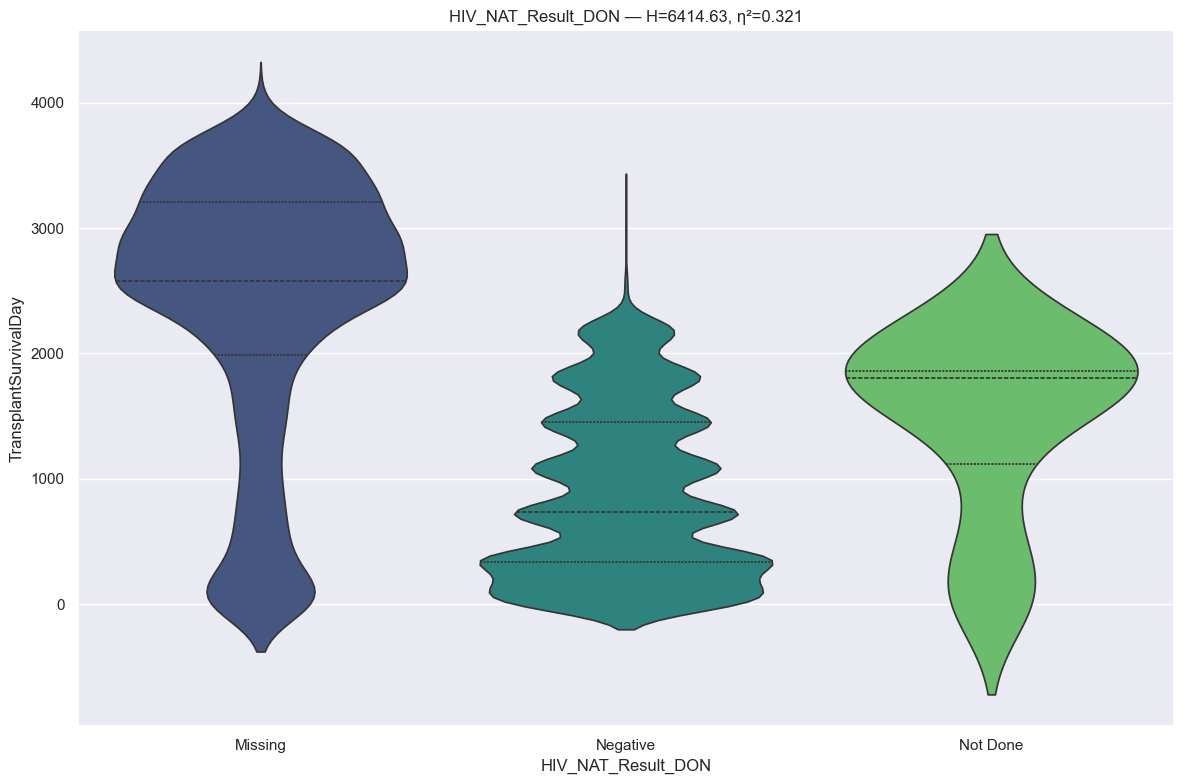

RANKING REPORT: HIV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6008 records
 * Negative                                          :  13963 records
 * Not Done                                          :     36 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 6414.6274 | P-value: 0.000000e+00 | Effect η²: 0.3206
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.713 | *Sig*
Missing      vs Not Done     | p=5.3272e-10 | thr=0.0167 | r=-0.599 | *Sig*
Negative     vs Not Done     | p=2.8547e-06 | thr=0.0167 | r= 0.451 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1

In [177]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Allocation Type

In [178]:
# info
feature = u.get_feature_info(df, 'AllocationType', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique    top   freq
AllocationType_DON  20007      4  Local  10841

:::: NaN Count:
AllocationType_DON    0 



{'AllocationType_DON': CategoricalDtype(categories=['Foreign Donor', 'Local', 'National', 'Regional'], ordered=False, categories_dtype=object)}

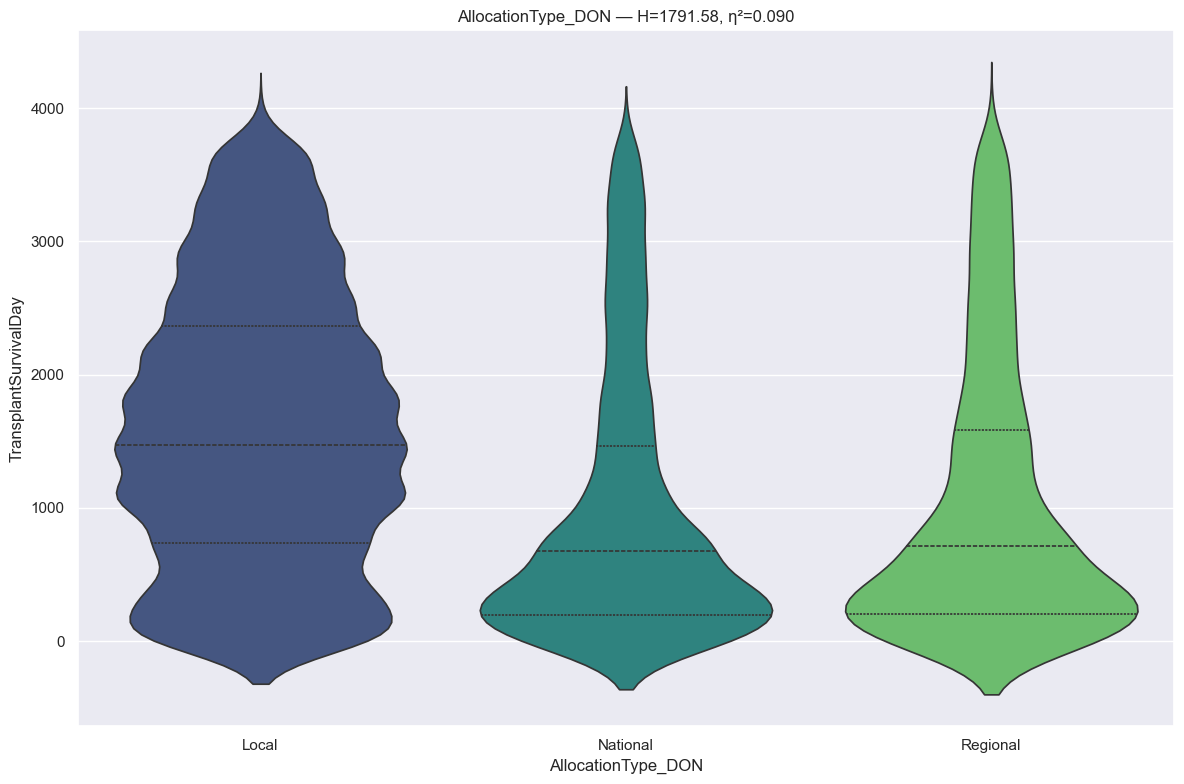

RANKING REPORT: AllocationType_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Local                                             :  10841 records
 * National                                          :   5474 records
 * Regional                                          :   3674 records
BYPASSED CATEGORIES (n < min_n):
 * Foreign Donor                                     :     18 records
--------------------------------------------------------------------------------
Kruskal H: 1791.5771 | P-value: 0.000000e+00 | Effect η²: 0.0895
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Local        vs National     | p=1.7765e-308 | thr=0.0167 | r=-0.359 | *Sig*
Local        vs Regional     | p=3.0850e-193 | thr=0.0167 | r=-0.327 | *Sig*
National     vs Regional     | p=1.7308e-02 | thr=0.0167 | r= 0.029 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

::::::::::::

In [179]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [180]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Urine Portein

In [181]:
# info
feature = u.get_feature_info(df, 'UrinePortein', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                  count unique top   freq
UrinePortein_DON  20007      4  No  10403

:::: NaN Count:
UrinePortein_DON    0 



{'UrinePortein_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

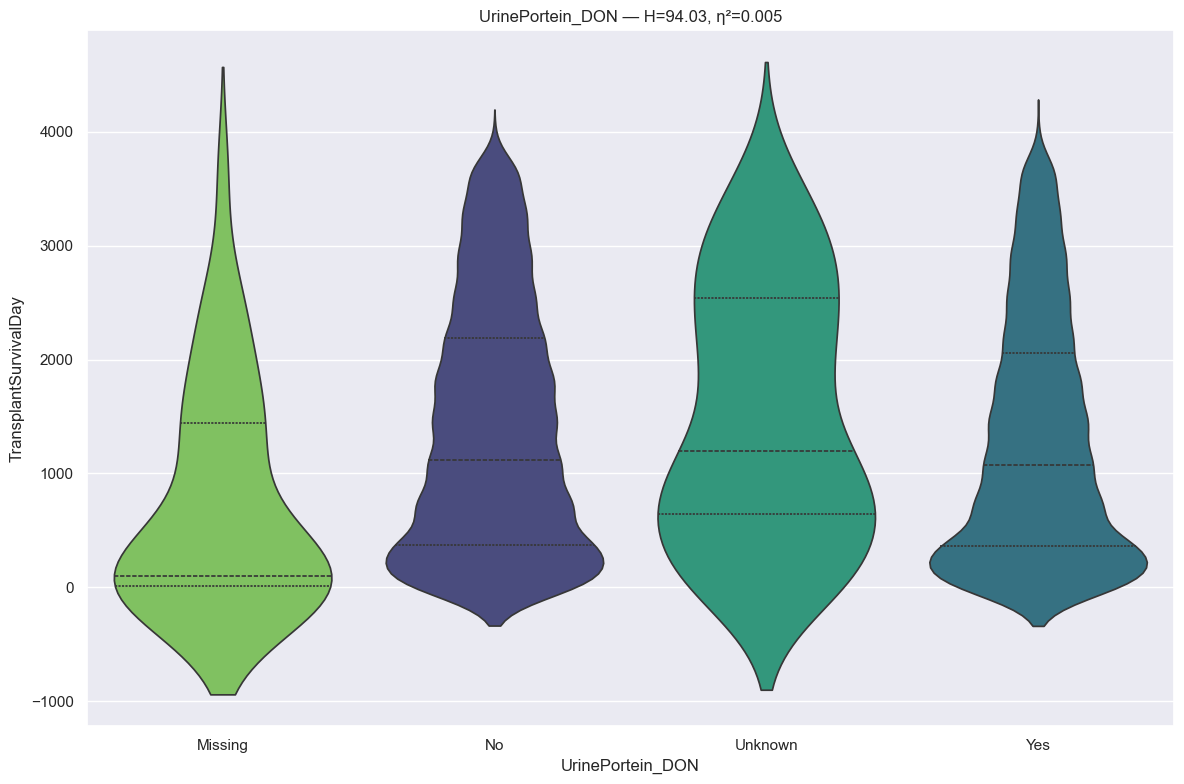

RANKING REPORT: UrinePortein_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  10403 records
 * Unknown                                           :     93 records
 * Yes                                               :   9473 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 94.0278 | P-value: 2.987084e-20 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.4520e-17 | thr=0.0083 | r=-0.070 | *Sig*
Missing      vs No           | p=3.4993e-06 | thr=0.0083 | r= 0.435 | *Sig*
Missing      vs Yes          | p=2.8516e-05 | thr=0.0083 | r= 0.393 | *Sig*
Missing      vs Unknown      | p=3.5685e-05 | thr=0.0083 | r= 0.462 | *Sig*
Unknown 

In [182]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [183]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Cardiac Arrest

In [184]:
# info
feature = u.get_feature_info(df, 'CardiacArrest', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                   count unique top   freq
CardiacArrest_DON  20007      3  No  18354

:::: NaN Count:
CardiacArrest_DON    0 



{'CardiacArrest_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

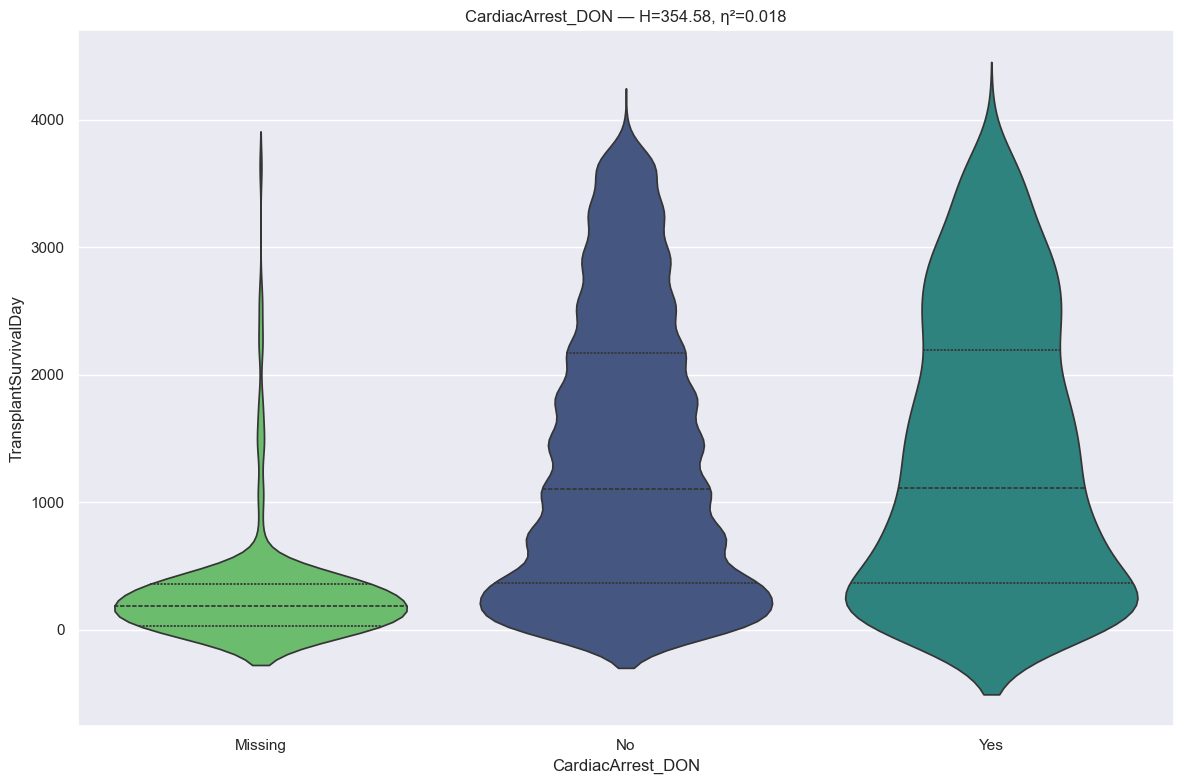

RANKING REPORT: CardiacArrest_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :    275 records
 * No                                                :  18354 records
 * Yes                                               :   1378 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 354.5800 | P-value: 1.009090e-77 | Effect η²: 0.0176
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=3.7899e-79 | thr=0.0167 | r= 0.661 | *Sig*
Missing      vs Yes          | p=4.8727e-65 | thr=0.0167 | r= 0.650 | *Sig*
No           vs Yes          | p=6.1876e-01 | thr=0.0167 | r= 0.008 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1

In [185]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Myocardial Infarction History

In [186]:
# info
feature = u.get_feature_info(df, 'MyocardialInfarctionHistory', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                                 count unique top   freq
MyocardialInfarctionHistory_DON  20007      4  No  19660

:::: NaN Count:
MyocardialInfarctionHistory_DON    0 



{'MyocardialInfarctionHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

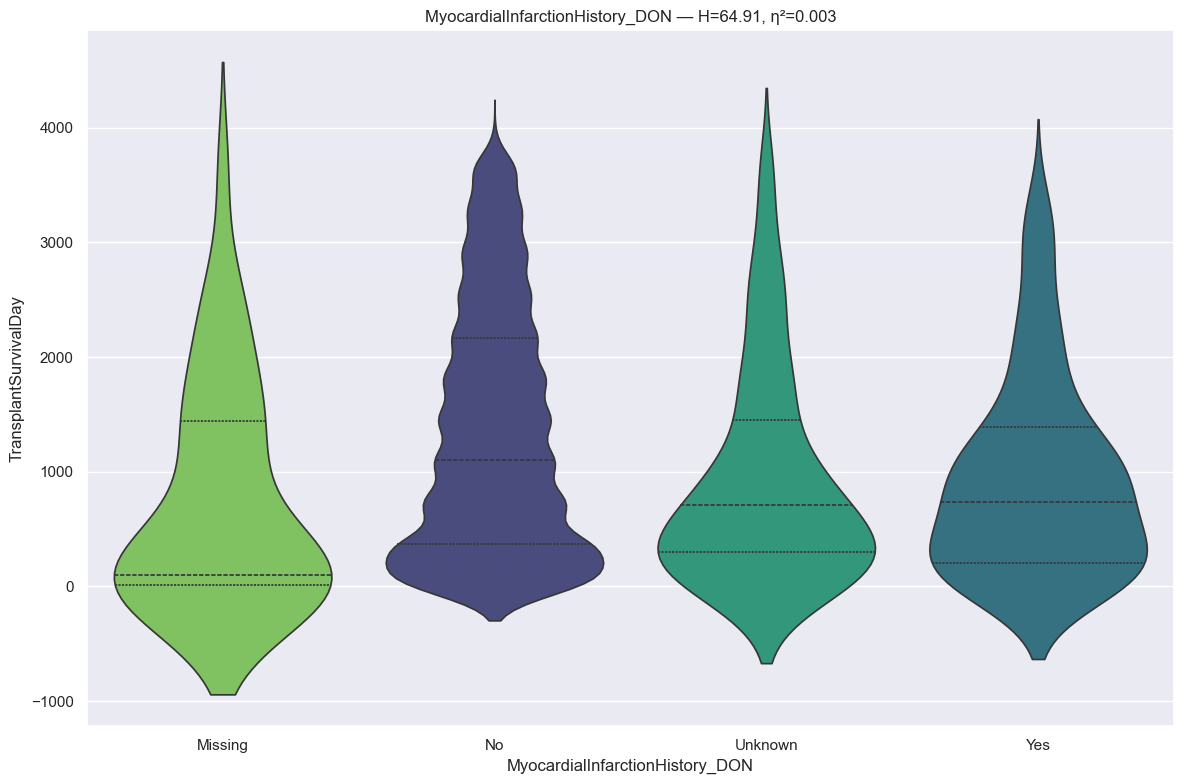

RANKING REPORT: MyocardialInfarctionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19660 records
 * Unknown                                           :    161 records
 * Yes                                               :    148 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 64.9067 | P-value: 5.251866e-14 | Effect η²: 0.0031
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=2.5512e-07 | thr=0.0083 | r=-0.235 | *Sig*
Missing      vs No           | p=8.3832e-06 | thr=0.0083 | r= 0.418 | *Sig*
No           vs Yes          | p=1.2274e-05 | thr=0.0083 | r=-0.208 | *Sig*
Missing      vs Yes          | p=1.1677e-02 | thr=0.0083 | r= 0.266 |

In [187]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### LV Ejection Fraction Medthod

In [188]:
# info
feature = u.get_feature_info(df, 'LV_EjectionFractionMedthod', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                                count unique   top   freq
LV_EjectionFractionMedthod_DON  20007      3  Echo  19588

:::: NaN Count:
LV_EjectionFractionMedthod_DON    0 



{'LV_EjectionFractionMedthod_DON': CategoricalDtype(categories=['Angiogram', 'Echo', 'Missing'], ordered=False, categories_dtype=object)}

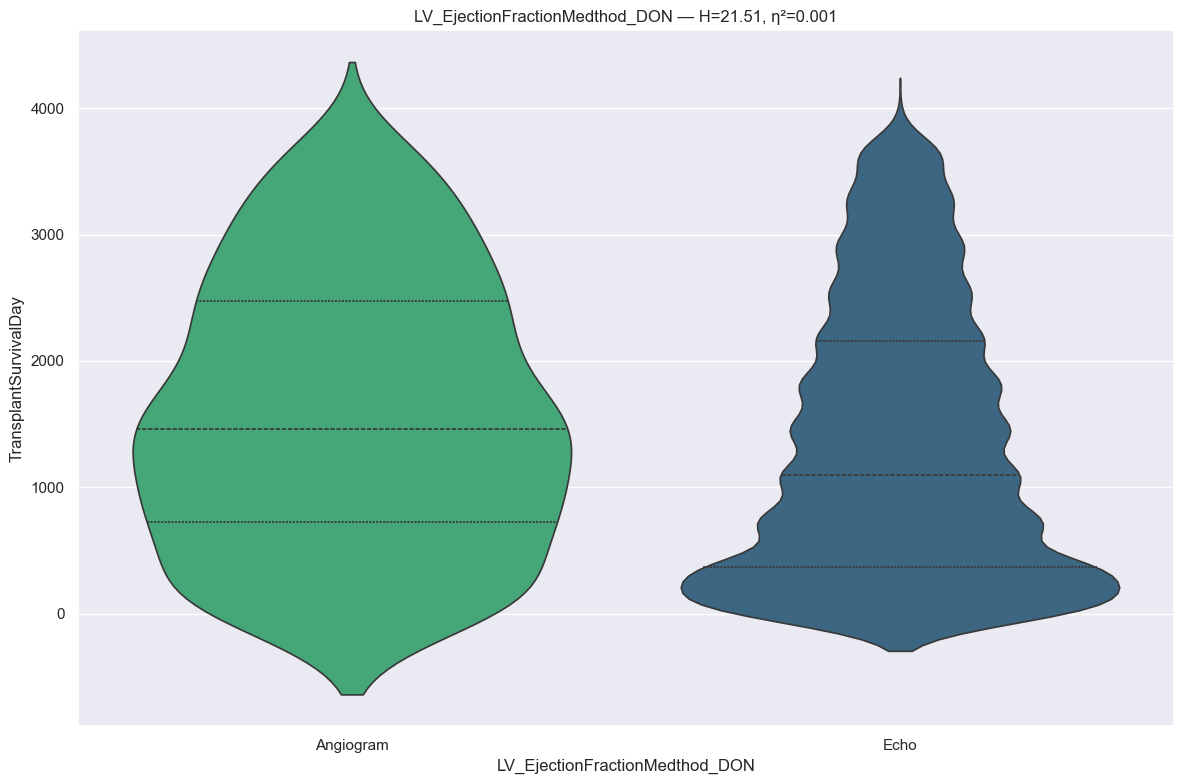

RANKING REPORT: LV_EjectionFractionMedthod_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Angiogram                                         :    392 records
 * Echo                                              :  19588 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     27 records
--------------------------------------------------------------------------------
Kruskal H: 21.5136 | P-value: 3.513237e-06 | Effect η²: 0.0010
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Angiogram    vs Echo         | p=3.5133e-06 | thr=0.0500 | r=-0.137 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Angiogram

>>> Group_2 (1 categories)
  - Echo

>>> Other (1 categories)
  - Missing

LV_EjectionFractionMedthod_DO

In [189]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Coronary Angiogram

In [190]:
# info
feature = u.get_feature_info(df, 'CoronaryAngiogram', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique top   freq
CoronaryAngiogram_DON  20007      4  No  13074

:::: NaN Count:
CoronaryAngiogram_DON    0 



{'CoronaryAngiogram_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes, normal', 'Yes, not normal'], ordered=False, categories_dtype=object)}

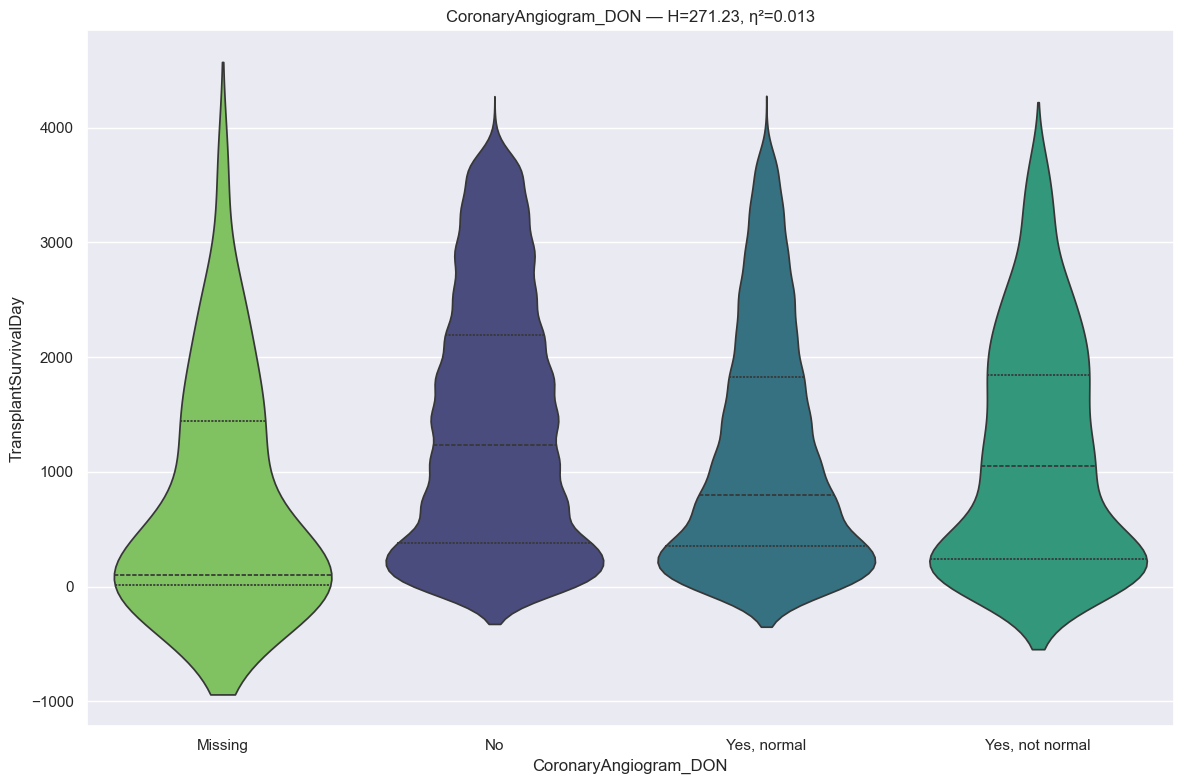

RANKING REPORT: CoronaryAngiogram_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  13074 records
 * Yes, normal                                       :   6222 records
 * Yes, not normal                                   :    673 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 271.2267 | P-value: 1.675236e-58 | Effect η²: 0.0134
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes, normal  | p=1.4356e-52 | thr=0.0083 | r=-0.136 | *Sig*
No           vs Yes, not normal | p=4.1029e-10 | thr=0.0083 | r=-0.143 | *Sig*
Missing      vs No           | p=2.0882e-06 | thr=0.0083 | r= 0.445 | *Sig*
Missing      vs Yes, normal  | p=1.3245e-04 | thr=0.0083 | r= 0.359 | *Sig*

In [191]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Biopsy

In [192]:
# info
feature = u.get_feature_info(df, 'Biopsy', cat=False)
# dtype
{col: df[col].dtype for col in feature}

            count unique              top   freq
Biopsy_DON  20007      5  Biopsy not done  19947

:::: NaN Count:
Biopsy_DON    0 



{'Biopsy_DON': CategoricalDtype(categories=['Biopsy not done', 'Missing', 'Unknown',
                   'Yes, rejection confirmed', 'Yes, rejection not confirmed'],
 , ordered=False, categories_dtype=object)}

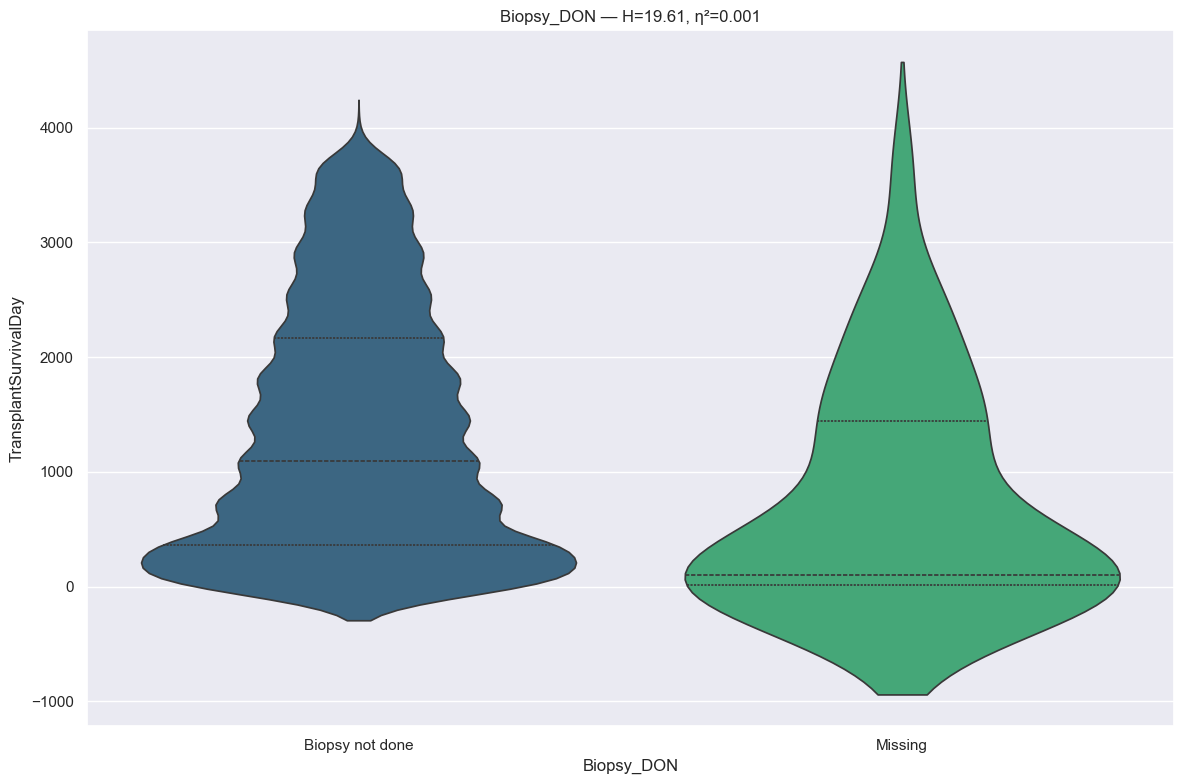

RANKING REPORT: Biopsy_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Biopsy not done                                   :  19947 records
 * Missing                                           :     38 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      6 records
 * Yes, rejection confirmed                          :      8 records
 * Yes, rejection not confirmed                      :      8 records
--------------------------------------------------------------------------------
Kruskal H: 19.6129 | P-value: 9.482535e-06 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Biopsy not done vs Missing      | p=9.4832e-06 | thr=0.0500 | r=-0.415 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categori

In [193]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Tatoos

In [194]:
# info
feature = u.get_feature_info(df, 'Tatoos', cat=False)
# dtype
{col: df[col].dtype for col in feature}

            count unique  top   freq
Tatoos_DON  20007      4  Yes  11191

:::: NaN Count:
Tatoos_DON    0 



{'Tatoos_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

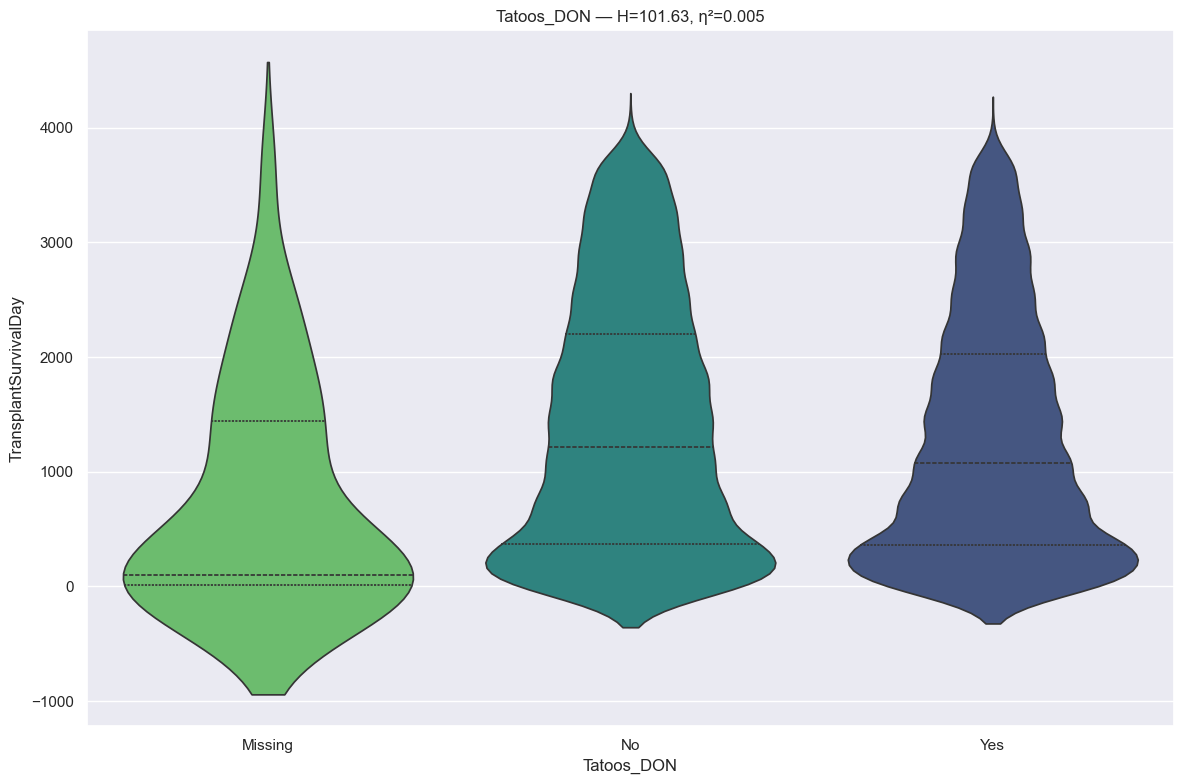

RANKING REPORT: Tatoos_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   8760 records
 * Yes                                               :  11191 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     18 records
--------------------------------------------------------------------------------
Kruskal H: 101.6288 | P-value: 8.542387e-23 | Effect η²: 0.0050
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.2749e-19 | thr=0.0167 | r=-0.075 | *Sig*
Missing      vs No           | p=2.6282e-06 | thr=0.0167 | r= 0.441 | *Sig*
Missing      vs Yes          | p=2.5368e-05 | thr=0.0167 | r= 0.395 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::

In [195]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Antibody Result HBSAB

In [196]:
# info
feature = u.get_feature_info(df, 'AntibodyResultHBSAB', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                         count unique       top   freq
AntibodyResultHBSAB_DON  20007      6  Not Done  16937

:::: NaN Count:
AntibodyResultHBSAB_DON    0 



{'AntibodyResultHBSAB_DON': CategoricalDtype(categories=['Cannot Disclose', 'Indeterminate', 'Missing', 'Negative',
                   'Not Done', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

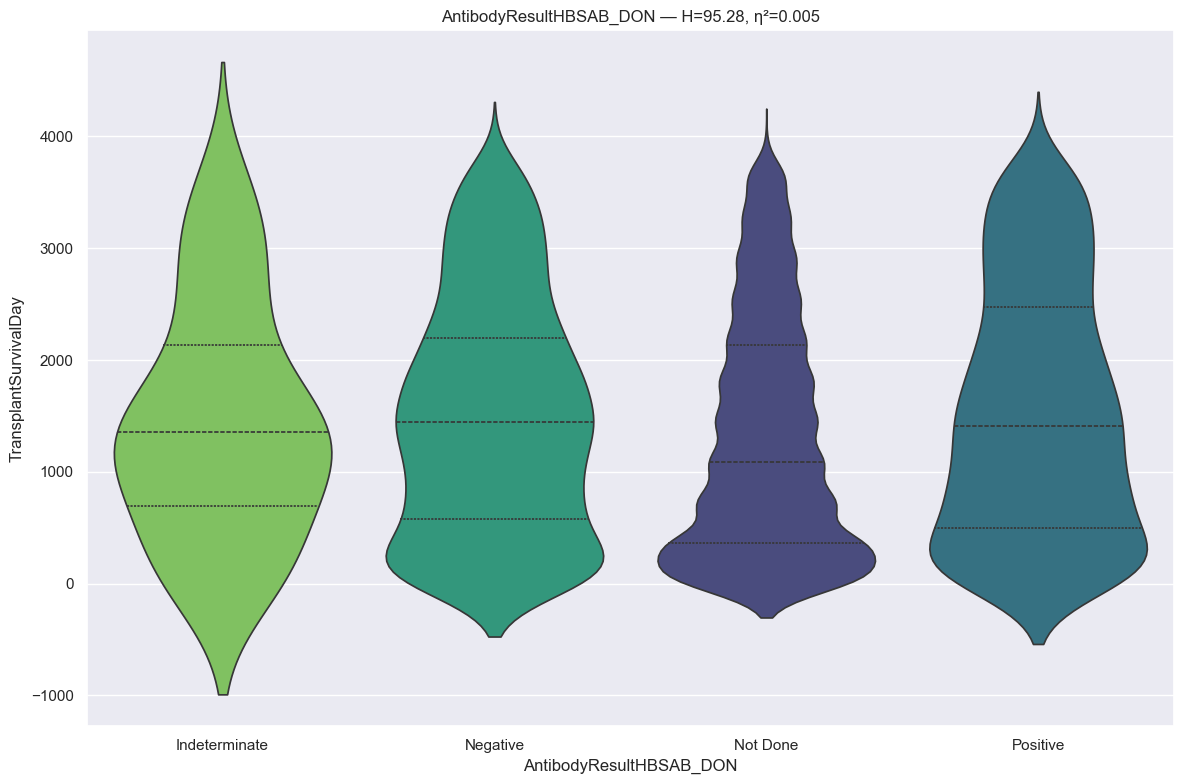

RANKING REPORT: AntibodyResultHBSAB_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     38 records
 * Negative                                          :   1800 records
 * Not Done                                          :  16937 records
 * Positive                                          :   1209 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     19 records
 * Unknown                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 95.2762 | P-value: 1.610478e-20 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=2.7600e-14 | thr=0.0083 | r=-0.109 | *Sig*
Not Done     vs Positive     | p=2.7357e-11 | thr=0.0083 | r= 0.114 | *Sig*
Indete

In [197]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [198]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

AntibodyResultHBSAB_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
               Not Done         1296.121037                1090.0                 3947.0                    0.0         16937
               Negative         1487.124444                1445.0                 3836.0                    0.0          1800
               Positive         1516.790736                1413.0                 3860.0                    0.0          1209
          Indeterminate         1430.631579                1353.0                 3659.0                   17.0            38
                  Other         1134.608696                1094.0                 2947.0                    0.0            23


#### EpsteinBarr IGG

In [199]:
# info
feature = u.get_feature_info(df, 'EpsteinBarr_IGG', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique       top   freq
EpsteinBarr_IGG_DON  20007      7  Positive  17656

:::: NaN Count:
EpsteinBarr_IGG_DON    0 



{'EpsteinBarr_IGG_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

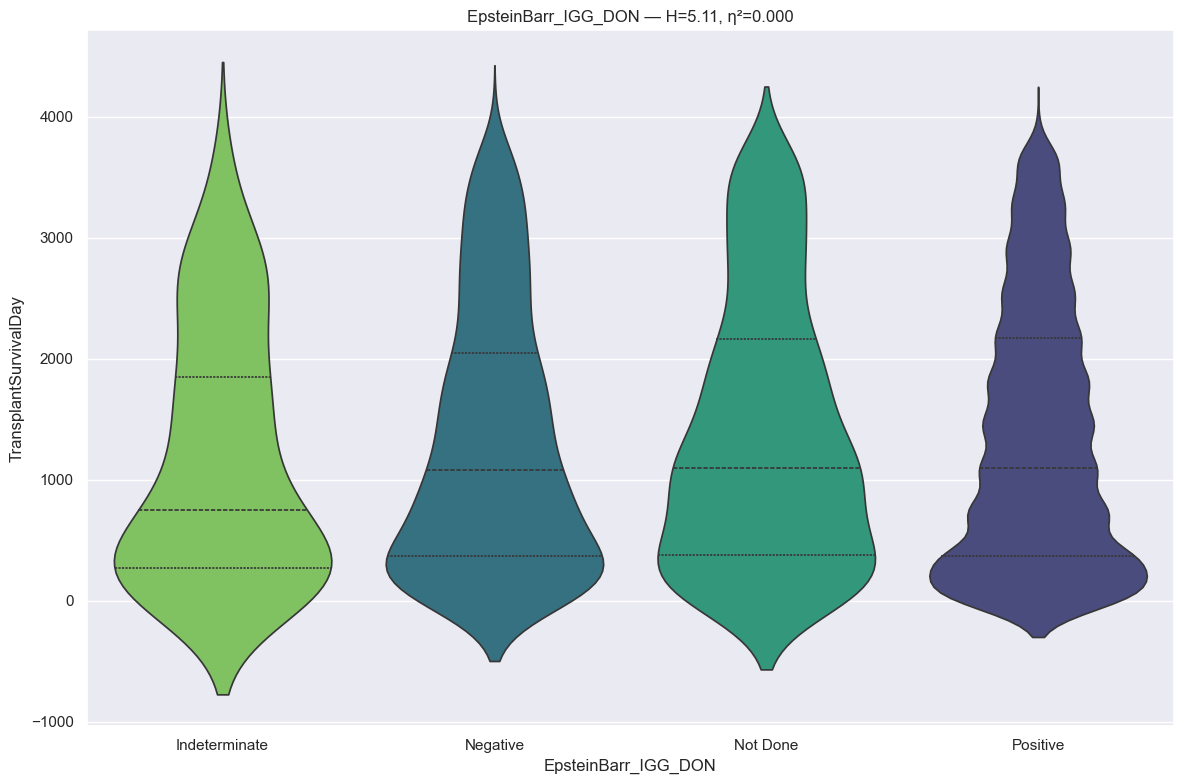

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :    133 records
 * Negative                                          :   1394 records
 * Not Done                                          :    805 records
 * Positive                                          :  17656 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     16 records
 * Pending                                           :      2 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 5.1050 | P-value: 1.642660e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Indeterminate vs Not Done     | p=4.2575e-02 | thr=0.0083 | r= 0.110 | Not Sig
Indeterminate 

In [200]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [201]:
# mapping
mapping = {'Missing': 'Other',
           'Pending': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

EpsteinBarr_IGG_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           Positive         1328.108009                1098.0                 3947.0                    0.0         17656
           Negative         1296.230990                1083.5                 3926.0                    0.0          1394
           Not Done         1371.791304                1096.0                 3681.0                    0.0           805
      Indeterminate         1185.022556                 751.0                 3667.0                   10.0           133
              Other         1345.526316                1435.0                 3631.0                   14.0            19


In [202]:
# mapping
mapping = {'Not Done': 'Other'}
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

EpsteinBarr_IGG_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           Positive         1328.108009                1098.0                 3947.0                    0.0         17656
           Negative         1296.230990                1083.5                 3926.0                    0.0          1394
              Other         1371.185680                1096.0                 3681.0                    0.0           824
      Indeterminate         1185.022556                 751.0                 3667.0                   10.0           133


In [203]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :    133 records
 * Negative                                          :   1394 records
 * Other                                             :    824 records
 * Positive                                          :  17656 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 5.1358 | P-value: 1.621181e-01 | Effect η²: 0.0001
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (4 categories)
  - Indeterminate
  - Negative
  - Other
  - Positive



In [204]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### EpsteinBarr IGM

In [205]:
# info
feature = u.get_feature_info(df, 'EpsteinBarr_IGM', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                     count unique       top   freq
EpsteinBarr_IGM_DON  20007      7  Negative  15998

:::: NaN Count:
EpsteinBarr_IGM_DON    0 



{'EpsteinBarr_IGM_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

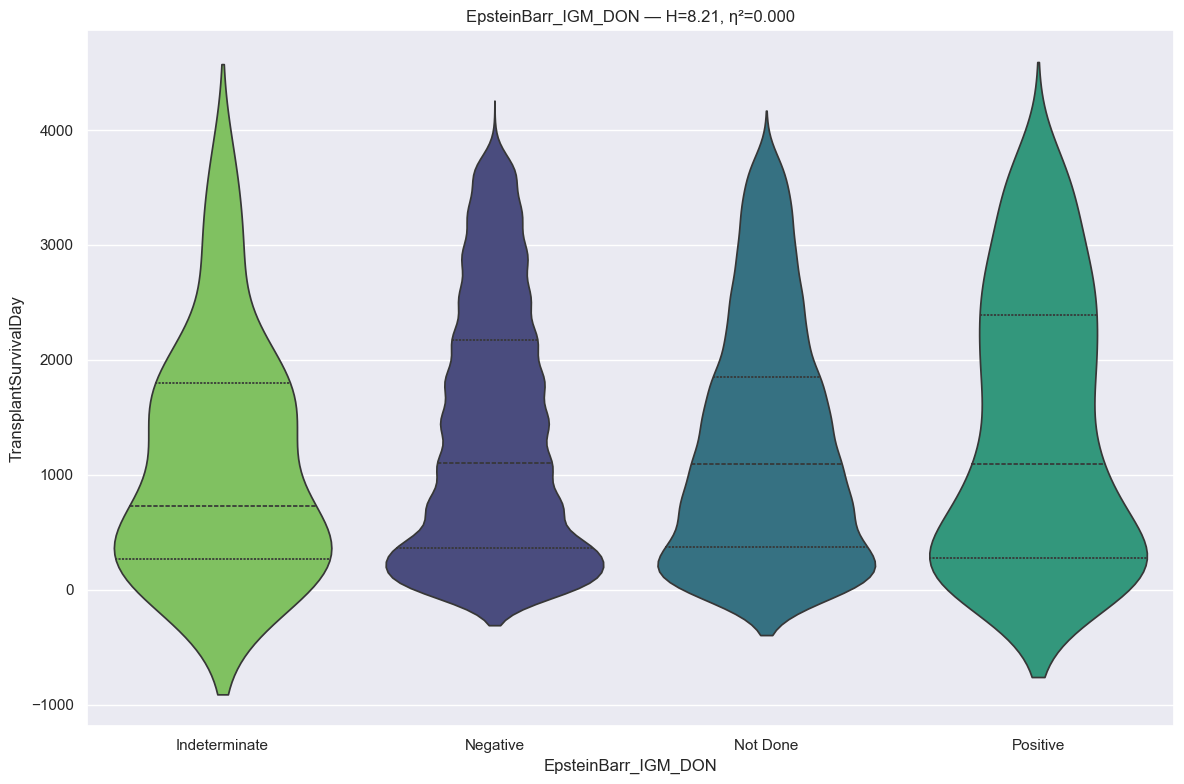

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     46 records
 * Negative                                          :  15998 records
 * Not Done                                          :   3674 records
 * Positive                                          :    266 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     19 records
 * Pending                                           :      1 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 8.2092 | P-value: 4.188052e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=1.2565e-02 | thr=0.0083 | r=-0.026 | Not Sig
Indeterminate v

In [206]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [207]:
# mapping
mapping = {'Missing': 'Other',
           'Pending': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

EpsteinBarr_IGM_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
           Negative         1338.416740                1099.0                 3947.0                    0.0         15998
           Not Done         1273.476320                1092.0                 3774.0                    0.0          3674
           Positive         1391.097744                1095.5                 3832.0                    0.0           266
      Indeterminate         1113.804348                 730.5                 3650.0                   13.0            46
              Other         1368.521739                1442.0                 3631.0                   14.0            23


In [208]:
# mapping
mapping = {'Negative': 'Other'}
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

EpsteinBarr_IGM_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
              Other         1338.459959                1099.0                 3947.0                    0.0         16021
           Not Done         1273.476320                1092.0                 3774.0                    0.0          3674
           Positive         1391.097744                1095.5                 3832.0                    0.0           266
      Indeterminate         1113.804348                 730.5                 3650.0                   13.0            46


In [209]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     46 records
 * Not Done                                          :   3674 records
 * Other                                             :  16021 records
 * Positive                                          :    266 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 8.2328 | P-value: 4.143850e-02 | Effect η²: 0.0003
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (4 categories)
  - Indeterminate
  - Not Done
  - Other
  - Positive



In [210]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### HIV Risk

In [211]:
# info
feature = u.get_feature_info(df, 'HIV_Risk', cat=False)
# dtype
{col: df[col].dtype for col in feature}

              count unique top   freq
HIV_Risk_DON  20007      4  No  14486

:::: NaN Count:
HIV_Risk_DON    0 



{'HIV_Risk_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

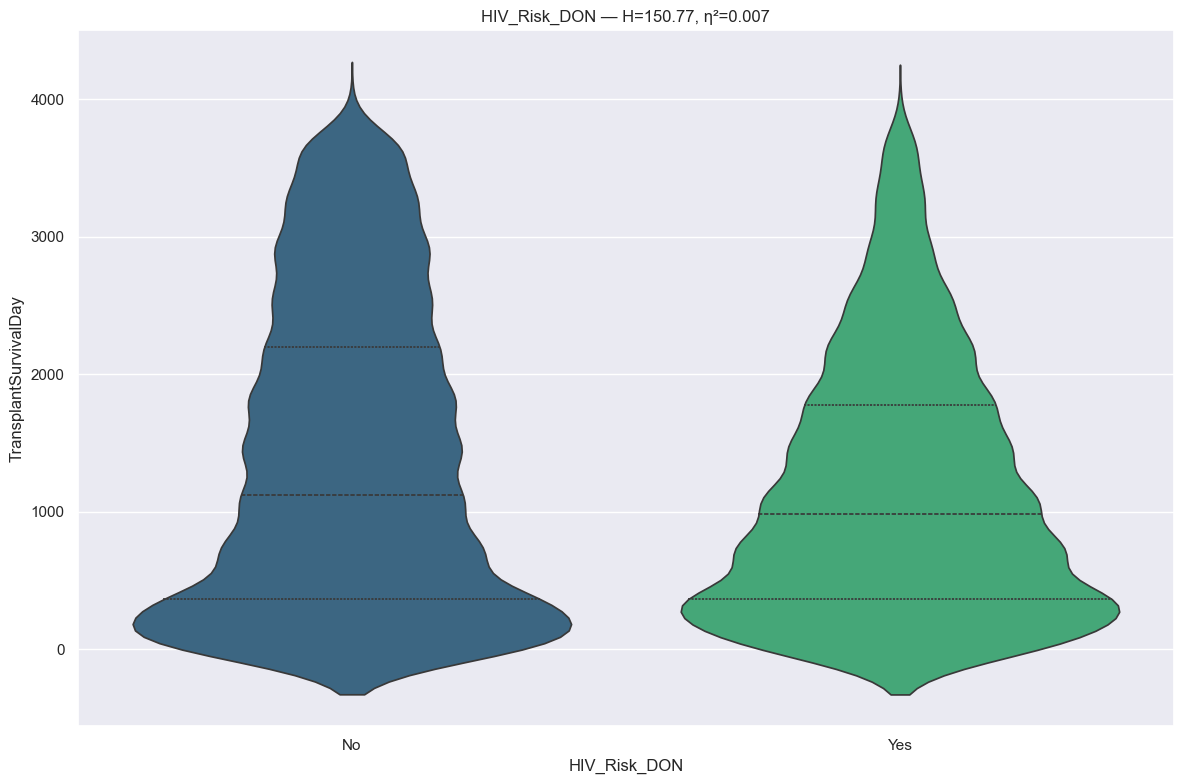

RANKING REPORT: HIV_Risk_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  14486 records
 * Yes                                               :   5511 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
 * Unknown                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 150.7673 | P-value: 1.178285e-34 | Effect η²: 0.0075
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.1783e-34 | thr=0.0500 | r=-0.112 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (2 categorie

In [212]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [213]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

HIV_Risk_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
          No         1398.319757                1124.0                 3947.0                    0.0         14486
         Yes         1138.341862                 982.0                 3926.0                    0.0          5511
       Other         1402.400000                1265.0                 3323.0                   94.0            10


In [214]:
# mapping
mapping = {'No': 'Other'}
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

HIV_Risk_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
       Other         1398.322572                1124.0                 3947.0                    0.0         14496
         Yes         1138.341862                 982.0                 3926.0                    0.0          5511


In [215]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: HIV_Risk_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Other                                             :  14496 records
 * Yes                                               :   5511 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 150.7858 | P-value: 1.167347e-34 | Effect η²: 0.0075
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Other

>>> Group_2 (1 categories)
  - Yes



#### Inotropic Agent

In [216]:
# info
feature = u.get_feature_info(df, 'InotropicAgent', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                    count unique      top   freq
InotropicAgent_DON  20007      7  Missing  12248

:::: NaN Count:
InotropicAgent_DON    0 



{'InotropicAgent_DON': CategoricalDtype(categories=['Dobutamine', 'Dopamine', 'Epinephrine', 'Levophed',
                   'Missing', 'Neosynephrine', 'Other, specify'],
 , ordered=False, categories_dtype=object)}

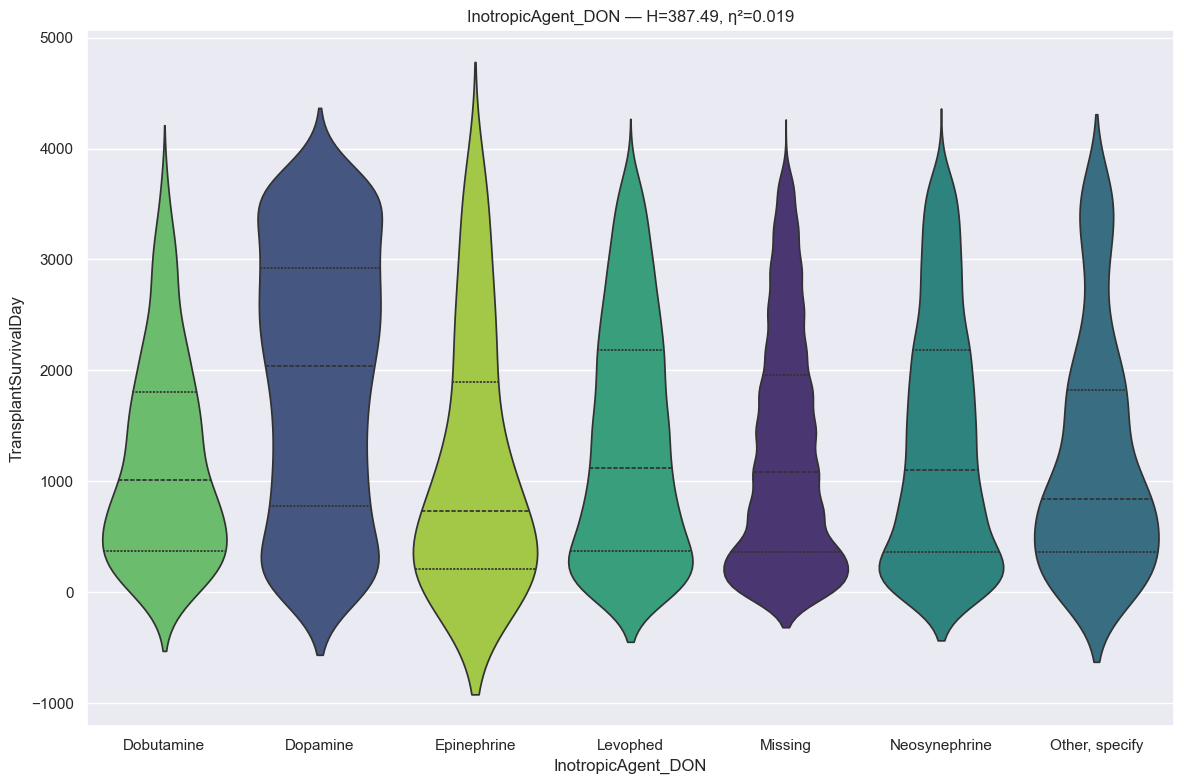

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    451 records
 * Dopamine                                          :   1340 records
 * Epinephrine                                       :     88 records
 * Levophed                                          :   2289 records
 * Missing                                           :  12248 records
 * Neosynephrine                                     :   3135 records
 * Other, specify                                    :    456 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 387.4903 | P-value: 1.366034e-80 | Effect η²: 0.0191
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Dopamine     vs Missing      | p=3.7662e-81 | thr=0.0024 | r=-0.317 | *Sig*
Dopamine     vs Neosyne

In [217]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [218]:
# mapping dictionary
collapse_map = results['mapping']
# update feature & mapping dataframe
df[feature[0]] = (df[feature[0]].map(collapse_map).astype("category"))
mapping_df.loc[mapping_df["feature"] == feature[0], "consolidate"] = True
# sanity check
df[feature[0]].isna().any()

np.False_

#### Kidney Allocation

In [219]:
# info
feature = u.get_feature_info(df, 'KidneyAllocation', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique top   freq
KidneyAllocation_DON  20007      3  No  19576

:::: NaN Count:
KidneyAllocation_DON    0 



{'KidneyAllocation_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

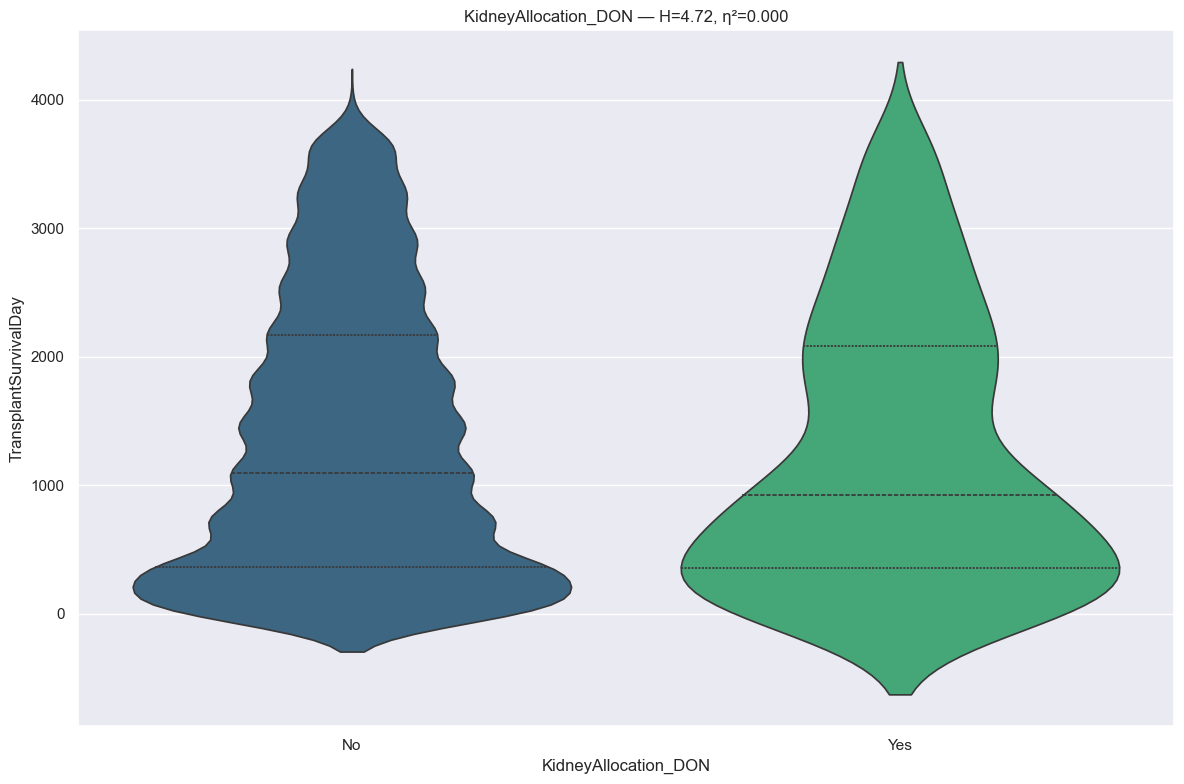

RANKING REPORT: KidneyAllocation_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19576 records
 * Yes                                               :    429 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 4.7187 | P-value: 2.983702e-02 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.9837e-02 | thr=0.0500 | r=-0.061 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - No

>>> Group_2 (1 categories)
  - Yes

>>> Other (1 categories)
  - Missing

KidneyAllocation_DON  mean_survival_days  median

In [220]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [221]:
# mapping: collapse Missing & No into Other: underpowered, small sample size
mapping = {'No': 'Other',
           'Missing': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

KidneyAllocation_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
               Other         1328.902748                1097.0                 3947.0                    0.0         19578
                 Yes         1226.638695                 921.0                 3667.0                    0.0           429


In [222]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: KidneyAllocation_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Other                                             :  19578 records
 * Yes                                               :    429 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 4.7138 | P-value: 2.992184e-02 | Effect η²: 0.0002
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 2 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group_1 (1 categories)
  - Other

>>> Group_2 (1 categories)
  - Yes



#### Inotropic Medication Procurement

In [223]:
# info
feature = u.get_feature_info(df, 'InotropicMedicationProcurement', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                                    count unique top   freq
InotropicMedicationProcurement_DON  20007      4  No  12182

:::: NaN Count:
InotropicMedicationProcurement_DON    0 



{'InotropicMedicationProcurement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

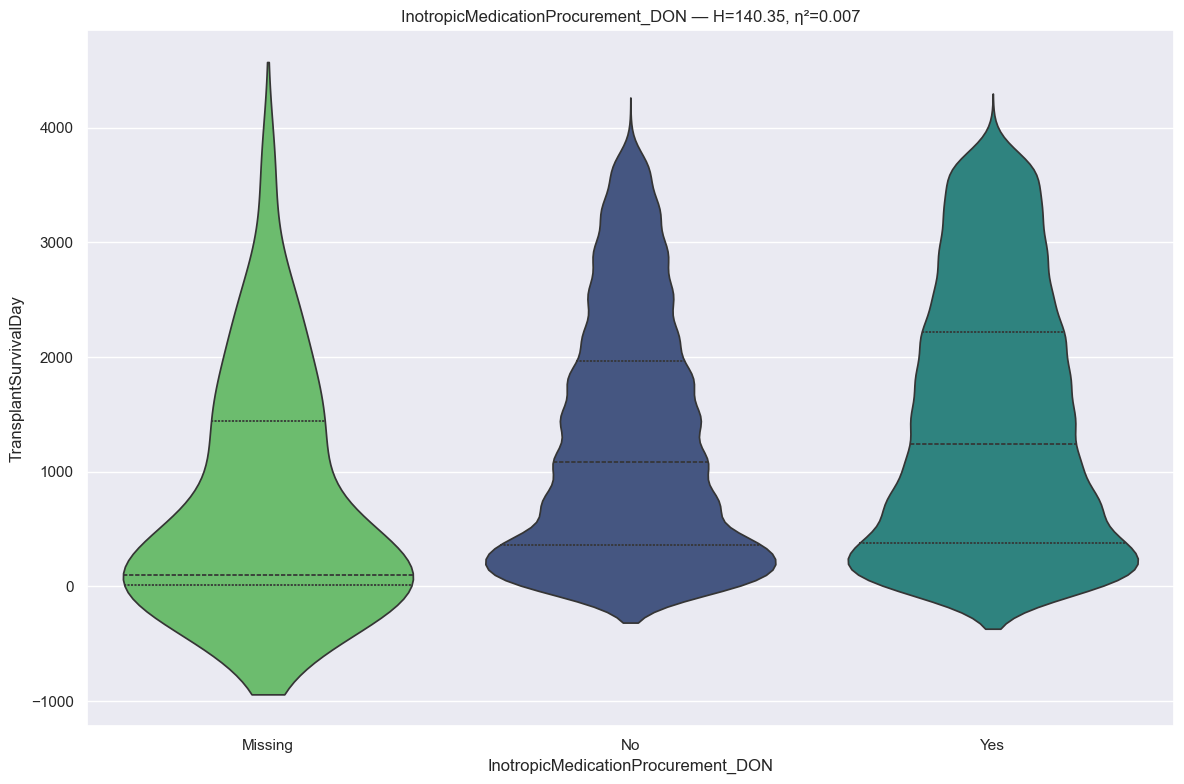

RANKING REPORT: InotropicMedicationProcurement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  12182 records
 * Yes                                               :   7759 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     28 records
--------------------------------------------------------------------------------
Kruskal H: 140.3545 | P-value: 3.329726e-31 | Effect η²: 0.0069
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.0039e-28 | thr=0.0167 | r= 0.092 | *Sig*
Missing      vs Yes          | p=1.5979e-06 | thr=0.0167 | r= 0.451 | *Sig*
Missing      vs No           | p=2.8298e-05 | thr=0.0167 | r= 0.393 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:

In [224]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### LT ONE WEEK

In [225]:
# info
feature = u.get_feature_info(df, 'LT_ONE_WEEK', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                 count unique top   freq
LT_ONE_WEEK_DON  20007      1  No  20007

:::: NaN Count:
LT_ONE_WEEK_DON    0 



{'LT_ONE_WEEK_DON': CategoricalDtype(categories=['No'], ordered=False, categories_dtype=object)}

In [226]:
# add to remove list
remove_cols.extend(feature)

#### Transfusion Number

In [227]:
# info
feature = u.get_feature_info(df, 'TransfusionNumber', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique   top  freq
TransfusionNumber_DON  20007      6  NONE  9794

:::: NaN Count:
TransfusionNumber_DON    0 



{'TransfusionNumber_DON': CategoricalDtype(categories=['1 - 5', '6 - 10', 'GREATER THAN 10', 'Missing', 'NONE',
                   'UNKNOWN'],
 , ordered=False, categories_dtype=object)}

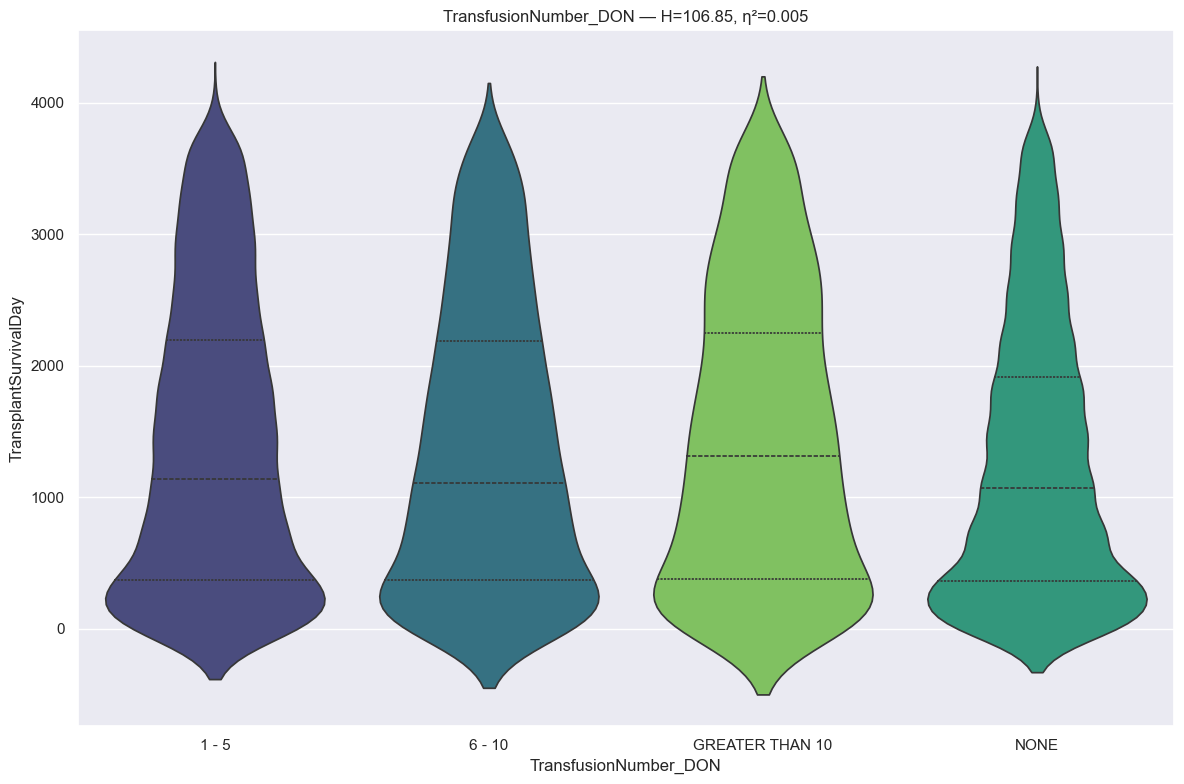

RANKING REPORT: TransfusionNumber_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1 - 5                                             :   6181 records
 * 6 - 10                                            :   2422 records
 * GREATER THAN 10                                   :   1590 records
 * NONE                                              :   9794 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     19 records
 * UNKNOWN                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 106.8539 | P-value: 5.215721e-23 | Effect η²: 0.0052
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
1 - 5        vs NONE         | p=1.2409e-18 | thr=0.0083 | r=-0.083 | *Sig*
GREATER THAN 10 vs NONE         | p=2.3741e-11 | thr=0.0083 | r=-0.104 | *Sig*
6 - 

In [228]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [229]:
# mapping
mapping = {'Missing': 'Other',
           'UNKNOWN': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

TransfusionNumber_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                 NONE         1245.018379                1071.0                 3947.0                    0.0          9794
                1 - 5         1407.576768                1137.0                 3928.0                    0.0          6181
               6 - 10         1374.564822                1112.0                 3702.0                    0.0          2422
      GREATER THAN 10         1442.979874                1310.5                 3702.0                    0.0          1590
                Other         1300.500000                1438.5                 2633.0                   94.0            20


#### Pulmonary Catheter

In [230]:
# info
feature = u.get_feature_info(df, 'PulmonaryCatheter', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique top   freq
PulmonaryCatheter_DON  20007      3  No  18733

:::: NaN Count:
PulmonaryCatheter_DON    0 



{'PulmonaryCatheter_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

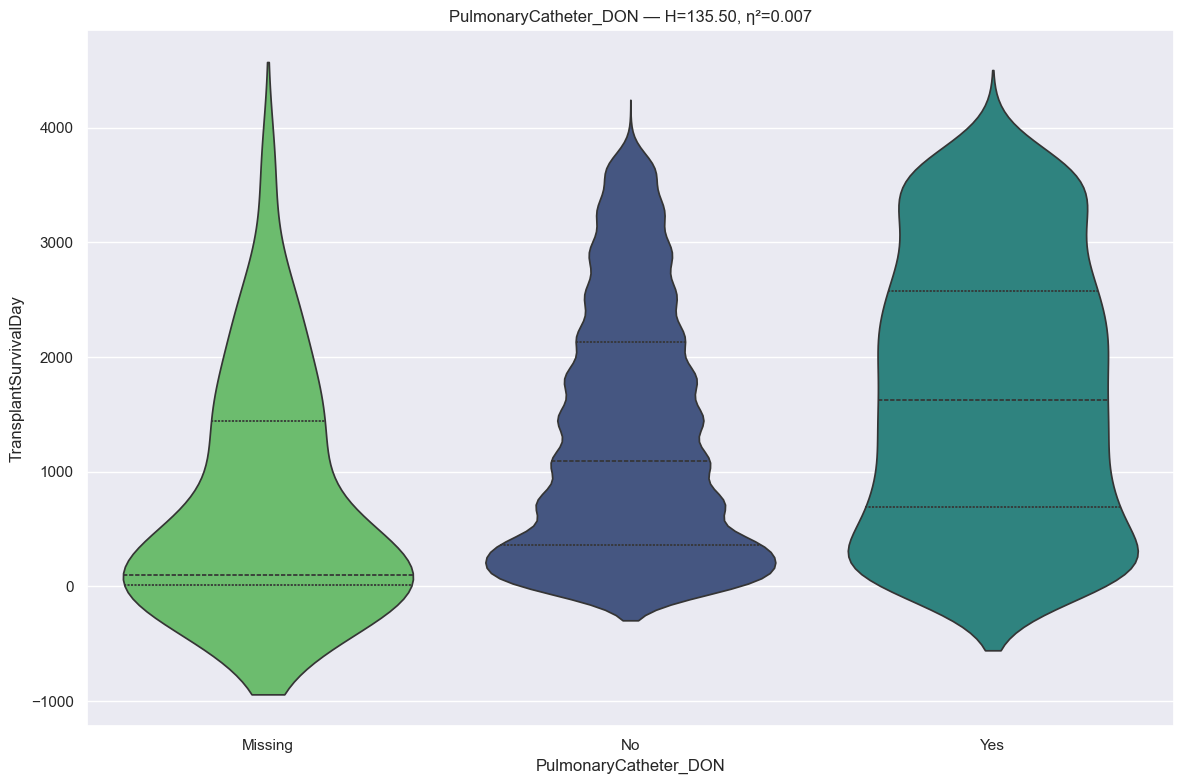

RANKING REPORT: PulmonaryCatheter_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  18733 records
 * Yes                                               :   1236 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 135.4994 | P-value: 3.772946e-30 | Effect η²: 0.0067
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.6297e-27 | thr=0.0167 | r= 0.183 | *Sig*
Missing      vs Yes          | p=4.6559e-08 | thr=0.0167 | r= 0.520 | *Sig*
Missing      vs No           | p=1.3278e-05 | thr=0.0167 | r= 0.408 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::::

>>> Group

In [231]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

#### Bronchoscopy Left

In [232]:
# info
feature = u.get_feature_info(df, 'BronchoscopyLeft', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                      count unique      top   freq
BronchoscopyLeft_DON  20007      9  Missing  10065

:::: NaN Count:
BronchoscopyLeft_DON    0 



{'BronchoscopyLeft_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'Missing', 'No Bronchoscopy',
                   'Normal', 'Unknown', 'Unknown if bronchoscopy performed'],
 , ordered=False, categories_dtype=object)}

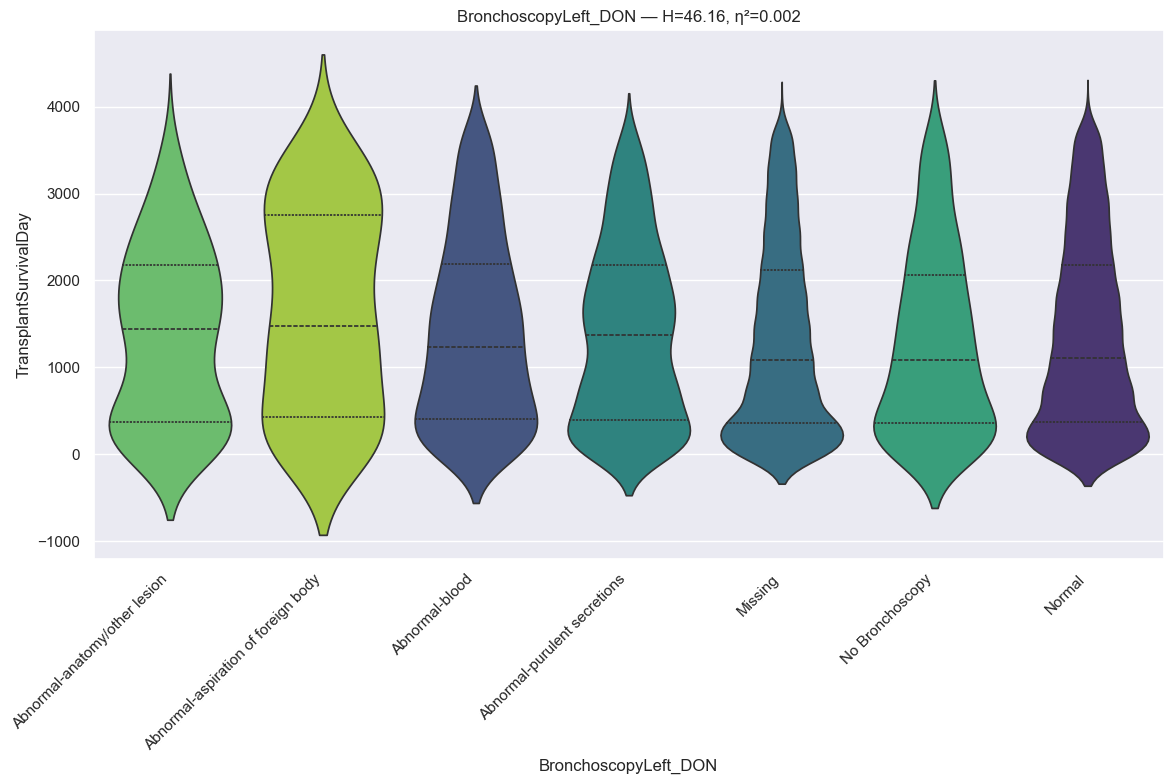

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    126 records
 * Abnormal-aspiration of foreign body               :     94 records
 * Abnormal-blood                                    :    732 records
 * Abnormal-purulent secretions                      :   1475 records
 * Missing                                           :  10065 records
 * No Bronchoscopy                                   :    431 records
 * Normal                                            :   7046 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     28 records
 * Unknown if bronchoscopy performed                 :     10 records
--------------------------------------------------------------------------------
Kruskal H: 46.1626 | P-value: 2.747887e-08 | Effect η²: 0.0020
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------

In [233]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [234]:
# mapping
mapping = {'Unknown': 'Other-1700s',
           'Unknown if bronchoscopy performed': 'Other-2200s'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

               BronchoscopyLeft_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                            Missing         1287.890015                1087.0                 3947.0                    0.0         10065
                             Normal         1357.373971                1106.0                 3945.0                    0.0          7046
       Abnormal-purulent secretions         1380.512542                1373.0                 3683.0                    0.0          1475
                     Abnormal-blood         1410.337432                1234.5                 3683.0                    0.0           732
                    No Bronchoscopy         1280.241299                1088.0                 3685.0                    0.0           431
      Abnormal-anatomy/other lesion         1355.753968                1445.5                 3627.0                    0.0           126
Abnormal-aspiration of foreign bod

In [235]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    126 records
 * Abnormal-aspiration of foreign body               :     94 records
 * Abnormal-blood                                    :    732 records
 * Abnormal-purulent secretions                      :   1475 records
 * Missing                                           :  10065 records
 * No Bronchoscopy                                   :    431 records
 * Normal                                            :   7046 records
BYPASSED CATEGORIES (n < min_n):
 * Other-1700s                                       :     28 records
 * Other-2200s                                       :     10 records
--------------------------------------------------------------------------------
Kruskal H: 46.1626 | P-value: 2.747887e-08 | Effect η²: 0.0020
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
---------------------------------

In [236]:
# mapping:
mapping = {'Abnormal-anatomy/other lesion': 'Group_1',
 'Abnormal-blood': 'Group_1',
 'Abnormal-purulent secretions': 'Group_1',
 'Missing': 'Group_1',
 'No Bronchoscopy': 'Group_1',
 'Normal': 'Group_1',
 'Abnormal-aspiration of foreign body': 'Group_2'}

# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

BronchoscopyLeft_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
             Group_1         1324.171170                1096.0                 3947.0                    0.0         19875
             Group_2         1659.031915                1472.0                 3665.0                    9.0            94
         Other-1700s         1700.678571                1828.0                 3617.0                    1.0            28
         Other-2200s         2201.600000                2191.5                 3645.0                    0.0            10


#### Bronchoscopy Right

In [237]:
# info
feature = u.get_feature_info(df, 'BronchoscopyRight', cat=False)
# dtype
{col: df[col].dtype for col in feature}

                       count unique      top   freq
BronchoscopyRight_DON  20007      9  Missing  10233

:::: NaN Count:
BronchoscopyRight_DON    0 



{'BronchoscopyRight_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'Missing', 'No Bronchoscopy',
                   'Normal', 'Unknown', 'Unknown if bronchoscopy performed'],
 , ordered=False, categories_dtype=object)}

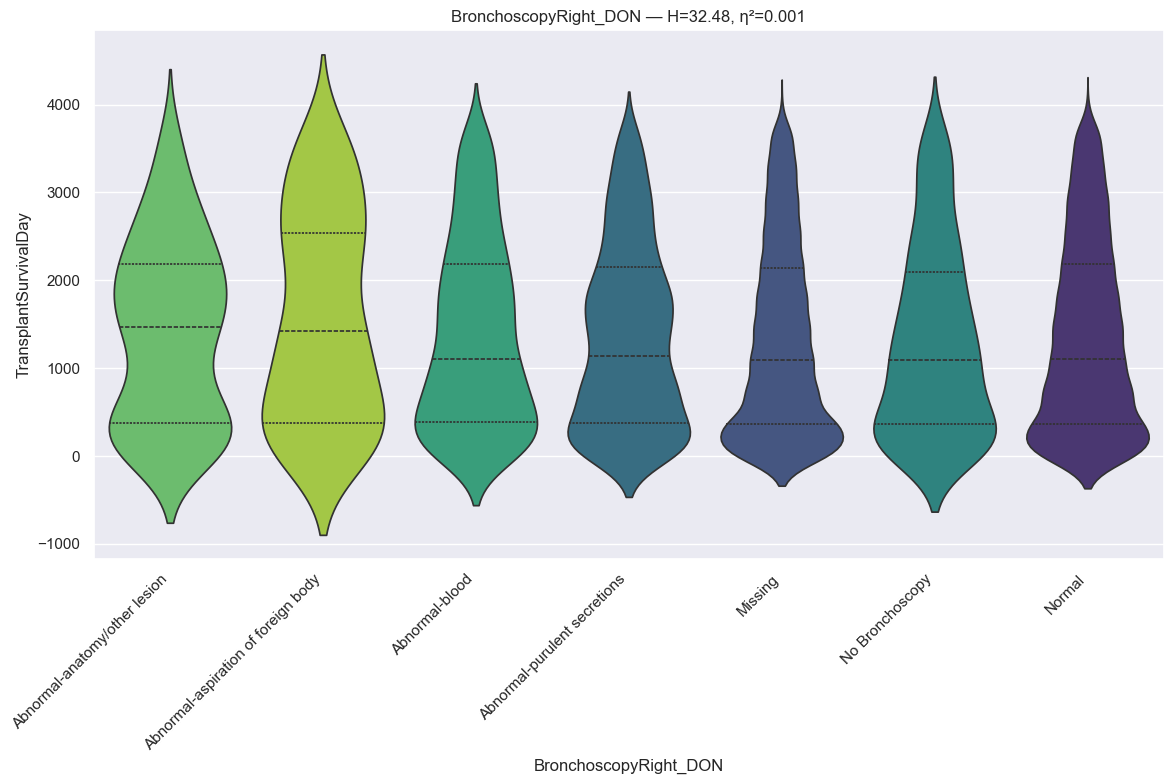

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    149 records
 * Abnormal-aspiration of foreign body               :    121 records
 * Abnormal-blood                                    :    797 records
 * Abnormal-purulent secretions                      :   1706 records
 * Missing                                           :  10233 records
 * No Bronchoscopy                                   :    434 records
 * Normal                                            :   6530 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     29 records
 * Unknown if bronchoscopy performed                 :      8 records
--------------------------------------------------------------------------------
Kruskal H: 32.4755 | P-value: 1.322611e-05 | Effect η²: 0.0013
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
-------------------------------

In [238]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 45
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [239]:
# mapping
mapping = {'Unknown': 'Other',
           'Unknown if bronchoscopy performed': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))

# sanity check
ranker.mean_survival_by_category(df, feature[0])

              BronchoscopyRight_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
                            Missing         1293.527314                1089.0                 3947.0                    0.0         10233
                             Normal         1353.679479                1104.5                 3945.0                    0.0          6530
       Abnormal-purulent secretions         1365.077374                1138.0                 3683.0                    0.0          1706
                     Abnormal-blood         1389.775408                1109.0                 3683.0                    0.0           797
                    No Bronchoscopy         1305.043779                1092.5                 3685.0                    0.0           434
      Abnormal-anatomy/other lesion         1420.181208                1465.0                 3644.0                    0.0           149
Abnormal-aspiration of foreign bod

In [240]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    149 records
 * Abnormal-aspiration of foreign body               :    121 records
 * Abnormal-blood                                    :    797 records
 * Abnormal-purulent secretions                      :   1706 records
 * Missing                                           :  10233 records
 * No Bronchoscopy                                   :    434 records
 * Normal                                            :   6530 records
 * Other                                             :     37 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 35.6096 | P-value: 8.588111e-06 | Effect η²: 0.0014
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output 

In [241]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Chest Xray

In [242]:
# info
feature = u.get_feature_info(df, 'ChestXray', cat=False)
# dtype
{col: df[col].dtype for col in feature}

               count unique            top   freq
ChestXray_DON  20007      7  Abnormal-both  10560

:::: NaN Count:
ChestXray_DON    0 



{'ChestXray_DON': CategoricalDtype(categories=['Abnormal-both', 'Abnormal-left', 'Abnormal-right',
                   'Missing', 'No chest x-ray', 'Normal', 'Results Unknown'],
 , ordered=False, categories_dtype=object)}

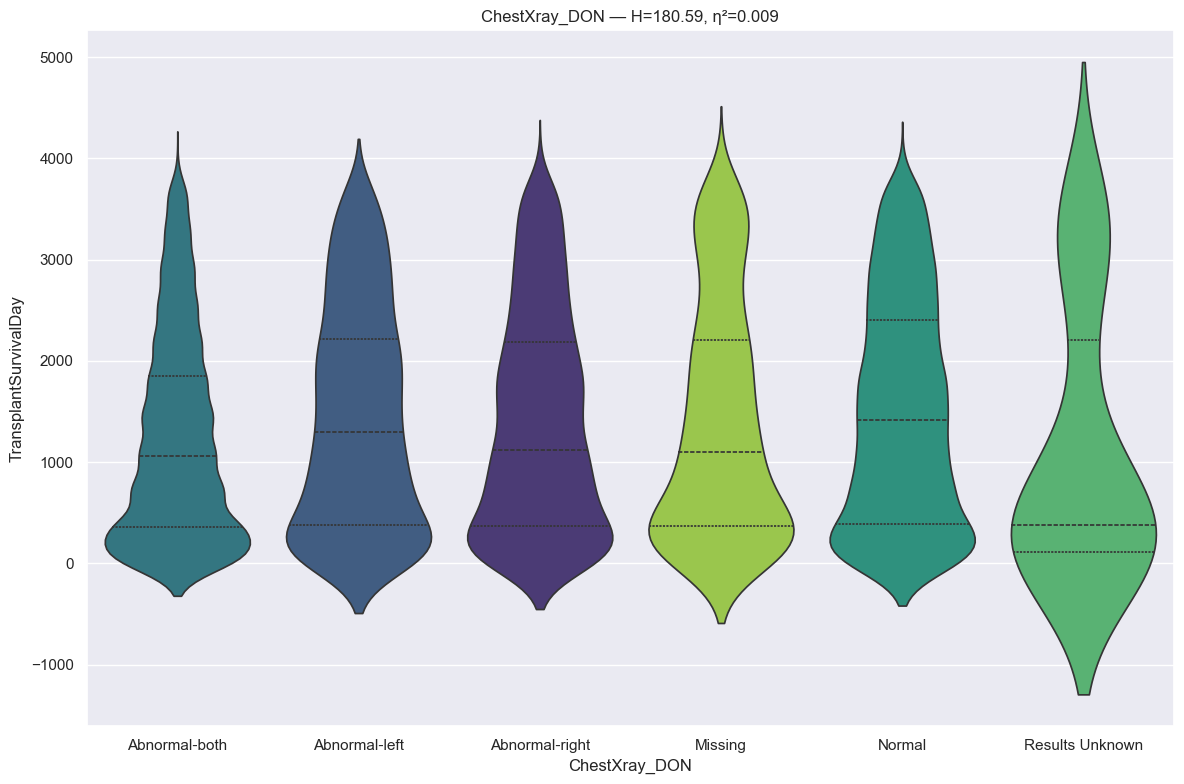

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :  10560 records
 * Abnormal-left                                     :   1738 records
 * Abnormal-right                                    :   2540 records
 * Missing                                           :    943 records
 * Normal                                            :   4181 records
 * Results Unknown                                   :     35 records
BYPASSED CATEGORIES (n < min_n):
 * No chest x-ray                                    :     10 records
--------------------------------------------------------------------------------
Kruskal H: 180.5922 | P-value: 3.999083e-37 | Effect η²: 0.0088
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Abnormal-both vs Normal       | p=8.8925e-33 | thr=0.0033 | r= 0.126 | *Sig*
Abnormal-both vs Abn

In [243]:
# values for NominalSurvivalRanker
class_values = {
    "r_thresh": 0.10,
    "method": "bonferroni",
    "suppress_pairwise": False,
    "rotation": 0
}
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=False)

In [244]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Results Unknown': 'Other',
           'No chest x-ray': 'Other'
          }
# map the change
df[feature[0]] = (df[feature[0]].map(mapping).fillna(df[feature[0]]))
# sanity check
ranker.mean_survival_by_category(df, feature[0])

 ChestXray_DON  mean_survival_days  median_survival_days  maximum_survival_days  minimum_survival_days  record_count
 Abnormal-both         1227.773485                1064.0                 3947.0                    0.0         10560
        Normal         1474.724229                1412.0                 3945.0                    0.0          4181
Abnormal-right         1397.285433                1117.0                 3928.0                    0.0          2540
 Abnormal-left         1431.290564                1300.0                 3702.0                    0.0          1738
       Missing         1395.778367                1097.0                 3926.0                    0.0           943
         Other         1321.533333                 737.0                 3658.0                    0.0            45


In [245]:
# values for NominalSurvivalRanker
class_values = {"method": "fdr", "suppress_pairwise": True}  # more relaxed
# NominalSurvivalRanker
mapping_df, results = ranker.cat_feature_ranker(data=df, mapping_data=mapping_df, 
                                                type_value=type_value, gender_value=gender_value,
                                                feature=feature, class_values=class_values, 
                                                re_run=True)

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :  10560 records
 * Abnormal-left                                     :   1738 records
 * Abnormal-right                                    :   2540 records
 * Missing                                           :    943 records
 * Normal                                            :   4181 records
 * Other                                             :     45 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 177.4913 | P-value: 1.837175e-36 | Effect η²: 0.0086
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::

:::::::::::::::::::::::::::::: GROUPED CATEGORIES ::::::::::::::::::::::::::::

In [246]:
# remove
mapping_df, remove_cols = ranker.update_remove_cols_and_mapping(mapping_data=mapping_df, remove_cols=remove_cols,
                                                                feature=feature, type_value=type_value, 
                                                                gender_value=gender_value)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Meds_DON

In [247]:
# info
feature = u.get_feature_info(df, 'Meds', cat=False)
# dtype
{col: df[col].dtype for col in feature}

          count unique top freq
Meds_DON  20007  16763      369

:::: NaN Count:
Meds_DON    0 



{'Meds_DON': dtype('O')}

In [248]:
# add to remove list
remove_cols.extend(feature)
# info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 20007 entries, 0 to 28750
Data columns (total 103 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   20007 non-null  category
 1    AntigenDA1_DON                        20007 non-null  object  
 2    AntigenDA2_DON                        20007 non-null  category
 3    AntigenDB1_DON                        20007 non-null  object  
 4    AntigenDB2_DON                        20007 non-null  object  
 5    AntigenDR1_DON                        20007 non-null  object  
 6    AntigenDR2_DON                        20007 non-null  object  
 7    Citizenship_DON                       20007 non-null  category
 8    PastCocaineUse_DON                    20007 non-null  category
 9    Age_DON                               20007 non-null  float64 
 10   Ethnicity_DON                         20007 non-null  categor

In [249]:
# remove unwanted columns
df = df.drop(columns=remove_cols).copy()

#### Write to Disk: Full Data

In [250]:
# save data: heart dataset
u.write_to_file(df, 'Male_DON_Heart_Data',path='../Data/', format='pkl')
u.write_to_file(mapping_df, 'Male_DON_Category_Mapping',path='../Data/', format='pkl')

20,007 records written to ../Data/Male_DON_Heart_Data.pkl
63 records written to ../Data/Male_DON_Category_Mapping.pkl
